<a href="https://colab.research.google.com/github/Aldrin-Jonathan/impacto-competencia-digital-docente/blob/main/Compet%C3%AAncias_Digitais_e_SAEB_de_Matem%C3%A1tica_2023.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# TCC


# Instalando bibliotecas

In [6]:
#!pip install --quiet pandas
#!pip install --quiet numpy
#!pip install --quiet U seaborn
#!pip install --quiet matplotlib
#!pip install --quiet plotly
#!pip install --quiet scipy
#!pip install --quiet statsmodels
#!pip install --quiet scikit-learn
#!pip install --quiet statstests

In [7]:
import pandas as pd # manipulação de dados em formato de dataframe
import numpy as np # operações matemáticas
import seaborn as sns # visualização gráfica
import statsmodels.api as sm # estimação de modelos
from scipy.stats import gaussian_kde # inserção de KDEs em gráficos
from matplotlib.gridspec import GridSpec # plotagem de gráficos separados
from tqdm import tqdm # adiciona um indicador de progresso do código
import statsmodels.formula.api as smf
from scipy.stats import pearsonr
import matplotlib.pyplot as plt
from scipy.stats import pointbiserialr, chi2_contingency
from scipy.stats import ttest_ind, f_oneway

# Importando Guia Edutech

In [8]:
#%% Importando base do Guia Edutec

autoavaliacao = pd.read_csv("/content/drive/MyDrive/MBA Data Analytics/TCC/Bases/Guia Edutech/guia_edutech_autoavaliacao_julho.csv", delimiter=',')

autoavaliacao.dtypes
autoavaliacao.head()

/tmp/ipykernel_666/833188009.py:3: DtypeWarning: Columns (3,4,10,11,12,13,14,15,16) have mixed types. Specify dtype option on import or set low_memory=False.
  autoavaliacao = pd.read_csv("/content/drive/MyDrive/MBA Data Analytics/TCC/Bases/Guia Edutech/guia_edutech_autoavaliacao_julho.csv", delimiter=',')


,ID,INEP,Ano,Nascimento,Gênero,IBGE_Cidade,Cidade,IBGE_Estado,Estado,Tipo de Rede,...,DP.CP.2.a,DP.CP.2.b,DP.CP.2.c,DP.CP.2.d,DP.CP.2.e,DP.CM.1.a,DP.CM.1.b,DP.CM.1.c,DP.CM.1.d,DP.CM.1.e
0,Z2lsbWFyYWZ3QHNlZWQucHIuZ292LmJyOTE0MWZm,41130782,2018,-,-,4106902,Curitiba,41,Paraná,Estadual,...,0,0,0,1,0,0,0,1,0,0
1,bWVpcmllbGVfdG9tYWxAZXNjb2xhLnByLmdvdi5icjkxND...,41118189,2018,1984,1,4128203,União da Vitória,41,Paraná,Estadual,...,0,1,0,0,0,0,0,0,1,0
2,bG91dmFuZS5jYXJ2YWxob0Blc2NvbGEucHIuZ292LmJyOT...,41068807,2018,-,-,4127700,Toledo,41,Paraná,Estadual,...,0,1,0,0,0,0,0,0,0,1
3,cm9zZV9zYW50b3NAZXNjb2xhLnByLmdvdi5icjkxNDFmZg==,41056302,2018,-,-,4127106,Telêmaco Borba,41,Paraná,Estadual,...,0,1,0,0,0,0,0,0,0,1
4,c2dtYXR0b3NAZXNjb2xhLnByLmdvdi5icjkxNDFmZg==,41131517,2018,-,-,4106902,Curitiba,41,Paraná,Estadual,...,0,0,0,1,0,0,0,1,0,0


In [9]:
autoavaliacao['Ano'].unique()

array([2018, 2019, 2020, 2021, 2022, 2023, 2024, 2025])

In [10]:
#%% Realizando DataWraling

autoavaliacao.columns.get_loc("P.PP")
autoavaliacao = autoavaliacao.iloc[:, :21] #Removendo todas as colunas que contém itens de resposta dos educadores
autoavaliacao['Ano'].unique()
autoavaliacao = autoavaliacao.rename(columns={'ID':"id_professor"}) #Alterando nome de coluna
autoavaliacao = autoavaliacao.rename(columns={'Ano':"ano"})
autoavaliacao.dtypes
autoavaliacao = autoavaliacao.replace('-', None) # Substitui '-' por None (NaN) em todo o DataFrame
autoavaliacao.dtypes

,0
id_professor,object
INEP,int64
ano,int64
Nascimento,object
Gênero,object
IBGE_Cidade,int64
Cidade,object
IBGE_Estado,int64
Estado,object
Tipo de Rede,object


Corrigindo as variáveis object

In [11]:
#Corrigindo o tipo de variáveis
variaveis_binarias = ["EFI", "EFII", "EM"] # Primeiro, identifique as colunas que precisam de correção

for var in variaveis_binarias:
    # Passo 1: Converter a coluna para string, se não for
    # Isso garante que a limpeza de espaços em branco funcione em todos os valores
    autoavaliacao[var] = autoavaliacao[var].astype(str)

    # Passo 2: Remover espaços em branco no início e no fim
    autoavaliacao[var] = autoavaliacao[var].str.strip()

    # Passo 3: Forçar a conversão para um tipo numérico (integer)
    # O .astype(int) irá converter '0' -> 0 e '1' -> 1
    # Caso haja valores que não são '0' ou '1' (após o strip), a conversão dará erro.
    # É um bom sinal de que há outros problemas nos dados.
    autoavaliacao[var] = pd.to_numeric(autoavaliacao[var], errors='coerce').fillna(0).astype(int)

    # Nota: A linha acima (pd.to_numeric...) é mais robusta.
    # Se você tem certeza de que só há 0s e 1s, pode usar:
    # autoavaliacao[var] = autoavaliacao[var].astype(int)

Alterando o nome da coluna "INEP" do banco de dados autoavaliacao

In [12]:
autoavaliacao = autoavaliacao.rename(columns={'INEP': 'id_escola'})

In [13]:
autoavaliacao.head(100)

,id_professor,id_escola,ano,Nascimento,Gênero,IBGE_Cidade,Cidade,IBGE_Estado,Estado,Tipo de Rede,...,EFI,EFII,EM,EJA,ET,ES,FC,PED,CID,DES
0,Z2lsbWFyYWZ3QHNlZWQucHIuZ292LmJyOTE0MWZm,41130782,2018,None,None,4106902,Curitiba,41,Paraná,Estadual,...,0,0,0,0,0,0,None,3,4,3
1,bWVpcmllbGVfdG9tYWxAZXNjb2xhLnByLmdvdi5icjkxND...,41118189,2018,1984,1,4128203,União da Vitória,41,Paraná,Estadual,...,0,1,1,0,0,0,None,3,2,3
2,bG91dmFuZS5jYXJ2YWxob0Blc2NvbGEucHIuZ292LmJyOT...,41068807,2018,None,None,4127700,Toledo,41,Paraná,Estadual,...,0,0,0,0,0,0,None,3,2,3
3,cm9zZV9zYW50b3NAZXNjb2xhLnByLmdvdi5icjkxNDFmZg==,41056302,2018,None,None,4127106,Telêmaco Borba,41,Paraná,Estadual,...,0,0,0,0,0,0,None,4,3,3
4,c2dtYXR0b3NAZXNjb2xhLnByLmdvdi5icjkxNDFmZg==,41131517,2018,None,None,4106902,Curitiba,41,Paraná,Estadual,...,0,0,0,0,0,0,None,3,3,3
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
95,c2ltb25lc25waW50b0Bob3RtYWlsLmNvbTkxNDFmZg==,15588378,2018,None,None,1502400,Castanhal,15,Pará,Estadual,...,0,0,0,None,None,None,None,2,3,3
96,bHVpc21hbGNoZXJAZ21haWwuY29tOTE0MWZm,15034747,2018,None,None,1500800,Ananindeua,15,Pará,Estadual,...,0,0,0,0,0,0,None,1,2,2
97,am90YWRyZmVycmVpcmFAZ21haWwuY29tOTE0MWZm,15045587,2018,None,None,1502400,Castanhal,15,Pará,Estadual,...,0,0,0,0,0,0,None,3,3,3
98,ZmVycmVpcmEubWFyaWFpemFiZWxAeWFob28uY29tLmJyOT...,15066932,2018,None,None,1500107,Abaetetuba,15,Pará,Municipal,...,0,0,0,0,0,0,None,3,3,3


In [14]:
autoavaliacao.describe()
autoavaliacao.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 198385 entries, 0 to 198384
Data columns (total 21 columns):
 #   Column        Non-Null Count   Dtype 
---  ------        --------------   ----- 
 0   id_professor  198385 non-null  object
 1   id_escola     198385 non-null  int64 
 2   ano           198385 non-null  int64 
 3   Nascimento    181966 non-null  object
 4   Gênero        102913 non-null  object
 5   IBGE_Cidade   198385 non-null  int64 
 6   Cidade        198385 non-null  object
 7   IBGE_Estado   198385 non-null  int64 
 8   Estado        198385 non-null  object
 9   Tipo de Rede  198385 non-null  object
 10  EI            197042 non-null  object
 11  EFI           198385 non-null  int64 
 12  EFII          198385 non-null  int64 
 13  EM            198385 non-null  int64 
 14  EJA           197042 non-null  object
 15  ET            197042 non-null  object
 16  ES            197042 non-null  object
 17  FC            102104 non-null  object
 18  PED           198385 non

Excluindo variáveis desnecessárias

In [15]:
# Lista de colunas a serem removidas
colunas_para_remover_autoavaliacao = ['Nascimento', 'Gênero', 'IBGE_Cidade', 'Cidade', 'Estado', "EI", 'EJA','ET', 'ES', 'FC',]

# Remover as colunas especificadas do DataFrame autoavaliacao
autoavaliacao = autoavaliacao.drop(columns=colunas_para_remover_autoavaliacao)

# Exibir as primeiras linhas e informações do DataFrame modificado
display(autoavaliacao.head())
print("\nInformações sobre o DataFrame autoavaliacao após remover as colunas:")
autoavaliacao.info()

,id_professor,id_escola,ano,IBGE_Estado,Tipo de Rede,EFI,EFII,EM,PED,CID,DES
0,Z2lsbWFyYWZ3QHNlZWQucHIuZ292LmJyOTE0MWZm,41130782,2018,41,Estadual,0,0,0,3,4,3
1,bWVpcmllbGVfdG9tYWxAZXNjb2xhLnByLmdvdi5icjkxND...,41118189,2018,41,Estadual,0,1,1,3,2,3
2,bG91dmFuZS5jYXJ2YWxob0Blc2NvbGEucHIuZ292LmJyOT...,41068807,2018,41,Estadual,0,0,0,3,2,3
3,cm9zZV9zYW50b3NAZXNjb2xhLnByLmdvdi5icjkxNDFmZg==,41056302,2018,41,Estadual,0,0,0,4,3,3
4,c2dtYXR0b3NAZXNjb2xhLnByLmdvdi5icjkxNDFmZg==,41131517,2018,41,Estadual,0,0,0,3,3,3



Informações sobre o DataFrame autoavaliacao após remover as colunas:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 198385 entries, 0 to 198384
Data columns (total 11 columns):
 #   Column        Non-Null Count   Dtype 
---  ------        --------------   ----- 
 0   id_professor  198385 non-null  object
 1   id_escola     198385 non-null  int64 
 2   ano           198385 non-null  int64 
 3   IBGE_Estado   198385 non-null  int64 
 4   Tipo de Rede  198385 non-null  object
 5   EFI           198385 non-null  int64 
 6   EFII          198385 non-null  int64 
 7   EM            198385 non-null  int64 
 8   PED           198385 non-null  int64 
 9   CID           198385 non-null  int64 
 10  DES           198385 non-null  int64 
dtypes: int64(9), object(2)
memory usage: 16.6+ MB


# Criando notas de PED por etapa de ensino

In [16]:
autoavaliacao['PED_EFI'] = autoavaliacao.apply(lambda row: row['PED'] if row['EFI'] == 1 else None, axis=1)
autoavaliacao['PED_EFII'] = autoavaliacao.apply(lambda row: row['PED'] if row['EFII'] == 1 else None, axis=1)
autoavaliacao['PED_EM'] = autoavaliacao.apply(lambda row: row['PED'] if row['EM'] == 1 else None, axis=1)

In [17]:
#Contando quantas observações são nulas "PED_EFI", "PED_EFII" e "PED_EM" simultaneamente

num_nulas_ped = autoavaliacao[(autoavaliacao['PED_EFI'] == None) & (autoavaliacao['PED_EFII'] == None) & (autoavaliacao['PED_EM'] == None)].shape[0]
print(f"O número de observações com 'None' simultaneamente em 'PED_EFI', 'PED_EFII' e 'PED_EM' é: {num_nulas_ped}")

O número de observações com 'None' simultaneamente em 'PED_EFI', 'PED_EFII' e 'PED_EM' é: 0


In [18]:
autoavaliacao.shape

(198385, 14)

In [19]:
print((117234/198385)*100)

59.09418554830255


In [20]:
autoavaliacao.head(50)

,id_professor,id_escola,ano,IBGE_Estado,Tipo de Rede,EFI,EFII,EM,PED,CID,DES,PED_EFI,PED_EFII,PED_EM
0,Z2lsbWFyYWZ3QHNlZWQucHIuZ292LmJyOTE0MWZm,41130782,2018,41,Estadual,0,0,0,3,4,3,NaN,NaN,NaN
1,bWVpcmllbGVfdG9tYWxAZXNjb2xhLnByLmdvdi5icjkxND...,41118189,2018,41,Estadual,0,1,1,3,2,3,NaN,3.0,3.0
2,bG91dmFuZS5jYXJ2YWxob0Blc2NvbGEucHIuZ292LmJyOT...,41068807,2018,41,Estadual,0,0,0,3,2,3,NaN,NaN,NaN
3,cm9zZV9zYW50b3NAZXNjb2xhLnByLmdvdi5icjkxNDFmZg==,41056302,2018,41,Estadual,0,0,0,4,3,3,NaN,NaN,NaN
4,c2dtYXR0b3NAZXNjb2xhLnByLmdvdi5icjkxNDFmZg==,41131517,2018,41,Estadual,0,0,0,3,3,3,NaN,NaN,NaN
5,YWRyaWFub19tZW5kZXNAZ21haWwuY29tOTE0MWZm,41140370,2018,41,Estadual,0,0,0,3,3,4,NaN,NaN,NaN
6,ZGVuaXNlX2J1c2NoQGVzY29sYS5wci5nb3YuYnI5MTQxZmY=,41118189,2018,41,Estadual,0,0,0,3,3,3,NaN,NaN,NaN
7,bml2YWxkb2xvcGVzQGVzY29sYS5wci5nb3YuYnI5MTQxZmY=,41023080,2018,41,Estadual,0,1,1,2,3,3,NaN,2.0,2.0
8,Z2Vpc2xhX21lbGxvQGVzY29sYS5wci5nb3YuYnI5MTQxZmY=,41030397,2018,41,Estadual,0,1,1,3,4,4,NaN,3.0,3.0
9,bHVjaWFuZV9qb25hc0Blc2NvbGEucHIuZ292LmJyOTE0MWZm,41026152,2018,41,Estadual,0,0,0,2,3,3,NaN,NaN,NaN


In [21]:
# Pesquisando em IDEB "id_escola" correspondente a "41130782" e ordene por ordem crescente de "ano" sem criar um novo data frame

# Filtra as linhas onde 'id_escola' é igual a 41130782
# Em seguida, ordena o DataFrame resultante pelo 'ano' em ordem crescente
autoavaliacao[autoavaliacao['id_escola'] == 41130782].sort_values(by='ano', ascending=True)


,id_professor,id_escola,ano,IBGE_Estado,Tipo de Rede,EFI,EFII,EM,PED,CID,DES,PED_EFI,PED_EFII,PED_EM
0,Z2lsbWFyYWZ3QHNlZWQucHIuZ292LmJyOTE0MWZm,41130782,2018,41,Estadual,0,0,0,3,4,3,NaN,NaN,NaN
165099,bWFyaWEuYmFsZHVpbm9AZXNjb2xhLnByLmdvdi5icjkxND...,41130782,2024,41,Estadual,0,1,0,1,1,1,NaN,1.0,NaN
165561,ZWxpYW5lLmxpbmVyb0BlZHVjYWNhby5wci5nb3YuYnI5MT...,41130782,2024,41,Estadual,0,1,1,1,2,3,NaN,1.0,1.0
173560,ZXN0ZWxhLnNhYnJpbmEuZnJlaXRhc0Blc2NvbGEucHIuZ2...,41130782,2024,41,Estadual,0,0,1,3,2,2,NaN,NaN,3.0
179763,bWFybGkudGVycmVzQGVzY29sYS5wci5nb3YuYnI5MTQxZmY=,41130782,2024,41,Estadual,0,1,0,1,1,2,NaN,1.0,NaN


In [22]:
# Calculando quantos educadores únicos existem no Guia Edutech

autoavaliacao['id_professor'].nunique()

178833

In [23]:
#Tabela de frequência para as variáveis "EFI', "EFII", "EM", "Tipo de Rede". Utilize a função "value.counts" do pandas

variaveis = ["EFI", "EFII", "EM", "Tipo de Rede"]

for var in variaveis:
  print(f"\nTabela de frequência para a variável: {var}")
  print(autoavaliacao[var].value_counts())


Tabela de frequência para a variável: EFI
EFI
0    147791
1     50594
Name: count, dtype: int64

Tabela de frequência para a variável: EFII
EFII
0    121031
1     77354
Name: count, dtype: int64

Tabela de frequência para a variável: EM
EM
0    116093
1     82292
Name: count, dtype: int64

Tabela de frequência para a variável: Tipo de Rede
Tipo de Rede
Estadual      127026
Municipal      66974
Particular      3818
Federal          567
Name: count, dtype: int64


In [24]:
autoavaliacao.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 198385 entries, 0 to 198384
Data columns (total 14 columns):
 #   Column        Non-Null Count   Dtype  
---  ------        --------------   -----  
 0   id_professor  198385 non-null  object 
 1   id_escola     198385 non-null  int64  
 2   ano           198385 non-null  int64  
 3   IBGE_Estado   198385 non-null  int64  
 4   Tipo de Rede  198385 non-null  object 
 5   EFI           198385 non-null  int64  
 6   EFII          198385 non-null  int64  
 7   EM            198385 non-null  int64  
 8   PED           198385 non-null  int64  
 9   CID           198385 non-null  int64  
 10  DES           198385 non-null  int64  
 11  PED_EFI       50594 non-null   float64
 12  PED_EFII      77354 non-null   float64
 13  PED_EM        82292 non-null   float64
dtypes: float64(3), int64(9), object(2)
memory usage: 21.2+ MB


In [25]:
# Verificar a frequência do id_escola = 0 no DataFrame original
print("Frequência de id_escola = 0 no DataFrame autoavaliacao:")
print(autoavaliacao['id_escola'].value_counts().get(0, 0))

# Exibir as primeiras linhas do autoavaliacao onde id_escola é 0
print("\nPrimeiras linhas do autoavaliacao onde id_escola é 0:")
display(autoavaliacao[autoavaliacao['id_escola'] == 0].head())

Frequência de id_escola = 0 no DataFrame autoavaliacao:
266

Primeiras linhas do autoavaliacao onde id_escola é 0:


,id_professor,id_escola,ano,IBGE_Estado,Tipo de Rede,EFI,EFII,EM,PED,CID,DES,PED_EFI,PED_EFII,PED_EM
26173,bnRlZ3luc3Vkby5yYWZhZWxAZ21haWwuY29tOTE0MWZm,0,2020,52,Municipal,1,1,0,3,4,5,3.0,3.0,NaN
26572,anVzc2FyYXJvY2hhMTk3MUBnbWFpbC5jb205MTQxZmY=,0,2020,52,Municipal,0,0,0,2,1,2,NaN,NaN,NaN
26591,ZG91Z2FpcmVzLjE3QGdtYWlsLmNvbTkxNDFmZg==,0,2020,52,Municipal,1,1,0,2,1,2,2.0,2.0,NaN
26613,am9zaWFuZWFkb3Jub0BnbWFpbC5jb205MTQxZmY=,0,2020,52,Municipal,0,0,0,1,2,2,NaN,NaN,NaN
26630,YW5kcmVpYXBic3JAZ21haWwuY29tOTE0MWZm,0,2020,52,Municipal,1,0,0,1,1,2,1.0,NaN,NaN


# Procedimento de média ponderada

Procedimento novo considerando os anos de 2021, 2022 e 2023 como influentes para o IDEB 2023

In [26]:
# 1. Preparação e Limpeza: Filtra apenas os anos de 2021, 2022 e 2023
autoavaliacao_periodo = autoavaliacao[autoavaliacao['ano'].isin([2021, 2022, 2023])].copy()

# 2. Deduplicação por Educador (Critério de Excelência)
# Mantém o valor máximo para as variáveis de proficiência por professor
educador_consolidado = autoavaliacao_periodo.groupby('id_professor').agg({
    'PED': 'max',
    'PED_EFI': 'max',
    'PED_EFII': 'max',
    'PED_EM': 'max',
    'id_escola': 'first'  # Associa à primeira escola encontrada no período
}).reset_index()

# 3. Agregação por Escola
# Calcula a média aritmética simples das notas máximas dos educadores por escola
base_escolas_consolidada = educador_consolidado.groupby('id_escola').agg({
    'PED': 'mean',
    'PED_EFI': 'mean',
    'PED_EFII': 'mean',
    'PED_EM': 'mean',
    'id_professor': 'nunique' # Conta educadores únicos para o filtro
}).reset_index()

# Renomeia colunas para clareza
base_escolas_consolidada = base_escolas_consolidada.rename(columns={
    'PED': 'comp_dig_geral',
    'PED_EFI': 'comp_dig_EFI',
    'PED_EFII': 'comp_dig_EFII',
    'PED_EM': 'comp_dig_EM',
    'id_professor': 'num_educadores_unicos'
})

# Atribuir base_escolas_consolidada a base_escolas_final sem filtro
base_escolas_final = base_escolas_consolidada.copy()

print(f"Processamento concluído.")
print(f"Total de escolas sem filtragem: {base_escolas_final.shape[0]}")
display(base_escolas_final.head())

Processamento concluído.
Total de escolas sem filtragem: 10781


,id_escola,comp_dig_geral,comp_dig_EFI,comp_dig_EFII,comp_dig_EM,num_educadores_unicos
0,0,2.756757,2.842105,2.769231,NaN,37
1,1,4.333333,4.333333,4.500000,4.000000,3
2,2,2.647059,2.333333,2.666667,2.818182,17
3,3,3.333333,3.000000,2.500000,3.000000,6
4,7,3.200000,3.500000,NaN,NaN,5


In [27]:
autoavaliacao[(autoavaliacao['id_escola'] == 3) & (autoavaliacao['ano'].isin([2021, 2022, 2023]))].head(10)

,id_professor,id_escola,ano,IBGE_Estado,Tipo de Rede,EFI,EFII,EM,PED,CID,DES,PED_EFI,PED_EFII,PED_EM
101263,YW50b25pYUBwcm9mLmVkdWMucmVjLmJyOTE0MWZm,3,2022,26,Municipal,1,0,0,4,3,2,4.0,NaN,NaN
101283,a2F0aWEuc291emFAcHJvZi5lZHVjLnJlYy5icjkxNDFmZg==,3,2022,26,Municipal,0,0,0,3,3,3,NaN,NaN,NaN
101311,c2FuZHJhYnJhc2lsaWFub0B5YWhvby5jb20uYnI5MTQxZmY=,3,2022,26,Municipal,0,0,0,4,4,3,NaN,NaN,NaN
101585,bmVpZGUuZmFsZUBnbWFpbC5jb205MTQxZmY=,3,2022,26,Municipal,0,0,0,4,4,3,NaN,NaN,NaN
101668,Z3Vpb21hci5jYXJ0YXhvQHByb2YuZWR1Yy5yZWMuYnI5MT...,3,2022,26,Municipal,1,1,1,3,4,4,3.0,3.0,3.0
103447,c2FuZHJhLjMzNDMxM0Bwcm9mLmVkdWMucmVjLmJyOTE0MWZm,3,2022,26,Municipal,1,1,0,2,3,2,2.0,2.0,NaN
144912,a2F0aWEuc291emFAcHJvZi5lZHVjLnJlYy5icjkxNDFmZg==,3,2023,26,Municipal,0,0,0,3,2,3,NaN,NaN,NaN


Substituindo os valores nulos das variáveis de etapa de ensino pelo valor correspondente da Competência Digital geral da escola

In [28]:
# Preenchendo valores nulos nas colunas específicas com o valor da coluna geral 'comp_dig_geral'
base_escolas_final['comp_dig_EFI'] = base_escolas_final['comp_dig_EFI'].fillna(base_escolas_final['comp_dig_geral'])
base_escolas_final['comp_dig_EFII'] = base_escolas_final['comp_dig_EFII'].fillna(base_escolas_final['comp_dig_geral'])
base_escolas_final['comp_dig_EM'] = base_escolas_final['comp_dig_EM'].fillna(base_escolas_final['comp_dig_geral'])

# Verificando o resultado
print("Valores nulos preenchidos com sucesso.")
display(base_escolas_final.head())

Valores nulos preenchidos com sucesso.


,id_escola,comp_dig_geral,comp_dig_EFI,comp_dig_EFII,comp_dig_EM,num_educadores_unicos
0,0,2.756757,2.842105,2.769231,2.756757,37
1,1,4.333333,4.333333,4.500000,4.000000,3
2,2,2.647059,2.333333,2.666667,2.818182,17
3,3,3.333333,3.000000,2.500000,3.000000,6
4,7,3.200000,3.500000,3.200000,3.200000,5


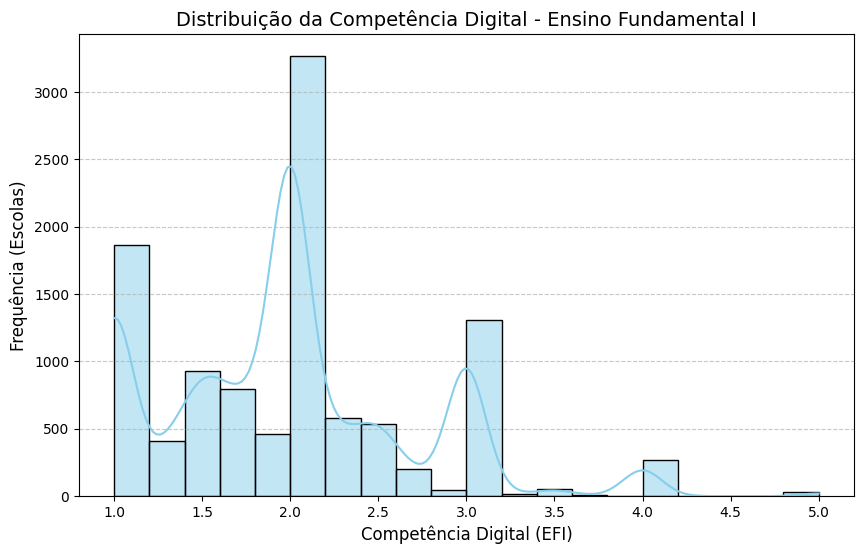

In [29]:
import matplotlib.pyplot as plt
import seaborn as sns

# Gerando o histograma para a média de PED do Ensino Fundamental I
plt.figure(figsize=(10, 6))
sns.histplot(data=base_escolas_final, x='comp_dig_EFI', bins=20, kde=True, color='skyblue')

# Adicionando títulos e rótulos
plt.title('Distribuição da Competência Digital - Ensino Fundamental I', fontsize=14)
plt.xlabel('Competência Digital (EFI)', fontsize=12)
plt.ylabel('Frequência (Escolas)', fontsize=12)
plt.grid(axis='y', linestyle='--', alpha=0.7)

# Exibindo o gráfico
plt.show()

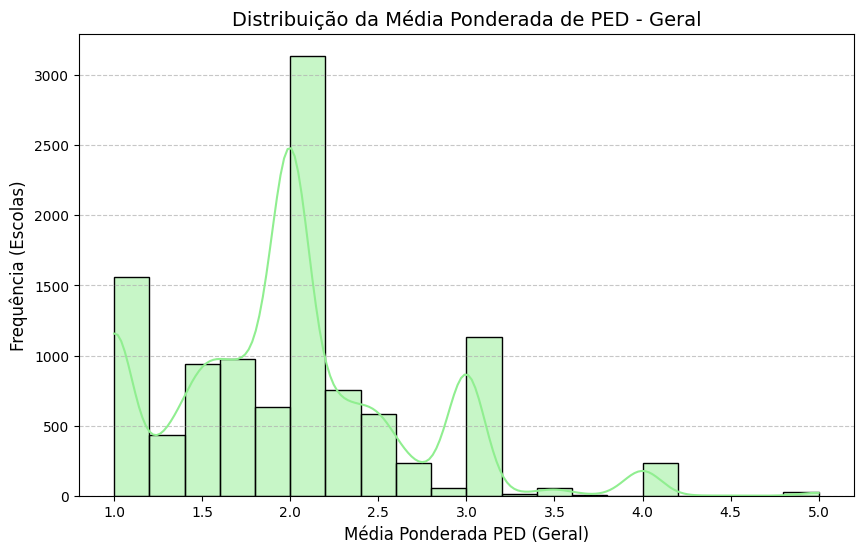

In [30]:
import matplotlib.pyplot as plt
import seaborn as sns

# Gerando o histograma para a média geral de PED por escola
plt.figure(figsize=(10, 6))
sns.histplot(data=base_escolas_final, x='comp_dig_geral', bins=20, kde=True, color='lightgreen')

# Adicionando títulos e rótulos
plt.title('Distribuição da Média Ponderada de PED - Geral', fontsize=14)
plt.xlabel('Média Ponderada PED (Geral)', fontsize=12)
plt.ylabel('Frequência (Escolas)', fontsize=12)
plt.grid(axis='y', linestyle='--', alpha=0.7)

# Exibindo o gráfico
plt.show()

In [31]:
media_ponderada_por_escola_ano_corrigido = base_escolas_final

In [32]:
# Filtrando 'id_escola' para checagem de cálculo e incluindo filtro por ano
# Em seguida, ordena o DataFrame resultante pelo 'ano' em ordem crescente
autoavaliacao[(autoavaliacao['id_escola'] == 1054675) & (autoavaliacao['ano'] == 2022)].sort_values(by='ano', ascending=True)

,id_professor,id_escola,ano,IBGE_Estado,Tipo de Rede,EFI,EFII,EM,PED,CID,DES,PED_EFI,PED_EFII,PED_EM
101284,ZmFiaWFuYS5sYWNlcmRhQHByb2YuZWR1Yy5yZWMuYnI5MT...,1054675,2022,26,Municipal,1,1,0,4,4,4,4.0,4.0,NaN
101285,Y2FybGkuY29zdGFAcHJvZi5lZHVjLnJlYy5icjkxNDFmZg==,1054675,2022,26,Municipal,0,0,0,4,4,4,NaN,NaN,NaN
101363,bHlnaWEuMTA1MjM1N0Bwcm9mLmVkdWMucmVjLmJyOTE0MWZm,1054675,2022,26,Municipal,1,1,0,3,4,4,3.0,3.0,NaN
101374,YWRlZ3VuZGVzLnNpbHZhQHByb2YuZWR1Yy5yZWMuYnI5MT...,1054675,2022,26,Municipal,0,0,0,5,4,5,NaN,NaN,NaN


In [33]:
# prompt: Calcule quantas observações do df "media_ponderada_por_escola_ano_corrigido" possui none simultaneamente para "PED_EFI", "PED_EFII" e "PED_EM"

# Calcule quantas observações do df "media_ponderada_por_escola_ano_corrigido" possui none simultaneamente para "PED_EFI", "PED_EFII" e "PED_EM"
num_nulas_ped_ponderado = media_ponderada_por_escola_ano_corrigido[
    (media_ponderada_por_escola_ano_corrigido['comp_dig_EFI'].isnull()) &
    (media_ponderada_por_escola_ano_corrigido['comp_dig_EFII'].isnull()) &
    (media_ponderada_por_escola_ano_corrigido['comp_dig_EM'].isnull())
].shape[0]

print(f"O número de observações com 'None' simultaneamente em 'comp_dig_PED_EFI', 'comp_dig_EFII' e 'comp_dig_EM' é: {num_nulas_ped_ponderado}")

O número de observações com 'None' simultaneamente em 'comp_dig_PED_EFI', 'comp_dig_EFII' e 'comp_dig_EM' é: 0


In [34]:
media_ponderada_por_escola_ano_corrigido.shape
print(num_nulas_ped_ponderado/media_ponderada_por_escola_ano_corrigido.shape[0])

0.0


**Adicionando número de educadores respondentes por escola**

In [35]:
# Calculate the total number of unique educators (id_professor) per id_escola over the period (2021, 2022, 2023)
# using autoavaliacao_periodo, which already contains data for these years.
num_educadores_por_escola = autoavaliacao_periodo.groupby('id_escola')['id_professor'].nunique().reset_index()

# Renomear a coluna para um nome mais descritivo
num_educadores_por_escola = num_educadores_por_escola.rename(columns={'id_professor': 'num_educadores'})

# Mesclar o novo DataFrame com o media_ponderada_por_escola_ano_corrigido
# Merge apenas em 'id_escola', pois media_ponderada_por_escola_ano_corrigido não tem 'ano'
media_ponderada_por_escola_ano_corrigido = pd.merge(
    media_ponderada_por_escola_ano_corrigido,
    num_educadores_por_escola,
    on=['id_escola'],
    how='left' # Usa um left join para manter todas as linhas do dataframe principal
)

# Exibir as primeiras linhas do DataFrame resultante para verificar a nova coluna
print("\nDataFrame com a contagem de educadores por escola:")
display(media_ponderada_por_escola_ano_corrigido.head(30))



DataFrame com a contagem de educadores por escola:


,id_escola,comp_dig_geral,comp_dig_EFI,comp_dig_EFII,comp_dig_EM,num_educadores_unicos,num_educadores
0,0,2.756757,2.842105,2.769231,2.756757,37,37
1,1,4.333333,4.333333,4.500000,4.000000,3,3
2,2,2.647059,2.333333,2.666667,2.818182,17,18
3,3,3.333333,3.000000,2.500000,3.000000,6,6
4,7,3.200000,3.500000,3.200000,3.200000,5,5
5,66,1.500000,1.500000,1.500000,1.500000,2,2
6,77,1.000000,1.000000,1.000000,1.000000,1,1
7,99,1.000000,1.000000,1.000000,1.000000,1,1
8,2086,3.000000,2.666667,3.000000,3.000000,4,4
9,2250,3.142857,3.142857,3.666667,3.142857,7,7


In [36]:
media_ponderada_por_escola_ano_corrigido.head(10)

,id_escola,comp_dig_geral,comp_dig_EFI,comp_dig_EFII,comp_dig_EM,num_educadores_unicos,num_educadores
0,0,2.756757,2.842105,2.769231,2.756757,37,37
1,1,4.333333,4.333333,4.500000,4.000000,3,3
2,2,2.647059,2.333333,2.666667,2.818182,17,18
3,3,3.333333,3.000000,2.500000,3.000000,6,6
4,7,3.200000,3.500000,3.200000,3.200000,5,5
5,66,1.500000,1.500000,1.500000,1.500000,2,2
6,77,1.000000,1.000000,1.000000,1.000000,1,1
7,99,1.000000,1.000000,1.000000,1.000000,1,1
8,2086,3.000000,2.666667,3.000000,3.000000,4,4
9,2250,3.142857,3.142857,3.666667,3.142857,7,7


In [37]:
print("Análise descritiva para a variável 'num_educadores':")
display(media_ponderada_por_escola_ano_corrigido['num_educadores'].describe())

Análise descritiva para a variável 'num_educadores':


,num_educadores
count,10781.000000
mean,7.099898
std,19.016396
min,1.000000
25%,1.000000
50%,2.000000
75%,8.000000
max,1661.000000


In [38]:
import numpy as np

# Definir os limites dos intervalos
bins = [0, 5, 10, 15, 20, np.inf]
# Definir os rótulos para cada intervalo
labels = ['0-5', '5-10', '10-15', '15-20', '20+']

# Criar uma nova coluna categorizando 'num_educadores' nos intervalos definidos
media_ponderada_por_escola_ano_corrigido['num_educadores_faixa'] = pd.cut(
    media_ponderada_por_escola_ano_corrigido['num_educadores_unicos'],
    bins=bins,
    labels=labels,
    right=False  # Inclui o limite inferior, exclui o superior (e.g., [0, 5) )
)

# Contar as ocorrências em cada faixa
contagem_faixas = media_ponderada_por_escola_ano_corrigido['num_educadores_faixa'].value_counts().sort_index()

print("Contagem de observações de 'num_educadores_unicos' por faixa:")
print(contagem_faixas)

Contagem de observações de 'num_educadores_unicos' por faixa:
num_educadores_faixa
0-5      6846
5-10     1632
10-15     769
15-20     491
20+      1043
Name: count, dtype: int64


Contando o número de observações por faixa de respondentes

In [39]:
print("Contagem de observações de 'num_educadores' por faixa, agrupadas por ano:")
contagem_por_ano_e_faixa = media_ponderada_por_escola_ano_corrigido.groupby(['num_educadores_faixa']).size().sort_index()
display(contagem_por_ano_e_faixa)

Contagem de observações de 'num_educadores' por faixa, agrupadas por ano:


/tmp/ipykernel_666/1759829231.py:2: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  contagem_por_ano_e_faixa = media_ponderada_por_escola_ano_corrigido.groupby(['num_educadores_faixa']).size().sort_index()


,0
num_educadores_faixa,
0-5,6846
5-10,1632
10-15,769
15-20,491
20+,1043


Gráficos da distruição do número de professores por escola

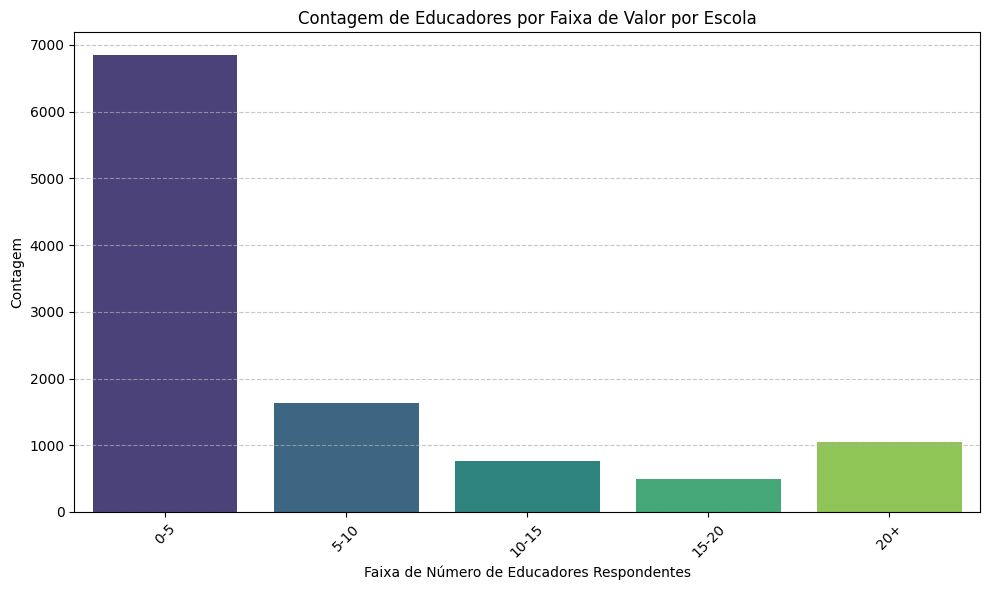

In [40]:
import matplotlib.pyplot as plt
import seaborn as sns

# Criar um gráfico de barras para visualizar a contagem de educadores por faixa
plt.figure(figsize=(10, 6))
sns.barplot(x=contagem_faixas.index, y=contagem_faixas.values, palette='viridis', hue=contagem_faixas.index, legend=False)
plt.title('Contagem de Educadores por Faixa de Valor por Escola')
plt.xlabel('Faixa de Número de Educadores Respondentes')
plt.ylabel('Contagem')
plt.xticks(rotation=45)
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()

In [41]:
media_ponderada_por_escola_ano_corrigido['id_escola'].nunique()

10781

In [42]:
counts_by_num_educators = {}
for num in range(1, 11):
    filtered_df = media_ponderada_por_escola_ano_corrigido[media_ponderada_por_escola_ano_corrigido['num_educadores'] == num]
    counts_by_num_educators[num] = filtered_df['id_escola'].nunique()

for num, count in counts_by_num_educators.items():
    print(f"Número de escolas com {num} educador(es) respondente(s): {count}")

Número de escolas com 1 educador(es) respondente(s): 4031
Número de escolas com 2 educador(es) respondente(s): 1413
Número de escolas com 3 educador(es) respondente(s): 803
Número de escolas com 4 educador(es) respondente(s): 594
Número de escolas com 5 educador(es) respondente(s): 450
Número de escolas com 6 educador(es) respondente(s): 391
Número de escolas com 7 educador(es) respondente(s): 317
Número de escolas com 8 educador(es) respondente(s): 234
Número de escolas com 9 educador(es) respondente(s): 221
Número de escolas com 10 educador(es) respondente(s): 223


In [43]:
media_ponderada_por_escola_ano_corrigido.describe()

,id_escola,comp_dig_geral,comp_dig_EFI,comp_dig_EFII,comp_dig_EM,num_educadores_unicos,num_educadores
count,1.078100e+04,10781.000000,10781.000000,10781.000000,10781.000000,10781.000000,10781.000000
mean,3.147415e+07,1.985587,1.977687,1.998974,1.995452,6.956961,7.099898
std,1.070010e+07,0.679097,0.714779,0.716743,0.699545,18.796893,19.016396
min,0.000000e+00,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000
25%,2.316900e+07,1.500000,1.500000,1.500000,1.500000,1.000000,1.000000
50%,2.902630e+07,2.000000,2.000000,2.000000,2.000000,2.000000,2.000000
75%,3.590465e+07,2.307692,2.333333,2.333333,2.333333,8.000000,8.000000
max,1.000000e+08,5.000000,5.000000,5.000000,5.000000,1659.000000,1661.000000


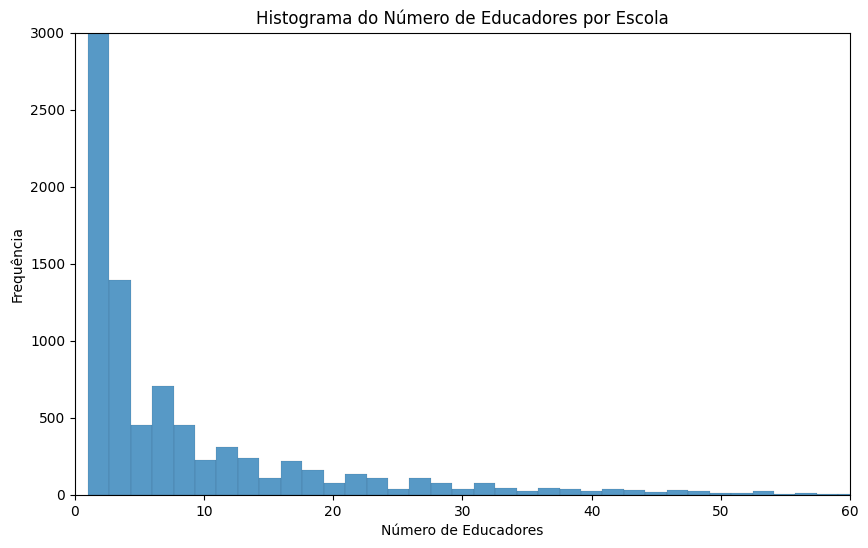

In [44]:
import matplotlib.pyplot as plt
import seaborn as sns # Importar seaborn

# Cria o histograma
plt.figure(figsize=(10, 6)) # Define o tamanho da figura
sns.histplot(data=media_ponderada_por_escola_ano_corrigido, x='num_educadores', bins=1000, kde=False) # Cria o histograma

# Define os limites dos eixos
plt.ylim(0, 3000)
plt.xlim(0, 60) # Corrigido para o limite de 100 no eixo x conforme solicitado no prompt original

# Adiciona títulos e rótulos
plt.title('Histograma do Número de Educadores por Escola')
plt.xlabel('Número de Educadores')
plt.ylabel('Frequência')

# Exibe o gráfico
plt.show()

Considerando um mínimo de 5 professores respondentes por escola

In [45]:
media_ponderada_por_escola_ano_corrigido = media_ponderada_por_escola_ano_corrigido[
    media_ponderada_por_escola_ano_corrigido['num_educadores_unicos'] >= 5
].copy()

print("DataFrame 'media_ponderada_por_escola_ano_corrigido' após o filtro (num_educadores_unicos >= 5):")
display(media_ponderada_por_escola_ano_corrigido.head())
print(f"Novo shape do DataFrame: {media_ponderada_por_escola_ano_corrigido.shape}")

DataFrame 'media_ponderada_por_escola_ano_corrigido' após o filtro (num_educadores_unicos >= 5):


,id_escola,comp_dig_geral,comp_dig_EFI,comp_dig_EFII,comp_dig_EM,num_educadores_unicos,num_educadores,num_educadores_faixa
0,0,2.756757,2.842105,2.769231,2.756757,37,37,20+
2,2,2.647059,2.333333,2.666667,2.818182,17,18,15-20
3,3,3.333333,3.000000,2.500000,3.000000,6,6,5-10
4,7,3.200000,3.500000,3.200000,3.200000,5,5,5-10
9,2250,3.142857,3.142857,3.666667,3.142857,7,7,5-10


Novo shape do DataFrame: (3935, 8)


In [46]:
print("Análise descritiva para a variável 'num_educadores' no DataFrame filtrado:")
display(media_ponderada_por_escola_ano_corrigido['num_educadores_unicos'].describe())

Análise descritiva para a variável 'num_educadores' no DataFrame filtrado:


,num_educadores_unicos
count,3935.000000
mean,16.104447
std,28.891168
min,5.000000
25%,7.000000
50%,11.000000
75%,20.000000
max,1659.000000


# Histograma da comp_dig_geral

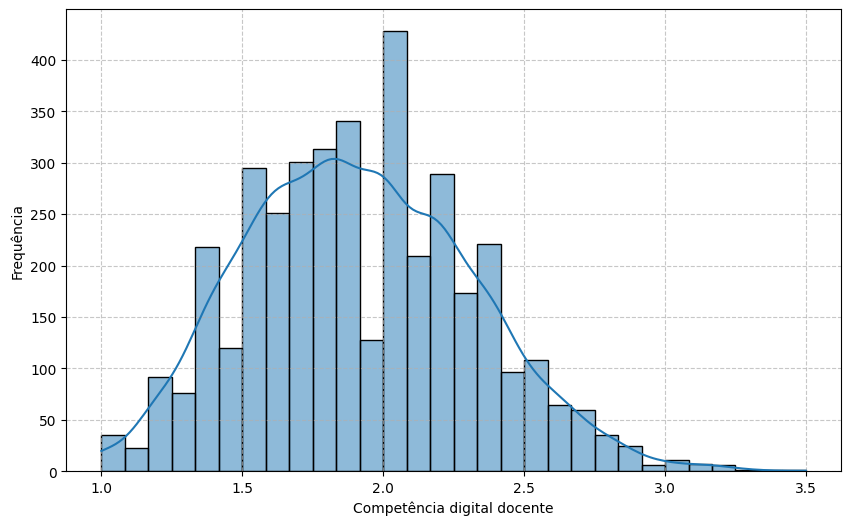

In [47]:
import matplotlib.pyplot as plt
import seaborn as sns

# Filtrar o DataFrame para o ano de 2021

# Criar o histograma para 'media_ponderada_PED' com KDE
plt.figure(figsize=(10, 6))
sns.histplot(media_ponderada_por_escola_ano_corrigido, x='comp_dig_geral', bins=30, kde=True)
plt.title('')
plt.xlabel('Competência digital docente')
plt.ylabel('Frequência')
plt.grid(True, linestyle='--', alpha=0.7)
plt.show()

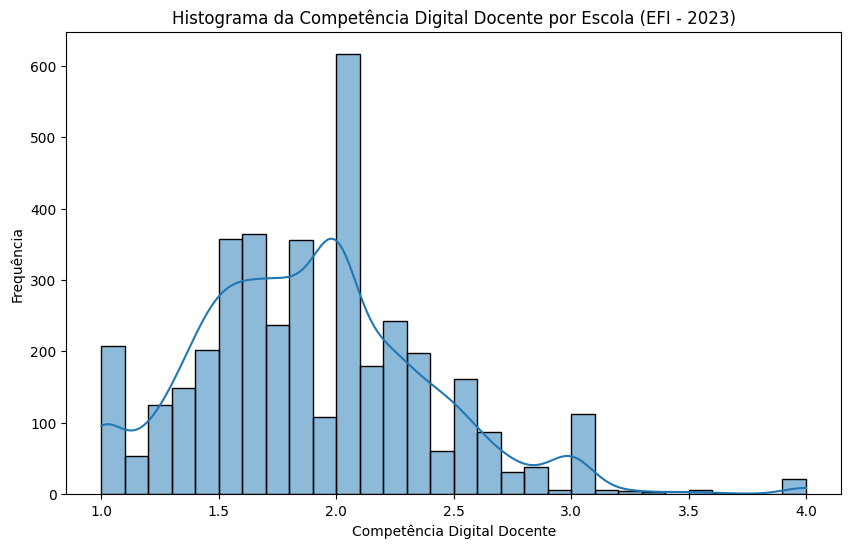

In [48]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(10, 6))
sns.histplot(data=media_ponderada_por_escola_ano_corrigido, x='comp_dig_EFI', bins=30, kde=True)
plt.title('Histograma da Competência Digital Docente por Escola (EFI - 2023)')
plt.xlabel('Competência Digital Docente')
plt.ylabel('Frequência')
plt.show()

In [49]:
# prompt: Filtre a observação que contém 1189.000000 educadores

media_ponderada_por_escola_ano_corrigido[media_ponderada_por_escola_ano_corrigido['num_educadores'] == 1189]


,id_escola,comp_dig_geral,comp_dig_EFI,comp_dig_EFII,comp_dig_EM,num_educadores_unicos,num_educadores,num_educadores_faixa


# Importando base IDEB

In [50]:
# Importação da base do IDEB

IDEB_escola = pd.read_csv("/content/drive/MyDrive/MBA Data Analytics/TCC/Bases/IDEB/Base_IDEB_agosto 2025.csv", delimiter=',')

IDEB_escola['ano'].unique()
IDEB_escola.dtypes
IDEB_escola.head()

,ano,anos_escolares,ensino,id_escola,id_municipio,ideb,nota_saeb_lingua_portuguesa,nota_saeb_matematica,rede,sigla_uf
0,2019,todos (1-4),medio,11000058,1100205,NaN,NaN,NaN,privada,RO
1,2019,todos (1-4),medio,11000244,1100205,NaN,NaN,NaN,privada,RO
2,2023,todos (1-4),medio,11000252,1100205,NaN,NaN,NaN,privada,RO
3,2021,iniciais (1-5),fundamental,11000295,1100205,NaN,NaN,NaN,estadual,RO
4,2017,finais (6-9),fundamental,11000368,1100205,NaN,NaN,NaN,municipal,RO


In [51]:
IDEB_escola.shape

(627992, 10)

In [52]:
# Contar o número de escolas com id_escola igual a 0
IDEB_escola[IDEB_escola['id_escola'] == 0].shape[0]

# Contar o número de escolas com id_escola nulo
IDEB_escola['id_escola'].isnull().sum()

print(f"Número de escolas com id_escola = 0: {IDEB_escola[IDEB_escola['id_escola'] == 0].shape[0]}")
print(f"Número de escolas com id_escola nulo: {IDEB_escola['id_escola'].isnull().sum()}")

Número de escolas com id_escola = 0: 0
Número de escolas com id_escola nulo: 0


In [53]:
substituicoes = {
    'iniciais (1-5)': "EFI",
    'finais (6-9)' : 'EFII',
    'todos (1-4)': 'EM'
}

# Aplica a substituição na coluna 'anos_escolares'
# Usa apply com lambda para verificar a qual chave do dicionário cada valor da coluna 'anos_escolares' corresponde
IDEB_escola['anos_escolares'] = IDEB_escola['anos_escolares'].apply(lambda x: substituicoes.get(x, x))

# O .get(x, x) tenta encontrar a chave x no dicionário 'substituicoes'.
# Se encontrar, retorna o valor correspondente (por exemplo, 'iniciais (1-5)' para 'EFI').
# Se não encontrar (para valores que não são EFI, EFII, ou EM), retorna o próprio valor x (mantendo-o inalterado).

print(IDEB_escola[['anos_escolares']].head()) # Exemplo para verificar as primeiras linhas após a mudança


  anos_escolares
0             EM
1             EM
2             EM
3            EFI
4           EFII


In [54]:
IDEB_escola

,ano,anos_escolares,ensino,id_escola,id_municipio,ideb,nota_saeb_lingua_portuguesa,nota_saeb_matematica,rede,sigla_uf
0,2019,EM,medio,11000058,1100205,NaN,NaN,NaN,privada,RO
1,2019,EM,medio,11000244,1100205,NaN,NaN,NaN,privada,RO
2,2023,EM,medio,11000252,1100205,NaN,NaN,NaN,privada,RO
3,2021,EFI,fundamental,11000295,1100205,NaN,NaN,NaN,estadual,RO
4,2017,EFII,fundamental,11000368,1100205,NaN,NaN,NaN,municipal,RO
...,...,...,...,...,...,...,...,...,...,...
627987,2023,EM,medio,29034990,2924009,1.8,254.63,251.54,estadual,BA
627988,2019,EFII,fundamental,29037255,2902708,1.8,196.36,194.19,municipal,BA
627989,2015,EFII,fundamental,29130638,2922904,1.8,216.60,215.92,municipal,BA
627990,2019,EFII,fundamental,31079359,3107307,1.8,189.08,196.30,estadual,MG


Contando quantas observações da variável ideb são nulas e quantas não são nulas


In [55]:
num_nulos_ideb = IDEB_escola['ideb'].isnull().sum()
num_nao_nulos_ideb = IDEB_escola['ideb'].notnull().sum()

print(f"Número de observações nulas para 'ideb' em IDEB_escola: {num_nulos_ideb}")
print(f"Número de observações não nulas para 'ideb' em IDEB_escola: {num_nao_nulos_ideb}")

Número de observações nulas para 'ideb' em IDEB_escola: 250094
Número de observações não nulas para 'ideb' em IDEB_escola: 377898


In [56]:
# Remove as linhas onde a coluna 'ideb' possui valores nulos
IDEB_escola = IDEB_escola.dropna(subset=['ideb'])

print("DataFrame IDEB_escola após a remoção de nulos em 'ideb':")
display(IDEB_escola.head())

DataFrame IDEB_escola após a remoção de nulos em 'ideb':


,ano,anos_escolares,ensino,id_escola,id_municipio,ideb,nota_saeb_lingua_portuguesa,nota_saeb_matematica,rede,sigla_uf
49936,2021,EFII,fundamental,13008056,1304062,2.0,166.67,162.39,municipal,AM
49937,2015,EFI,fundamental,15017583,1500503,2.0,137.17,164.03,municipal,PA
49938,2017,EFII,fundamental,15072681,1502103,2.0,219.13,219.24,municipal,PA
49939,2023,EFII,fundamental,15074951,1503309,2.0,221.69,237.43,municipal,PA
49940,2017,EFII,fundamental,15083276,1504703,2.0,192.99,187.30,municipal,PA


# Censo Escolar


In [57]:
censo_escolar = pd.read_csv("/content/drive/MyDrive/MBA Data Analytics/TCC/Bases/Censo Escolar/V2_Censo Escolar_agosto 2025.csv", delimiter=',')

In [58]:
censo_escolar.head(10)

,id_escola,ano,laboratorio_informatica,quantidade_docente_educacao_basica,quantidade_docente_fundamental_anos_iniciais,quantidade_docente_fundamental_anos_finais,quantidade_docente_medio,quantidade_matricula_educacao_basica,quantidade_matricula_branca,quantidade_matricula_parda,quantidade_matricula_preta,quadra_esportes,agua_potavel,biblioteca_sala_leitura
0,22250727,2014,0.0,9.0,8.0,0.0,0.0,646.0,7.0,622.0,5.0,0.0,NaN,0.0
1,25055364,2014,0.0,11.0,6.0,0.0,0.0,1089.0,81.0,372.0,0.0,0.0,NaN,0.0
2,22131892,2014,0.0,20.0,10.0,0.0,0.0,662.0,62.0,405.0,61.0,0.0,NaN,0.0
3,15058697,2014,0.0,3.0,0.0,0.0,0.0,591.0,13.0,423.0,0.0,0.0,NaN,1.0
4,26177200,2014,0.0,9.0,6.0,0.0,0.0,734.0,197.0,332.0,8.0,1.0,NaN,1.0
5,15162931,2014,0.0,10.0,0.0,0.0,0.0,657.0,26.0,77.0,2.0,1.0,NaN,0.0
6,15520625,2014,0.0,4.0,0.0,4.0,0.0,641.0,4.0,497.0,0.0,1.0,NaN,1.0
7,26178036,2014,0.0,29.0,0.0,0.0,29.0,922.0,85.0,346.0,19.0,1.0,NaN,0.0
8,26156300,2014,0.0,10.0,0.0,0.0,0.0,610.0,126.0,271.0,8.0,0.0,NaN,1.0
9,15100812,2014,0.0,5.0,5.0,0.0,0.0,391.0,121.0,32.0,7.0,0.0,NaN,0.0


In [59]:
censo_escolar.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4058464 entries, 0 to 4058463
Data columns (total 14 columns):
 #   Column                                        Dtype  
---  ------                                        -----  
 0   id_escola                                     int64  
 1   ano                                           int64  
 2   laboratorio_informatica                       float64
 3   quantidade_docente_educacao_basica            float64
 4   quantidade_docente_fundamental_anos_iniciais  float64
 5   quantidade_docente_fundamental_anos_finais    float64
 6   quantidade_docente_medio                      float64
 7   quantidade_matricula_educacao_basica          float64
 8   quantidade_matricula_branca                   float64
 9   quantidade_matricula_parda                    float64
 10  quantidade_matricula_preta                    float64
 11  quadra_esportes                               float64
 12  agua_potavel                                  float64
 1

In [60]:
censo_escolar.describe()

,id_escola,ano,laboratorio_informatica,quantidade_docente_educacao_basica,quantidade_docente_fundamental_anos_iniciais,quantidade_docente_fundamental_anos_finais,quantidade_docente_medio,quantidade_matricula_educacao_basica,quantidade_matricula_branca,quantidade_matricula_parda,quantidade_matricula_preta,quadra_esportes,agua_potavel,biblioteca_sala_leitura
count,4.058464e+06,4.058464e+06,3.412818e+06,3.352839e+06,3.352839e+06,3.352839e+06,3.352839e+06,3.368894e+06,3.368894e+06,3.368894e+06,3.368894e+06,3.412818e+06,1.085172e+06,3.412818e+06
mean,3.003992e+07,2.015581e+03,3.566144e-01,1.465605e+01,4.423447e+00,5.056621e+00,3.262801e+00,2.641862e+02,7.640925e+01,8.551711e+01,8.633592e+00,3.240548e-01,5.478708e-01,4.701678e-01
std,9.397401e+06,5.061080e+00,4.789996e-01,1.548251e+01,6.855886e+00,8.632932e+00,9.511274e+00,3.488015e+02,1.515823e+02,1.420076e+02,2.266121e+01,4.680207e-01,4.977033e-01,4.991093e-01
min,1.100002e+07,2.007000e+03,0.000000e+00,1.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,1.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00
25%,2.320302e+07,2.011000e+03,0.000000e+00,4.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,5.100000e+01,4.000000e+00,8.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00
50%,2.955061e+07,2.016000e+03,0.000000e+00,1.000000e+01,1.000000e+00,0.000000e+00,0.000000e+00,1.390000e+02,2.400000e+01,3.100000e+01,2.000000e+00,0.000000e+00,1.000000e+00,0.000000e+00
75%,3.520697e+07,2.020000e+03,1.000000e+00,2.000000e+01,7.000000e+00,8.000000e+00,0.000000e+00,3.460000e+02,8.500000e+01,1.020000e+02,8.000000e+00,1.000000e+00,1.000000e+00,1.000000e+00
max,5.308803e+07,2.024000e+03,1.000000e+00,1.293000e+03,1.340000e+02,1.710000e+02,3.890000e+02,5.489600e+04,4.655600e+04,1.615100e+04,6.305000e+03,1.000000e+00,1.000000e+00,1.000000e+00


In [61]:
censo_escolar.shape

(4058464, 14)

In [62]:
censo_escolar_sem_nulos = censo_escolar.drop(columns=['agua_potavel'])

In [63]:
# Remover observações com valores nulos
censo_escolar_sem_nulos.dropna()

,id_escola,ano,laboratorio_informatica,quantidade_docente_educacao_basica,quantidade_docente_fundamental_anos_iniciais,quantidade_docente_fundamental_anos_finais,quantidade_docente_medio,quantidade_matricula_educacao_basica,quantidade_matricula_branca,quantidade_matricula_parda,quantidade_matricula_preta,quadra_esportes,biblioteca_sala_leitura
0,22250727,2014,0.0,9.0,8.0,0.0,0.0,646.0,7.0,622.0,5.0,0.0,0.0
1,25055364,2014,0.0,11.0,6.0,0.0,0.0,1089.0,81.0,372.0,0.0,0.0,0.0
2,22131892,2014,0.0,20.0,10.0,0.0,0.0,662.0,62.0,405.0,61.0,0.0,0.0
3,15058697,2014,0.0,3.0,0.0,0.0,0.0,591.0,13.0,423.0,0.0,0.0,1.0
4,26177200,2014,0.0,9.0,6.0,0.0,0.0,734.0,197.0,332.0,8.0,1.0,1.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...
4058458,21016437,2017,1.0,78.0,44.0,26.0,0.0,1922.0,252.0,1072.0,38.0,1.0,1.0
4058459,32094426,2017,1.0,4.0,0.0,2.0,0.0,1420.0,886.0,490.0,22.0,1.0,1.0
4058460,21288003,2017,1.0,1.0,0.0,1.0,0.0,1697.0,150.0,868.0,33.0,0.0,1.0
4058461,21020850,2017,0.0,41.0,5.0,27.0,27.0,1554.0,180.0,1011.0,91.0,0.0,1.0


In [64]:
censo_escolar_sem_nulos.shape

(4058464, 13)

In [65]:
#Pesquisando ID_escola "11000058"

censo_escolar_sem_nulos[censo_escolar_sem_nulos['id_escola'] == 11000058]

,id_escola,ano,laboratorio_informatica,quantidade_docente_educacao_basica,quantidade_docente_fundamental_anos_iniciais,quantidade_docente_fundamental_anos_finais,quantidade_docente_medio,quantidade_matricula_educacao_basica,quantidade_matricula_branca,quantidade_matricula_parda,quantidade_matricula_preta,quadra_esportes,biblioteca_sala_leitura
162963,11000058,2021,1.0,69.0,17.0,25.0,30.0,1280.0,573.0,333.0,20.0,1.0,1.0
345033,11000058,2022,1.0,68.0,17.0,22.0,32.0,1289.0,583.0,353.0,15.0,1.0,1.0
744332,11000058,2011,1.0,58.0,12.0,25.0,27.0,1439.0,680.0,368.0,26.0,1.0,1.0
946447,11000058,2014,1.0,63.0,16.0,27.0,24.0,1350.0,564.0,271.0,22.0,1.0,1.0
995591,11000058,2007,1.0,31.0,5.0,21.0,14.0,1130.0,16.0,4.0,0.0,1.0,1.0
1035574,11000058,2016,1.0,65.0,21.0,23.0,24.0,1476.0,606.0,304.0,22.0,1.0,1.0
1128037,11000058,2012,1.0,56.0,14.0,23.0,22.0,1568.0,672.0,346.0,23.0,1.0,1.0
1182601,11000058,2015,1.0,58.0,17.0,25.0,25.0,1379.0,547.0,269.0,21.0,1.0,1.0
1330230,11000058,2009,1.0,62.0,11.0,29.0,26.0,1291.0,132.0,47.0,0.0,1.0,1.0
1667398,11000058,2023,1.0,66.0,16.0,26.0,29.0,1229.0,687.0,467.0,18.0,1.0,1.0


In [66]:
# Alterando variáveis para inteiras
censo_escolar_sem_nulos['quantidade_matricula_branca'] = censo_escolar_sem_nulos['quantidade_matricula_branca'].fillna(0).astype('int')
censo_escolar_sem_nulos['quantidade_matricula_educacao_basica'] = censo_escolar_sem_nulos['quantidade_matricula_educacao_basica'].fillna(0).astype('int')
censo_escolar_sem_nulos['quantidade_matricula_preta'] = censo_escolar_sem_nulos['quantidade_matricula_preta'].fillna(0).astype('int')

censo_escolar_sem_nulos['quantidade_docente_fundamental_anos_iniciais'] = censo_escolar_sem_nulos['quantidade_docente_fundamental_anos_iniciais'].fillna(0).astype('int')
censo_escolar_sem_nulos['quantidade_docente_fundamental_anos_finais'] = censo_escolar_sem_nulos['quantidade_docente_fundamental_anos_finais'].fillna(0).astype('int')
censo_escolar_sem_nulos['quantidade_docente_medio'] = censo_escolar_sem_nulos['quantidade_docente_medio'].fillna(0).astype('int')

censo_escolar_sem_nulos['quantidade_matricula_parda'] = censo_escolar_sem_nulos['quantidade_matricula_parda'].fillna(0).astype('int')

censo_escolar_sem_nulos['quantidade_docente_educacao_basica'] = censo_escolar_sem_nulos['quantidade_docente_educacao_basica'].fillna(0).astype('int')

In [67]:
censo_escolar_sem_nulos.head(10)

,id_escola,ano,laboratorio_informatica,quantidade_docente_educacao_basica,quantidade_docente_fundamental_anos_iniciais,quantidade_docente_fundamental_anos_finais,quantidade_docente_medio,quantidade_matricula_educacao_basica,quantidade_matricula_branca,quantidade_matricula_parda,quantidade_matricula_preta,quadra_esportes,biblioteca_sala_leitura
0,22250727,2014,0.0,9,8,0,0,646,7,622,5,0.0,0.0
1,25055364,2014,0.0,11,6,0,0,1089,81,372,0,0.0,0.0
2,22131892,2014,0.0,20,10,0,0,662,62,405,61,0.0,0.0
3,15058697,2014,0.0,3,0,0,0,591,13,423,0,0.0,1.0
4,26177200,2014,0.0,9,6,0,0,734,197,332,8,1.0,1.0
5,15162931,2014,0.0,10,0,0,0,657,26,77,2,1.0,0.0
6,15520625,2014,0.0,4,0,4,0,641,4,497,0,1.0,1.0
7,26178036,2014,0.0,29,0,0,29,922,85,346,19,1.0,0.0
8,26156300,2014,0.0,10,0,0,0,610,126,271,8,0.0,1.0
9,15100812,2014,0.0,5,5,0,0,391,121,32,7,0.0,0.0


In [68]:
censo_escolar_sem_nulos.describe()

,id_escola,ano,laboratorio_informatica,quantidade_docente_educacao_basica,quantidade_docente_fundamental_anos_iniciais,quantidade_docente_fundamental_anos_finais,quantidade_docente_medio,quantidade_matricula_educacao_basica,quantidade_matricula_branca,quantidade_matricula_parda,quantidade_matricula_preta,quadra_esportes,biblioteca_sala_leitura
count,4.058464e+06,4.058464e+06,3.412818e+06,4.058464e+06,4.058464e+06,4.058464e+06,4.058464e+06,4.058464e+06,4.058464e+06,4.058464e+06,4.058464e+06,3.412818e+06,3.412818e+06
mean,3.003992e+07,2.015581e+03,3.566144e-01,1.210788e+01,3.654364e+00,4.177451e+00,2.695514e+00,2.192985e+02,6.342662e+01,7.098697e+01,7.166666e+00,3.240548e-01,4.701678e-01
std,9.397401e+06,5.061080e+00,4.789996e-01,1.512892e+01,6.453021e+00,8.077281e+00,8.732976e+00,3.329185e+02,1.410553e+02,1.333086e+02,2.089951e+01,4.680207e-01,4.991093e-01
min,1.100002e+07,2.007000e+03,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00
25%,2.320302e+07,2.011000e+03,0.000000e+00,1.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,2.000000e+01,0.000000e+00,1.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00
50%,2.955061e+07,2.016000e+03,0.000000e+00,7.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,9.600000e+01,1.300000e+01,1.900000e+01,1.000000e+00,0.000000e+00,0.000000e+00
75%,3.520697e+07,2.020000e+03,1.000000e+00,1.700000e+01,5.000000e+00,5.000000e+00,0.000000e+00,2.850000e+02,6.600000e+01,7.900000e+01,6.000000e+00,1.000000e+00,1.000000e+00
max,5.308803e+07,2.024000e+03,1.000000e+00,1.293000e+03,1.340000e+02,1.710000e+02,3.890000e+02,5.489600e+04,4.655600e+04,1.615100e+04,6.305000e+03,1.000000e+00,1.000000e+00


In [69]:
censo_escolar_sem_nulos.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4058464 entries, 0 to 4058463
Data columns (total 13 columns):
 #   Column                                        Dtype  
---  ------                                        -----  
 0   id_escola                                     int64  
 1   ano                                           int64  
 2   laboratorio_informatica                       float64
 3   quantidade_docente_educacao_basica            int64  
 4   quantidade_docente_fundamental_anos_iniciais  int64  
 5   quantidade_docente_fundamental_anos_finais    int64  
 6   quantidade_docente_medio                      int64  
 7   quantidade_matricula_educacao_basica          int64  
 8   quantidade_matricula_branca                   int64  
 9   quantidade_matricula_parda                    int64  
 10  quantidade_matricula_preta                    int64  
 11  quadra_esportes                               float64
 12  biblioteca_sala_leitura                       float64
dt

In [70]:
censo_escolar_sem_nulos['quadra_esportes'] = censo_escolar_sem_nulos['quadra_esportes'].astype(bool)
censo_escolar_sem_nulos['biblioteca_sala_leitura'] = censo_escolar_sem_nulos['biblioteca_sala_leitura'].astype(bool)
censo_escolar_sem_nulos['laboratorio_informatica'] = censo_escolar_sem_nulos['laboratorio_informatica'].astype(bool)

display(censo_escolar_sem_nulos.head())

,id_escola,ano,laboratorio_informatica,quantidade_docente_educacao_basica,quantidade_docente_fundamental_anos_iniciais,quantidade_docente_fundamental_anos_finais,quantidade_docente_medio,quantidade_matricula_educacao_basica,quantidade_matricula_branca,quantidade_matricula_parda,quantidade_matricula_preta,quadra_esportes,biblioteca_sala_leitura
0,22250727,2014,False,9,8,0,0,646,7,622,5,False,False
1,25055364,2014,False,11,6,0,0,1089,81,372,0,False,False
2,22131892,2014,False,20,10,0,0,662,62,405,61,False,False
3,15058697,2014,False,3,0,0,0,591,13,423,0,False,True
4,26177200,2014,False,9,6,0,0,734,197,332,8,True,True


#Base IDH - Renda

In [71]:
idh = pd.read_csv("/content/drive/MyDrive/MBA Data Analytics/TCC/Bases/IDH_renda.csv", delimiter=',')

In [72]:
idh.head(10)

,ano,id_municipio,expectativa_vida,fecundidade_total,mortalidade_1,mortalidade_5,razao_dependencia,prob_sobrevivencia_40,prob_sobrevivencia_60,taxa_envelhecimento,...,pia,pia_10_14,pia_15_17,pia_18_mais,indice_escolaridade,indice_frequencia_escolar,idhm,idhm_e,idhm_l,idhm_r
0,1991,1100015,62.01,4.08,45.58,58.05,73.50,83.81,66.87,1.82,...,NaN,NaN,NaN,NaN,0.117,0.109,0.329,0.112,0.617,0.516
1,1991,1100023,66.02,3.72,32.39,41.41,69.97,88.08,74.23,1.82,...,NaN,NaN,NaN,NaN,0.200,0.199,0.432,0.199,0.684,0.593
2,1991,1100031,63.16,3.89,41.52,52.94,77.23,85.09,69.00,2.59,...,NaN,NaN,NaN,NaN,0.111,0.106,0.309,0.108,0.636,0.430
3,1991,1100049,65.03,3.81,35.37,45.19,71.11,87.08,72.44,2.47,...,NaN,NaN,NaN,NaN,0.176,0.169,0.407,0.171,0.667,0.593
4,1991,1100056,62.73,3.55,43.00,54.82,71.09,84.62,68.20,2.46,...,NaN,NaN,NaN,NaN,0.152,0.175,0.386,0.167,0.629,0.547
5,1991,1100064,64.46,3.38,37.19,47.49,75.82,86.49,71.39,2.71,...,NaN,NaN,NaN,NaN,0.148,0.152,0.376,0.151,0.658,0.536
6,1991,1100072,59.32,3.95,56.02,71.15,83.03,80.64,61.89,1.68,...,NaN,NaN,NaN,NaN,0.035,0.041,0.203,0.039,0.572,0.373
7,1991,1100080,62.76,4.19,42.90,54.69,86.44,84.65,68.26,2.49,...,NaN,NaN,NaN,NaN,0.236,0.213,0.425,0.220,0.629,0.553
8,1991,1100098,64.18,3.84,38.09,48.63,74.24,86.19,70.88,2.14,...,NaN,NaN,NaN,NaN,0.158,0.159,0.388,0.159,0.653,0.561
9,1991,1100106,64.71,4.19,36.41,46.50,81.03,86.74,71.84,3.56,...,NaN,NaN,NaN,NaN,0.319,0.217,0.468,0.247,0.662,0.625


In [73]:
print(idh['ano'].unique())

[1991 2000 2010]


In [74]:
idh.describe()

,ano,id_municipio,expectativa_vida,fecundidade_total,mortalidade_1,mortalidade_5,razao_dependencia,prob_sobrevivencia_40,prob_sobrevivencia_60,taxa_envelhecimento,...,pia,pia_10_14,pia_15_17,pia_18_mais,indice_escolaridade,indice_frequencia_escolar,idhm,idhm_e,idhm_l,idhm_r
count,16695.000000,1.669500e+04,16695.000000,16695.000000,16695.000000,16695.000000,16695.000000,16695.000000,16695.000000,16695.000000,...,1.113000e+04,11130.000000,11130.000000,1.113000e+04,16695.000000,16695.000000,16695.000000,16695.000000,16695.000000,16695.000000
mean,2000.333333,3.253053e+06,68.411614,2.929683,33.267208,40.237872,62.984688,89.783321,75.952320,6.686915,...,2.684299e+04,3090.009164,1894.061096,2.185892e+04,0.261320,0.434967,0.521337,0.363999,0.723611,0.577702
std,7.760530,9.844625e+05,5.445469,1.080477,20.216337,26.713457,16.340529,4.852183,7.841515,2.417843,...,1.660532e+05,15854.441775,9909.651466,1.405479e+05,0.142525,0.225825,0.147535,0.187777,0.090760,0.104795
min,1991.000000,1.100015e+06,50.970000,1.210000,8.490000,9.980000,19.690000,69.060000,47.940000,0.280000,...,5.870000e+02,48.000000,15.000000,5.250000e+02,0.002000,0.007000,0.120000,0.010000,0.433000,0.229000
25%,1991.000000,2.512101e+06,64.830000,2.210000,18.440000,21.180000,51.000000,87.100000,71.120000,4.990000,...,4.203250e+03,518.000000,319.000000,3.358250e+03,0.147000,0.238000,0.409000,0.203000,0.664000,0.502000
50%,2000.000000,3.146206e+06,69.190000,2.630000,27.000000,30.480000,59.070000,91.390000,77.850000,6.450000,...,8.720000e+03,1104.000000,671.000000,6.862500e+03,0.248000,0.434000,0.539000,0.361000,0.737000,0.582000
75%,2010.000000,4.119004e+06,72.650000,3.360000,41.615000,51.300000,71.835000,93.380000,81.970000,8.180000,...,1.811625e+04,2378.000000,1425.000000,1.426175e+04,0.359000,0.634000,0.638500,0.522000,0.794000,0.660000
max,2010.000000,5.300108e+06,78.640000,8.680000,120.120000,151.600000,137.210000,97.090000,90.810000,20.420000,...,9.783868e+06,879475.000000,574557.000000,8.410471e+06,0.800000,0.962000,0.862000,0.825000,0.894000,0.891000


In [75]:
idh_filtrado = idh[['ano','id_municipio','idhm_r']].copy()

# Ordenar por 'ano' em ordem descendente e exibir o head
display(idh_filtrado.sort_values(by='ano', ascending=False).head())
idh_filtrado['ano'].unique()

,ano,id_municipio,idhm_r
16676,2010,5221007,0.700
16694,2010,5300108,0.863
16693,2010,5222302,0.629
16692,2010,5222203,0.619
16691,2010,5222054,0.707


array([1991, 2000, 2010])

In [76]:
censo_escolar.shape

(4058464, 14)

In [77]:
print(censo_escolar_sem_nulos.columns)

Index(['id_escola', 'ano', 'laboratorio_informatica',
       'quantidade_docente_educacao_basica',
       'quantidade_docente_fundamental_anos_iniciais',
       'quantidade_docente_fundamental_anos_finais',
       'quantidade_docente_medio', 'quantidade_matricula_educacao_basica',
       'quantidade_matricula_branca', 'quantidade_matricula_parda',
       'quantidade_matricula_preta', 'quadra_esportes',
       'biblioteca_sala_leitura'],
      dtype='object')


# Base do Indicador de Nível Socioeconômico (INSE)



In [78]:
#Ano de 2023
INSE_2023_escolas = pd.read_csv('/content/drive/MyDrive/MBA Data Analytics/TCC/Bases/INSe/INSE_2023_escolas.xlsx - INSE_ESC_2023.csv', delimiter=',')

#Ano de 2021
INSE_2021_escolas = pd.read_csv('/content/drive/MyDrive/MBA Data Analytics/TCC/Bases/INSe/INSE_2021.csv', delimiter=',')

#Ano de 2019
INSE_2019_escolas = pd.read_csv('/content/drive/MyDrive/MBA Data Analytics/TCC/Bases/INSe/INSE_2019.csv', delimiter=',')

INSE_2023_escolas.head(5)
INSE_2021_escolas.head(5)
INSE_2019_escolas.head(5)

,NU_ANO_SAEB,ID_ESCOLA,NOME_ESCOLA,CO_UF,NOME_UF,CO_MUNICIPIO,NOME_MUNICIPIO,ID_AREA,TP_DEPENDENCIA,TP_LOCALIZACAO,...,MEDIA_INSE,INSE_CLASSIFICACAO,PC_NIVEL_1,PC_NIVEL_2,PC_NIVEL_3,PC_NIVEL_4,PC_NIVEL_5,PC_NIVEL_6,PC_NIVEL_7,PC_NIVEL_8
0,2019,11024666,EMEIEF BOA ESPERANCA,11,Rondônia,1100015,Alta Floresta D'Oeste,2,3,2,...,"4,54000000",Nível IV,0,"16,67","33,33","33,33","13,61","3,06",0,0
1,2019,11024682,EEEF EURIDICE LOPES PEDROSO,11,Rondônia,1100015,Alta Floresta D'Oeste,2,2,1,...,"4,96000000",Nível IV,0,"15,67","16,69","22,32","17,46","15,67","10,05","2,14"
2,2019,11024828,EMEIEF IZIDORO STEDILE,11,Rondônia,1100015,Alta Floresta D'Oeste,2,3,1,...,"4,87000000",Nível IV,0,"3,39","26,48","33,37","23,34","10,04","3,39",0
3,2019,11024968,EEEMTI JUSCELINO KUBITSCHEK DE OLIVEIRA,11,Rondônia,1100015,Alta Floresta D'Oeste,2,2,1,...,"4,78000000",Nível IV,0,"10,6","27,12","27,13","18,16","10,58","6,42",0
4,2019,11025077,EMEIEF MARIA DE SOUZA PEGO,11,Rondônia,1100015,Alta Floresta D'Oeste,2,3,1,...,"4,60000000",Nível IV,0,"23,66","32,28","15,04","15,04","4,31","9,67",0


In [79]:
# Concatena os três DataFrames do INSE em um único DataFrame
inse_final = pd.concat([
    INSE_2023_escolas,
    INSE_2021_escolas,
    INSE_2019_escolas
], ignore_index=True)

print("Primeiras linhas do DataFrame inse_final:")
display(inse_final.head())

print("\nInformações sobre o DataFrame inse_final:")
inse_final.info()

print("\nValores únicos da coluna 'NU_ANO_SAEB' em inse_final:")
print(inse_final['NU_ANO_SAEB'].unique())

Primeiras linhas do DataFrame inse_final:


,NU_ANO_SAEB,CO_UF,SG_UF,NO_UF,CO_MUNICIPIO,NO_MUNICIPIO,ID_ESCOLA,NO_ESCOLA,TP_TIPO_REDE,TP_LOCALIZACAO,...,PC_NIVEL_4,PC_NIVEL_5,PC_NIVEL_6,PC_NIVEL_7,PC_NIVEL_8,NOME_ESCOLA,NOME_UF,NOME_MUNICIPIO,ID_AREA,TP_DEPENDENCIA
0,2023,11,RO,Rondônia,1100015,Alta Floresta D'Oeste,11024372,EMEIEF ANA NERY,3.0,1,...,25,25,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,2023,11,RO,Rondônia,1100015,Alta Floresta D'Oeste,11024666,EMEIEF BOA ESPERANCA,3.0,2,...,"33,01","50,49",NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,2023,11,RO,Rondônia,1100015,Alta Floresta D'Oeste,11024682,EEEFM EURIDICE LOPES PEDROSO,2.0,1,...,"23,27","23,92","13,2","7,7","0,9",NaN,NaN,NaN,NaN,NaN
3,2023,11,RO,Rondônia,1100015,Alta Floresta D'Oeste,11024828,EMEIEF IZIDORO STEDILE,3.0,1,...,"45,85","18,72","10,43","10,43",NaN,NaN,NaN,NaN,NaN,NaN
4,2023,11,RO,Rondônia,1100015,Alta Floresta D'Oeste,11024968,EEEMTI JUSCELINO KUBITSCHEK DE OLIVEIRA,2.0,1,...,"24,41","24,04","16,09","17,35","1,56",NaN,NaN,NaN,NaN,NaN



Informações sobre o DataFrame inse_final:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 208444 entries, 0 to 208443
Data columns (total 27 columns):
 #   Column              Non-Null Count   Dtype  
---  ------              --------------   -----  
 0   NU_ANO_SAEB         208444 non-null  int64  
 1   CO_UF               208444 non-null  int64  
 2   SG_UF               139576 non-null  object 
 3   NO_UF               139576 non-null  object 
 4   CO_MUNICIPIO        208444 non-null  int64  
 5   NO_MUNICIPIO        139576 non-null  object 
 6   ID_ESCOLA           208444 non-null  int64  
 7   NO_ESCOLA           139576 non-null  object 
 8   TP_TIPO_REDE        139576 non-null  float64
 9   TP_LOCALIZACAO      208444 non-null  int64  
 10  TP_CAPITAL          139576 non-null  float64
 11  QTD_ALUNOS_INSE     208444 non-null  int64  
 12  MEDIA_INSE          208444 non-null  object 
 13  INSE_CLASSIFICACAO  208444 non-null  object 
 14  PC_NIVEL_1          208179 non-null  obje

In [80]:
INSE_2019_escolas.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 68868 entries, 0 to 68867
Data columns (total 21 columns):
 #   Column              Non-Null Count  Dtype 
---  ------              --------------  ----- 
 0   NU_ANO_SAEB         68868 non-null  int64 
 1   ID_ESCOLA           68868 non-null  int64 
 2   NOME_ESCOLA         68868 non-null  object
 3   CO_UF               68868 non-null  int64 
 4   NOME_UF             68868 non-null  object
 5   CO_MUNICIPIO        68868 non-null  int64 
 6   NOME_MUNICIPIO      68868 non-null  object
 7   ID_AREA             68868 non-null  int64 
 8   TP_DEPENDENCIA      68868 non-null  int64 
 9   TP_LOCALIZACAO      68868 non-null  int64 
 10  QTD_ALUNOS_INSE     68868 non-null  int64 
 11  MEDIA_INSE          68868 non-null  object
 12  INSE_CLASSIFICACAO  68868 non-null  object
 13  PC_NIVEL_1          68868 non-null  object
 14  PC_NIVEL_2          68868 non-null  object
 15  PC_NIVEL_3          68868 non-null  object
 16  PC_NIVEL_4          68

In [81]:
# Concatena os três DataFrames do INSE em um único DataFrame
inse_final = pd.concat([
    INSE_2019_escolas,
    INSE_2021_escolas,
    INSE_2023_escolas
  ], ignore_index=True)

print("Primeiras linhas do DataFrame inse_final:")
display(inse_final.head(10))

print("\nInformações sobre o DataFrame inse_final:")
inse_final.info()

print("\nValores únicos da coluna 'NU_ANO_SAEB' em inse_final:")
print(inse_final['NU_ANO_SAEB'].unique())

Primeiras linhas do DataFrame inse_final:


,NU_ANO_SAEB,ID_ESCOLA,NOME_ESCOLA,CO_UF,NOME_UF,CO_MUNICIPIO,NOME_MUNICIPIO,ID_AREA,TP_DEPENDENCIA,TP_LOCALIZACAO,...,PC_NIVEL_5,PC_NIVEL_6,PC_NIVEL_7,PC_NIVEL_8,SG_UF,NO_UF,NO_MUNICIPIO,NO_ESCOLA,TP_TIPO_REDE,TP_CAPITAL
0,2019,11024666,EMEIEF BOA ESPERANCA,11,Rondônia,1100015,Alta Floresta D'Oeste,2.0,3.0,2,...,"13,61","3,06",0,0,NaN,NaN,NaN,NaN,NaN,NaN
1,2019,11024682,EEEF EURIDICE LOPES PEDROSO,11,Rondônia,1100015,Alta Floresta D'Oeste,2.0,2.0,1,...,"17,46","15,67","10,05","2,14",NaN,NaN,NaN,NaN,NaN,NaN
2,2019,11024828,EMEIEF IZIDORO STEDILE,11,Rondônia,1100015,Alta Floresta D'Oeste,2.0,3.0,1,...,"23,34","10,04","3,39",0,NaN,NaN,NaN,NaN,NaN,NaN
3,2019,11024968,EEEMTI JUSCELINO KUBITSCHEK DE OLIVEIRA,11,Rondônia,1100015,Alta Floresta D'Oeste,2.0,2.0,1,...,"18,16","10,58","6,42",0,NaN,NaN,NaN,NaN,NaN,NaN
4,2019,11025077,EMEIEF MARIA DE SOUZA PEGO,11,Rondônia,1100015,Alta Floresta D'Oeste,2.0,3.0,1,...,"15,04","4,31","9,67",0,NaN,NaN,NaN,NaN,NaN,NaN
5,2019,11025280,EMEIEF PADRE FEIJO,11,Rondônia,1100015,Alta Floresta D'Oeste,2.0,3.0,1,...,"21,67",10,0,0,NaN,NaN,NaN,NaN,NaN,NaN
6,2019,11025310,EMEIEF PEDRO ALEIXO,11,Rondônia,1100015,Alta Floresta D'Oeste,2.0,3.0,1,...,"16,97","2,58","2,58",0,NaN,NaN,NaN,NaN,NaN,NaN
7,2019,11025352,EMEIEF POTY,11,Rondônia,1100015,Alta Floresta D'Oeste,2.0,3.0,2,...,"28,39","6,94",0,0,NaN,NaN,NaN,NaN,NaN,NaN
8,2019,11025620,EEEF TANCREDO DE ALMEIDA NEVES,11,Rondônia,1100015,Alta Floresta D'Oeste,2.0,2.0,1,...,"22,69","6,76","0,96","0,92",NaN,NaN,NaN,NaN,NaN,NaN
9,2019,11025638,EEEFM PADRE EZEQUIEL RAMIN,11,Rondônia,1100015,Alta Floresta D'Oeste,2.0,2.0,1,...,"20,29","8,46","7,16",0,NaN,NaN,NaN,NaN,NaN,NaN



Informações sobre o DataFrame inse_final:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 208444 entries, 0 to 208443
Data columns (total 27 columns):
 #   Column              Non-Null Count   Dtype  
---  ------              --------------   -----  
 0   NU_ANO_SAEB         208444 non-null  int64  
 1   ID_ESCOLA           208444 non-null  int64  
 2   NOME_ESCOLA         68868 non-null   object 
 3   CO_UF               208444 non-null  int64  
 4   NOME_UF             68868 non-null   object 
 5   CO_MUNICIPIO        208444 non-null  int64  
 6   NOME_MUNICIPIO      68868 non-null   object 
 7   ID_AREA             68868 non-null   float64
 8   TP_DEPENDENCIA      68868 non-null   float64
 9   TP_LOCALIZACAO      208444 non-null  int64  
 10  QTD_ALUNOS_INSE     208444 non-null  int64  
 11  MEDIA_INSE          208444 non-null  object 
 12  INSE_CLASSIFICACAO  208444 non-null  object 
 13  PC_NIVEL_1          208179 non-null  object 
 14  PC_NIVEL_2          201724 non-null  obje

In [82]:
inse_final = inse_final[['ID_ESCOLA','NU_ANO_SAEB','MEDIA_INSE', 'INSE_CLASSIFICACAO']].copy()

print("Primeiras linhas do DataFrame inse_final com as colunas selecionadas:")
display(inse_final.head())

print("\nInformações sobre o DataFrame inse_final após a seleção de colunas:")
inse_final.info()

Primeiras linhas do DataFrame inse_final com as colunas selecionadas:


,ID_ESCOLA,NU_ANO_SAEB,MEDIA_INSE,INSE_CLASSIFICACAO
0,11024666,2019,"4,54000000",Nível IV
1,11024682,2019,"4,96000000",Nível IV
2,11024828,2019,"4,87000000",Nível IV
3,11024968,2019,"4,78000000",Nível IV
4,11025077,2019,"4,60000000",Nível IV



Informações sobre o DataFrame inse_final após a seleção de colunas:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 208444 entries, 0 to 208443
Data columns (total 4 columns):
 #   Column              Non-Null Count   Dtype 
---  ------              --------------   ----- 
 0   ID_ESCOLA           208444 non-null  int64 
 1   NU_ANO_SAEB         208444 non-null  int64 
 2   MEDIA_INSE          208444 non-null  object
 3   INSE_CLASSIFICACAO  208444 non-null  object
dtypes: int64(2), object(2)
memory usage: 6.4+ MB


In [83]:
inse_final[inse_final['NU_ANO_SAEB'] == 2019].count()


,0
ID_ESCOLA,68868
NU_ANO_SAEB,68868
MEDIA_INSE,68868
INSE_CLASSIFICACAO,68868


In [84]:
inse_final = inse_final.rename(columns={'NU_ANO_SAEB': 'ano'})
inse_final = inse_final.rename(columns={'ID_ESCOLA': 'id_escola'})


# Merge das bases


In [85]:
# Merge entre IDEB_escola e media_ponderada_por_escola_ano_corrigido
merged_1 = pd.merge(
    IDEB_escola,
    media_ponderada_por_escola_ano_corrigido,
    on=['id_escola'],
    how='left'
)

display(merged_1.head())

,ano,anos_escolares,ensino,id_escola,id_municipio,ideb,nota_saeb_lingua_portuguesa,nota_saeb_matematica,rede,sigla_uf,comp_dig_geral,comp_dig_EFI,comp_dig_EFII,comp_dig_EM,num_educadores_unicos,num_educadores,num_educadores_faixa
0,2021,EFII,fundamental,13008056,1304062,2.0,166.67,162.39,municipal,AM,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,2015,EFI,fundamental,15017583,1500503,2.0,137.17,164.03,municipal,PA,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,2017,EFII,fundamental,15072681,1502103,2.0,219.13,219.24,municipal,PA,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,2023,EFII,fundamental,15074951,1503309,2.0,221.69,237.43,municipal,PA,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,2017,EFII,fundamental,15083276,1504703,2.0,192.99,187.30,municipal,PA,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [86]:
# Merge entre Merge_1 e Censo Escolar
merged_2 = pd.merge(
    merged_1,
    censo_escolar_sem_nulos,
    on=['ano', 'id_escola'],
    how='left'
)

display(merged_2.head())

,ano,anos_escolares,ensino,id_escola,id_municipio,ideb,nota_saeb_lingua_portuguesa,nota_saeb_matematica,rede,sigla_uf,...,quantidade_docente_educacao_basica,quantidade_docente_fundamental_anos_iniciais,quantidade_docente_fundamental_anos_finais,quantidade_docente_medio,quantidade_matricula_educacao_basica,quantidade_matricula_branca,quantidade_matricula_parda,quantidade_matricula_preta,quadra_esportes,biblioteca_sala_leitura
0,2021,EFII,fundamental,13008056,1304062,2.0,166.67,162.39,municipal,AM,...,20,11,10,0,400,0,4,0,False,False
1,2015,EFI,fundamental,15017583,1500503,2.0,137.17,164.03,municipal,PA,...,1,1,0,0,141,0,95,1,False,True
2,2017,EFII,fundamental,15072681,1502103,2.0,219.13,219.24,municipal,PA,...,2,1,1,0,301,5,177,9,True,False
3,2023,EFII,fundamental,15074951,1503309,2.0,221.69,237.43,municipal,PA,...,10,3,6,0,192,2,8,0,False,False
4,2017,EFII,fundamental,15083276,1504703,2.0,192.99,187.30,municipal,PA,...,1,1,0,0,198,6,150,38,False,False


In [87]:
print("Valores nulos em IDEB_escola antes da junção:")
print(IDEB_escola[['ideb', 'nota_saeb_lingua_portuguesa', 'nota_saeb_matematica']].isnull().sum())

Valores nulos em IDEB_escola antes da junção:
ideb                           0
nota_saeb_lingua_portuguesa    0
nota_saeb_matematica           0
dtype: int64


In [88]:
merged_2.shape

(377898, 28)

In [89]:
merged_2.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 377898 entries, 0 to 377897
Data columns (total 28 columns):
 #   Column                                        Non-Null Count   Dtype   
---  ------                                        --------------   -----   
 0   ano                                           377898 non-null  int64   
 1   anos_escolares                                377898 non-null  object  
 2   ensino                                        377898 non-null  object  
 3   id_escola                                     377898 non-null  int64   
 4   id_municipio                                  377898 non-null  int64   
 5   ideb                                          377898 non-null  float64 
 6   nota_saeb_lingua_portuguesa                   377898 non-null  float64 
 7   nota_saeb_matematica                          377898 non-null  float64 
 8   rede                                          377898 non-null  object  
 9   sigla_uf                             

In [90]:
# Merge entre merged_2 e inse_final
merged_3 = pd.merge(
    merged_2,
    inse_final,
    on=['ano', 'id_escola'],
    how='left'
)

print("DataFrame base_final após o merge com IDH_renda:")
display(merged_3.head())

DataFrame base_final após o merge com IDH_renda:


,ano,anos_escolares,ensino,id_escola,id_municipio,ideb,nota_saeb_lingua_portuguesa,nota_saeb_matematica,rede,sigla_uf,...,quantidade_docente_fundamental_anos_finais,quantidade_docente_medio,quantidade_matricula_educacao_basica,quantidade_matricula_branca,quantidade_matricula_parda,quantidade_matricula_preta,quadra_esportes,biblioteca_sala_leitura,MEDIA_INSE,INSE_CLASSIFICACAO
0,2021,EFII,fundamental,13008056,1304062,2.0,166.67,162.39,municipal,AM,...,10,0,400,0,4,0,False,False,"2,66",Nível I
1,2015,EFI,fundamental,15017583,1500503,2.0,137.17,164.03,municipal,PA,...,0,0,141,0,95,1,False,True,NaN,NaN
2,2017,EFII,fundamental,15072681,1502103,2.0,219.13,219.24,municipal,PA,...,1,0,301,5,177,9,True,False,NaN,NaN
3,2023,EFII,fundamental,15074951,1503309,2.0,221.69,237.43,municipal,PA,...,6,0,192,2,8,0,False,False,"4,08",Nível III
4,2017,EFII,fundamental,15083276,1504703,2.0,192.99,187.30,municipal,PA,...,0,0,198,6,150,38,False,False,NaN,NaN


# Base final - tratamentos

In [91]:
base_final = merged_3

In [92]:
#Anos únicos em base_final
base_final['ano'].unique()

array([2021, 2015, 2017, 2023, 2019])

In [93]:
#Excluir todos os anos menos 2023
base_final = base_final[base_final['ano'] != 2015]
base_final = base_final[base_final['ano'] != 2017]
base_final = base_final[base_final['ano'] != 2018]
base_final = base_final[base_final['ano'] != 2019]
base_final = base_final[base_final['ano'] != 2020]
base_final = base_final[base_final['ano'] != 2021]
base_final = base_final[base_final['ano'] != 2022]
base_final = base_final[base_final['ano'] != 2024]
base_final = base_final[base_final['ano'] != 2025]


In [94]:
#Anos únicos em base_final
base_final['ano'].unique()

array([2023])

In [95]:
base_final.head(12)

,ano,anos_escolares,ensino,id_escola,id_municipio,ideb,nota_saeb_lingua_portuguesa,nota_saeb_matematica,rede,sigla_uf,...,quantidade_docente_fundamental_anos_finais,quantidade_docente_medio,quantidade_matricula_educacao_basica,quantidade_matricula_branca,quantidade_matricula_parda,quantidade_matricula_preta,quadra_esportes,biblioteca_sala_leitura,MEDIA_INSE,INSE_CLASSIFICACAO
3,2023,EFII,fundamental,15074951,1503309,2.0,221.69,237.43,municipal,PA,...,6,0,192,2,8,0,False,False,"4,08",Nível III
21,2023,EFI,fundamental,29290945,2932903,2.0,177.39,177.53,municipal,BA,...,0,0,30,0,1,0,False,False,"4,08",Nível III
36,2023,EFII,fundamental,13059432,1301407,2.5,221.05,217.42,estadual,AM,...,26,15,496,62,338,30,True,True,"3,93",Nível II
39,2023,EFII,fundamental,14002469,1400159,2.5,178.46,184.05,estadual,RR,...,7,6,326,0,1,0,False,True,"3,46",Nível II
40,2023,EFII,fundamental,15006344,1500404,2.5,223.20,216.87,municipal,PA,...,11,0,289,7,236,0,False,False,"4,17",Nível III
53,2023,EFII,fundamental,15076369,1504000,2.5,229.81,234.63,municipal,PA,...,10,0,115,10,82,1,False,False,"3,98",Nível II
57,2023,EFII,fundamental,15111393,1501782,2.5,223.05,234.83,municipal,PA,...,11,0,271,23,152,34,True,True,"3,89",Nível II
59,2023,EFI,fundamental,15159019,1501808,2.5,132.34,149.72,municipal,PA,...,11,0,141,1,58,1,False,True,"2,97",Nível I
62,2023,EFI,fundamental,15526160,1505205,2.5,141.28,145.27,municipal,PA,...,9,0,190,1,121,19,False,False,"4,39",Nível III
84,2023,EM,medio,21286400,2102903,2.5,246.57,238.58,estadual,MA,...,0,8,54,1,38,0,False,False,"3,72",Nível II


In [96]:
base_final[base_final['id_escola'] == 15111393].head()

,ano,anos_escolares,ensino,id_escola,id_municipio,ideb,nota_saeb_lingua_portuguesa,nota_saeb_matematica,rede,sigla_uf,...,quantidade_docente_fundamental_anos_finais,quantidade_docente_medio,quantidade_matricula_educacao_basica,quantidade_matricula_branca,quantidade_matricula_parda,quantidade_matricula_preta,quadra_esportes,biblioteca_sala_leitura,MEDIA_INSE,INSE_CLASSIFICACAO
57,2023,EFII,fundamental,15111393,1501782,2.5,223.05,234.83,municipal,PA,...,11,0,271,23,152,34,True,True,"3,89",Nível II
228353,2023,EFI,fundamental,15111393,1501782,3.5,152.98,177.78,municipal,PA,...,11,0,271,23,152,34,True,True,"3,89",Nível II


In [97]:
base_final.info()

<class 'pandas.core.frame.DataFrame'>
Index: 86843 entries, 3 to 377893
Data columns (total 30 columns):
 #   Column                                        Non-Null Count  Dtype   
---  ------                                        --------------  -----   
 0   ano                                           86843 non-null  int64   
 1   anos_escolares                                86843 non-null  object  
 2   ensino                                        86843 non-null  object  
 3   id_escola                                     86843 non-null  int64   
 4   id_municipio                                  86843 non-null  int64   
 5   ideb                                          86843 non-null  float64 
 6   nota_saeb_lingua_portuguesa                   86843 non-null  float64 
 7   nota_saeb_matematica                          86843 non-null  float64 
 8   rede                                          86843 non-null  object  
 9   sigla_uf                                      86843 no

In [98]:
# Convertendo a coluna 'num_educadores' para o tipo inteiro
media_ponderada_por_escola_ano_corrigido['num_educadores_unicos'] = media_ponderada_por_escola_ano_corrigido['num_educadores_unicos'].astype(int)

print("Tipo de dado da coluna 'num_educadores' após a conversão:")
print(media_ponderada_por_escola_ano_corrigido['num_educadores_unicos'].dtype)
display(media_ponderada_por_escola_ano_corrigido.head())

Tipo de dado da coluna 'num_educadores' após a conversão:
int64


,id_escola,comp_dig_geral,comp_dig_EFI,comp_dig_EFII,comp_dig_EM,num_educadores_unicos,num_educadores,num_educadores_faixa
0,0,2.756757,2.842105,2.769231,2.756757,37,37,20+
2,2,2.647059,2.333333,2.666667,2.818182,17,18,15-20
3,3,3.333333,3.000000,2.500000,3.000000,6,6,5-10
4,7,3.200000,3.500000,3.200000,3.200000,5,5,5-10
9,2250,3.142857,3.142857,3.666667,3.142857,7,7,5-10


In [99]:
# Cria a nova variável 'taxa_matricula_branca_educacao_basica'
# Verifica se 'quantidade_matricula_educacao_basica' é zero para evitar divisão por zero
base_final['taxa_matricula_branca_educacao_basica'] = base_final.apply(
    lambda row: row['quantidade_matricula_branca'] / row['quantidade_matricula_educacao_basica']
    if row['quantidade_matricula_educacao_basica'] != 0 else 0,
    axis=1
)

# Exibe as primeiras linhas do DataFrame para verificar a nova coluna
display(base_final.head())

,ano,anos_escolares,ensino,id_escola,id_municipio,ideb,nota_saeb_lingua_portuguesa,nota_saeb_matematica,rede,sigla_uf,...,quantidade_docente_medio,quantidade_matricula_educacao_basica,quantidade_matricula_branca,quantidade_matricula_parda,quantidade_matricula_preta,quadra_esportes,biblioteca_sala_leitura,MEDIA_INSE,INSE_CLASSIFICACAO,taxa_matricula_branca_educacao_basica
3,2023,EFII,fundamental,15074951,1503309,2.0,221.69,237.43,municipal,PA,...,0,192,2,8,0,False,False,"4,08",Nível III,0.010417
21,2023,EFI,fundamental,29290945,2932903,2.0,177.39,177.53,municipal,BA,...,0,30,0,1,0,False,False,"4,08",Nível III,0.000000
36,2023,EFII,fundamental,13059432,1301407,2.5,221.05,217.42,estadual,AM,...,15,496,62,338,30,True,True,"3,93",Nível II,0.125000
39,2023,EFII,fundamental,14002469,1400159,2.5,178.46,184.05,estadual,RR,...,6,326,0,1,0,False,True,"3,46",Nível II,0.000000
40,2023,EFII,fundamental,15006344,1500404,2.5,223.20,216.87,municipal,PA,...,0,289,7,236,0,False,False,"4,17",Nível III,0.024221


In [100]:
bool_cols = ['laboratorio_informatica', 'quadra_esportes', 'biblioteca_sala_leitura']

for col in bool_cols:
    if col in base_final.columns:
        base_final[col] = base_final[col].astype('category')
    else:
        print(f"A coluna {col} não foi encontrada no DataFrame base_final.")

print("Tipos de dados após a conversão para category:")
display(base_final[bool_cols].dtypes)

Tipos de dados após a conversão para category:


,0
laboratorio_informatica,category
quadra_esportes,category
biblioteca_sala_leitura,category


In [101]:
base_final

,ano,anos_escolares,ensino,id_escola,id_municipio,ideb,nota_saeb_lingua_portuguesa,nota_saeb_matematica,rede,sigla_uf,...,quantidade_docente_medio,quantidade_matricula_educacao_basica,quantidade_matricula_branca,quantidade_matricula_parda,quantidade_matricula_preta,quadra_esportes,biblioteca_sala_leitura,MEDIA_INSE,INSE_CLASSIFICACAO,taxa_matricula_branca_educacao_basica
3,2023,EFII,fundamental,15074951,1503309,2.0,221.69,237.43,municipal,PA,...,0,192,2,8,0,False,False,"4,08",Nível III,0.010417
21,2023,EFI,fundamental,29290945,2932903,2.0,177.39,177.53,municipal,BA,...,0,30,0,1,0,False,False,"4,08",Nível III,0.000000
36,2023,EFII,fundamental,13059432,1301407,2.5,221.05,217.42,estadual,AM,...,15,496,62,338,30,True,True,"3,93",Nível II,0.125000
39,2023,EFII,fundamental,14002469,1400159,2.5,178.46,184.05,estadual,RR,...,6,326,0,1,0,False,True,"3,46",Nível II,0.000000
40,2023,EFII,fundamental,15006344,1500404,2.5,223.20,216.87,municipal,PA,...,0,289,7,236,0,False,False,"4,17",Nível III,0.024221
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
377872,2023,EFI,fundamental,23184299,2307254,9.4,290.14,335.62,municipal,CE,...,0,206,68,129,2,False,True,"4,26",Nível III,0.330097
377873,2023,EFI,fundamental,23015616,2304004,9.9,318.23,352.70,municipal,CE,...,0,611,68,502,37,False,True,"4,08",Nível III,0.111293
377874,2023,EFI,fundamental,23025913,2312908,9.9,316.88,357.00,municipal,CE,...,0,140,4,119,17,True,True,"4,17",Nível III,0.028571
377875,2023,EFI,fundamental,23115319,2308351,9.9,316.95,334.91,municipal,CE,...,0,233,94,123,6,True,True,"3,79",Nível II,0.403433


In [102]:
base_final.head(14)

,ano,anos_escolares,ensino,id_escola,id_municipio,ideb,nota_saeb_lingua_portuguesa,nota_saeb_matematica,rede,sigla_uf,...,quantidade_docente_medio,quantidade_matricula_educacao_basica,quantidade_matricula_branca,quantidade_matricula_parda,quantidade_matricula_preta,quadra_esportes,biblioteca_sala_leitura,MEDIA_INSE,INSE_CLASSIFICACAO,taxa_matricula_branca_educacao_basica
3,2023,EFII,fundamental,15074951,1503309,2.0,221.69,237.43,municipal,PA,...,0,192,2,8,0,False,False,"4,08",Nível III,0.010417
21,2023,EFI,fundamental,29290945,2932903,2.0,177.39,177.53,municipal,BA,...,0,30,0,1,0,False,False,"4,08",Nível III,0.000000
36,2023,EFII,fundamental,13059432,1301407,2.5,221.05,217.42,estadual,AM,...,15,496,62,338,30,True,True,"3,93",Nível II,0.125000
39,2023,EFII,fundamental,14002469,1400159,2.5,178.46,184.05,estadual,RR,...,6,326,0,1,0,False,True,"3,46",Nível II,0.000000
40,2023,EFII,fundamental,15006344,1500404,2.5,223.20,216.87,municipal,PA,...,0,289,7,236,0,False,False,"4,17",Nível III,0.024221
53,2023,EFII,fundamental,15076369,1504000,2.5,229.81,234.63,municipal,PA,...,0,115,10,82,1,False,False,"3,98",Nível II,0.086957
57,2023,EFII,fundamental,15111393,1501782,2.5,223.05,234.83,municipal,PA,...,0,271,23,152,34,True,True,"3,89",Nível II,0.084871
59,2023,EFI,fundamental,15159019,1501808,2.5,132.34,149.72,municipal,PA,...,0,141,1,58,1,False,True,"2,97",Nível I,0.007092
62,2023,EFI,fundamental,15526160,1505205,2.5,141.28,145.27,municipal,PA,...,0,190,1,121,19,False,False,"4,39",Nível III,0.005263
84,2023,EM,medio,21286400,2102903,2.5,246.57,238.58,estadual,MA,...,8,54,1,38,0,False,False,"3,72",Nível II,0.018519


Eliminando as observações nulas de Comp_dig_geral

In [103]:
base_final.info()

<class 'pandas.core.frame.DataFrame'>
Index: 86843 entries, 3 to 377893
Data columns (total 31 columns):
 #   Column                                        Non-Null Count  Dtype   
---  ------                                        --------------  -----   
 0   ano                                           86843 non-null  int64   
 1   anos_escolares                                86843 non-null  object  
 2   ensino                                        86843 non-null  object  
 3   id_escola                                     86843 non-null  int64   
 4   id_municipio                                  86843 non-null  int64   
 5   ideb                                          86843 non-null  float64 
 6   nota_saeb_lingua_portuguesa                   86843 non-null  float64 
 7   nota_saeb_matematica                          86843 non-null  float64 
 8   rede                                          86843 non-null  object  
 9   sigla_uf                                      86843 no

In [104]:
base_final['ano'].unique()

array([2023])

In [105]:
base_final.head()

,ano,anos_escolares,ensino,id_escola,id_municipio,ideb,nota_saeb_lingua_portuguesa,nota_saeb_matematica,rede,sigla_uf,...,quantidade_docente_medio,quantidade_matricula_educacao_basica,quantidade_matricula_branca,quantidade_matricula_parda,quantidade_matricula_preta,quadra_esportes,biblioteca_sala_leitura,MEDIA_INSE,INSE_CLASSIFICACAO,taxa_matricula_branca_educacao_basica
3,2023,EFII,fundamental,15074951,1503309,2.0,221.69,237.43,municipal,PA,...,0,192,2,8,0,False,False,"4,08",Nível III,0.010417
21,2023,EFI,fundamental,29290945,2932903,2.0,177.39,177.53,municipal,BA,...,0,30,0,1,0,False,False,"4,08",Nível III,0.000000
36,2023,EFII,fundamental,13059432,1301407,2.5,221.05,217.42,estadual,AM,...,15,496,62,338,30,True,True,"3,93",Nível II,0.125000
39,2023,EFII,fundamental,14002469,1400159,2.5,178.46,184.05,estadual,RR,...,6,326,0,1,0,False,True,"3,46",Nível II,0.000000
40,2023,EFII,fundamental,15006344,1500404,2.5,223.20,216.87,municipal,PA,...,0,289,7,236,0,False,False,"4,17",Nível III,0.024221


In [106]:
base_final.to_csv('/content/drive/MyDrive/MBA Data Analytics/TCC/base_final.csv', index=False)
print("DataFrame 'base_final' salvo com sucesso no Google Drive como 'base_final.csv'")

DataFrame 'base_final' salvo com sucesso no Google Drive como 'base_final.csv'


In [107]:
base_final['comp_dig_geral'].describe()

,comp_dig_geral
count,4081.000000
mean,1.995831
std,0.391436
min,1.000000
25%,1.714286
50%,2.000000
75%,2.277778
max,3.500000


Eliminando a única observação de categoria "Federal" para a variável "Rede"

In [108]:
base_final = base_final[base_final['rede'] != 'federal'].copy()
print("Observações com 'rede' == 'federal' removidas com sucesso!")
print(f"Novo número de linhas em base_final: {base_final.shape[0]}")
print("Novas contagens para a variável 'rede':")
print(base_final['rede'].value_counts())

Observações com 'rede' == 'federal' removidas com sucesso!
Novo número de linhas em base_final: 86633
Novas contagens para a variável 'rede':
rede
municipal    52790
estadual     33843
Name: count, dtype: int64


# Análise exploratória





In [109]:
# Calcula a média do ideb e da Comp_Dig_Geral por ano e sigla_uf
media_ideb_ped_por_ano_uf = base_final.groupby(['sigla_uf'])[['nota_saeb_matematica', 'comp_dig_geral']].mean().reset_index()

print("Média do SAEB de Mat e da Média Competência Digital por UF:")
display(media_ideb_ped_por_ano_uf.head(27))

Média do SAEB de Mat e da Média Competência Digital por UF:


,sigla_uf,nota_saeb_matematica,comp_dig_geral
0,AC,228.795214,NaN
1,AL,235.579175,NaN
2,AM,222.617637,1.620833
3,AP,210.994594,NaN
4,BA,216.378173,1.766031
5,CE,254.666597,2.080765
6,DF,235.784157,NaN
7,ES,249.467248,2.300829
8,GO,251.409290,NaN
9,MA,215.070889,1.935056


# Análise exploratória da Competências Digitais

In [110]:
base_final.info()

<class 'pandas.core.frame.DataFrame'>
Index: 86633 entries, 3 to 377893
Data columns (total 31 columns):
 #   Column                                        Non-Null Count  Dtype   
---  ------                                        --------------  -----   
 0   ano                                           86633 non-null  int64   
 1   anos_escolares                                86633 non-null  object  
 2   ensino                                        86633 non-null  object  
 3   id_escola                                     86633 non-null  int64   
 4   id_municipio                                  86633 non-null  int64   
 5   ideb                                          86633 non-null  float64 
 6   nota_saeb_lingua_portuguesa                   86633 non-null  float64 
 7   nota_saeb_matematica                          86633 non-null  float64 
 8   rede                                          86633 non-null  object  
 9   sigla_uf                                      86633 no

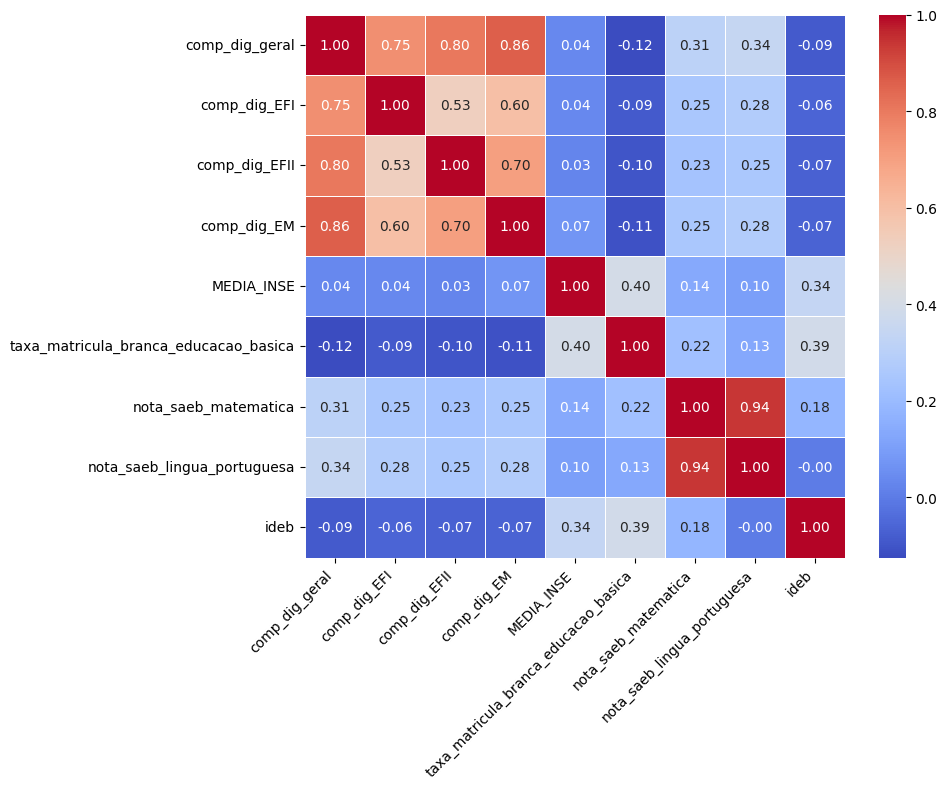

In [111]:
# Variáveis quantitativas de interesse especificadas pelo usuário
correlation_cols_subset = [
    'comp_dig_geral',
    'comp_dig_EFI',
    'comp_dig_EFII',
    'comp_dig_EM',
    'MEDIA_INSE',
    'taxa_matricula_branca_educacao_basica',
    'nota_saeb_matematica',
    'nota_saeb_lingua_portuguesa',
    'ideb'
]

# Filtrar o DataFrame base_final apenas para as colunas de interesse
df_corr_subset = base_final[correlation_cols_subset].copy()

# Converter a coluna 'MEDIA_INSE' para numérica, substituindo vírgulas por pontos, se necessário
# Isso é adicionado para robustez caso a conversão em células anteriores não persista.
df_corr_subset['MEDIA_INSE'] = df_corr_subset['MEDIA_INSE'].astype(str).str.replace(',', '.', regex=False).astype(float)

# Remover linhas com valores nulos nas colunas selecionadas para o cálculo da correlação
df_corr_subset = df_corr_subset.dropna()

# Calcular a matriz de correlação
correlation_matrix_subset = df_corr_subset.corr()

# Gerar o heatmap
plt.figure(figsize=(10, 8)) # Ajuste o tamanho para o número de variáveis
sns.heatmap(correlation_matrix_subset, annot=True, cmap='coolwarm', fmt=".2f", linewidths=.5)
plt.title('', fontsize=14)
plt.xticks(rotation=45, ha='right')
plt.yticks(rotation=0)
plt.tight_layout()
plt.show()

Testando a correlação entre Competência Digital e SAEB

In [112]:
from scipy.stats import pearsonr
import pandas as pd

# Definir as colunas de interesse
vars_saeb = ['nota_saeb_lingua_portuguesa', 'nota_saeb_matematica', 'ideb']
var_ped = 'comp_dig_geral'

# Filtrar a base para os anos de interesse e remover nulos
anos = [2019, 2021, 2023]

print("--- Teste de Correlação de Pearson: SAEB vs Competência Digital (PED) ---\n")

for ano in anos:
    df_ano = base_final[base_final['ano'] == ano].dropna(subset=vars_saeb + [var_ped])

    if len(df_ano) > 1:
        print(f"Ano: {ano} (n={len(df_ano)})")
        for saeb_col in vars_saeb:
            corr, p_value = pearsonr(df_ano[saeb_col], df_ano[var_ped])
            sig = "*Significante*" if p_value < 0.05 else "Não significante"
            print(f"  -> {saeb_col.replace('_', ' ').title()}: r={corr:.4f}, p-valor={p_value:.4f} ({sig})")
        print("-" * 50)
    else:
        print(f"Ano: {ano} - Dados insuficientes para correlação.")

--- Teste de Correlação de Pearson: SAEB vs Competência Digital (PED) ---

Ano: 2019 - Dados insuficientes para correlação.
Ano: 2021 - Dados insuficientes para correlação.
Ano: 2023 (n=4080)
  -> Nota Saeb Lingua Portuguesa: r=0.3433, p-valor=0.0000 (*Significante*)
  -> Nota Saeb Matematica: r=0.3142, p-valor=0.0000 (*Significante*)
  -> Ideb: r=-0.0890, p-valor=0.0000 (*Significante*)
--------------------------------------------------


In [113]:
# Definir as colunas de interesse
vars_saeb = ['nota_saeb_lingua_portuguesa', 'nota_saeb_matematica', 'ideb']
var_ped = 'comp_dig_EFI'

# Filtrar a base para os anos de interesse e remover nulos
anos = [2019, 2021, 2023]

print("--- Teste de Correlação de Pearson: SAEB vs Competência Digital (PED) ---\n")

for ano in anos:
    df_ano = base_final[base_final['ano'] == ano].dropna(subset=vars_saeb + [var_ped])

    if len(df_ano) > 1:
        print(f"Ano: {ano} (n={len(df_ano)})")
        for saeb_col in vars_saeb:
            corr, p_value = pearsonr(df_ano[saeb_col], df_ano[var_ped])
            sig = "*Significante*" if p_value < 0.05 else "Não significante"
            print(f"  -> {saeb_col.replace('_', ' ').title()}: r={corr:.4f}, p-valor={p_value:.4f} ({sig})")
        print("-" * 50)
    else:
        print(f"Ano: {ano} - Dados insuficientes para correlação.")

--- Teste de Correlação de Pearson: SAEB vs Competência Digital (PED) ---

Ano: 2019 - Dados insuficientes para correlação.
Ano: 2021 - Dados insuficientes para correlação.
Ano: 2023 (n=4080)
  -> Nota Saeb Lingua Portuguesa: r=0.2757, p-valor=0.0000 (*Significante*)
  -> Nota Saeb Matematica: r=0.2495, p-valor=0.0000 (*Significante*)
  -> Ideb: r=-0.0591, p-valor=0.0002 (*Significante*)
--------------------------------------------------


In [114]:
# Removendo valores nulos para não dar erro no cálculo
df_clean = base_final[['comp_dig_geral', 'nota_saeb_matematica']].dropna()

# Executando o teste de Pearson
corr, p_valor = pearsonr(df_clean['comp_dig_geral'], df_clean['nota_saeb_matematica'])

print(f"Coeficiente de Correlação de Pearson (r): {corr:.4f}")
print(f"P-valor: {p_valor:.4f}")

# Interpretação automática
if p_valor < 0.05:
    print("Resultado estatisticamente significante (p < 0.05).")
else:
    print("Não há evidências estatísticas de correlação linear (p > 0.05).")

Coeficiente de Correlação de Pearson (r): 0.3142
P-valor: 0.0000
Resultado estatisticamente significante (p < 0.05).


In [115]:
# Removendo valores nulos para não dar erro no cálculo
df_clean = base_final[['comp_dig_geral', 'ideb']].dropna()

# Executando o teste de Pearson
corr, p_valor = pearsonr(df_clean['comp_dig_geral'], df_clean['ideb'])

print(f"Coeficiente de Correlação de Pearson (r): {corr:.4f}")
print(f"P-valor: {p_valor:.4f}")

# Interpretação automática
if p_valor < 0.05:
    print("Resultado estatisticamente significante (p < 0.05).")
else:
    print("Não há evidências estatísticas de correlação linear (p > 0.05).")

Coeficiente de Correlação de Pearson (r): -0.0890
P-valor: 0.0000
Resultado estatisticamente significante (p < 0.05).


Sem dados para o ano 2019.
Sem dados para o ano 2021.


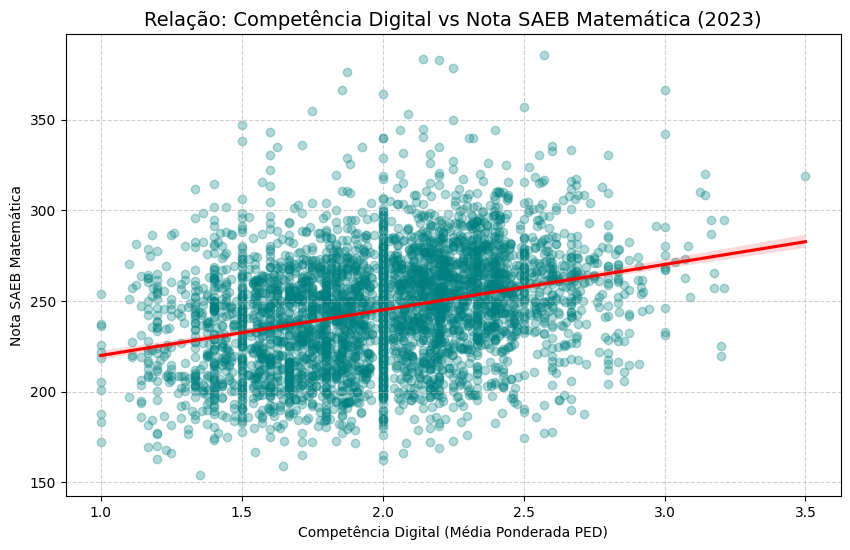

In [116]:
# Definir os anos de interesse
anos = [2019, 2021, 2023]

# Loop para gerar um gráfico por ano
for ano in anos:
    # Filtrar dados para o ano e remover nulos
    df_plot = base_final[base_final['ano'] == ano].dropna(subset=['nota_saeb_matematica', 'comp_dig_geral'])

    if not df_plot.empty:
        plt.figure(figsize=(10, 6))
        sns.regplot(
            data=df_plot,
            x='comp_dig_geral',
            y='nota_saeb_matematica',
            scatter_kws={'alpha':0.3, 'color':'teal'},
            line_kws={'color':'red'}
        )

        plt.title(f'Relação: Competência Digital vs Nota SAEB Matemática ({ano})', fontsize=14)
        plt.xlabel('Competência Digital (Média Ponderada PED)')
        plt.ylabel('Nota SAEB Matemática')
        plt.grid(True, linestyle='--', alpha=0.6)
        plt.show()
    else:
        print(f'Sem dados para o ano {ano}.')

Associação entre laboratório de informática e Competência digital

In [117]:
# --- OPÇÃO 1: Correlação Ponto-Bisserial (Recomendada para precisão) ---
# Mede a relação entre a nota (contínua) e ter ou não laboratório (binária)
# Garanta que a coluna booleana seja tratada como 0 e 1
base_final['lab_bool'] = base_final['laboratorio_informatica'].astype(int)

corr_pb, p_val_pb = pointbiserialr(base_final['lab_bool'], base_final['comp_dig_EFI'])

print("--- Correlação Ponto-Bisserial ---")
print(f"Coeficiente: {corr_pb:.4f}")
print(f"P-valor: {p_val_pb:.4f}")
print("Interpretação: Se positivo, escolas com laboratório tendem a ter maior PED.\n")


# --- OPÇÃO 2: V de Cramer (Requer categorizar a nota) ---
# Criando 4 categorias (quartis) para a proficiência digital
base_final['PED_cat'] = pd.qcut(base_final['comp_dig_EFI'], q=4, labels=['Q1', 'Q2', 'Q3', 'Q4'])

# Tabela de contingência
tabela = pd.crosstab(base_final['laboratorio_informatica'], base_final['PED_cat'])

# Função para calcular V de Cramer
def cramers_v(contingency_table):
    chi2 = chi2_contingency(contingency_table)[0]
    n = contingency_table.sum().sum()
    phi2 = chi2 / n
    r, k = contingency_table.shape
    return np.sqrt(phi2 / min(k - 1, r - 1))

v_cramer_result = cramers_v(tabela)

print("--- V de Cramer (após categorização) ---")
print(f"V de Cramer: {v_cramer_result:.4f}")
print("Escala: 0 (sem associação) a 1 (associação perfeita)")

--- Correlação Ponto-Bisserial ---
Coeficiente: nan
P-valor: nan
Interpretação: Se positivo, escolas com laboratório tendem a ter maior PED.

--- V de Cramer (após categorização) ---
V de Cramer: 0.1420
Escala: 0 (sem associação) a 1 (associação perfeita)


Boxplot das variáveis quantitativas de interesse

Sem dados para o ano 2019.
Sem dados para o ano 2021.


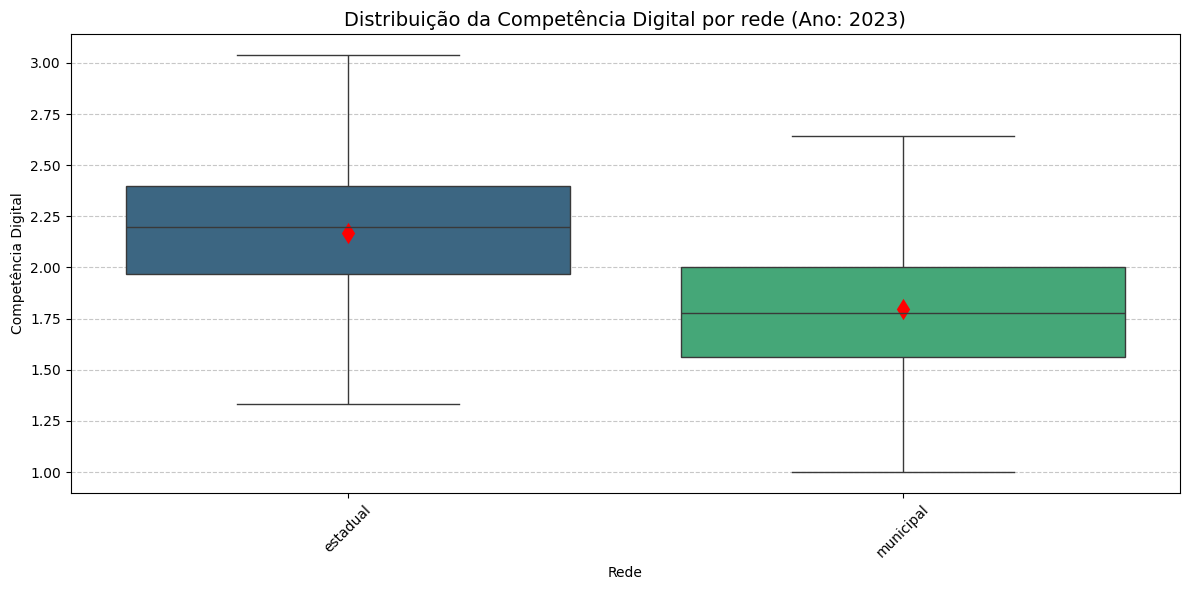

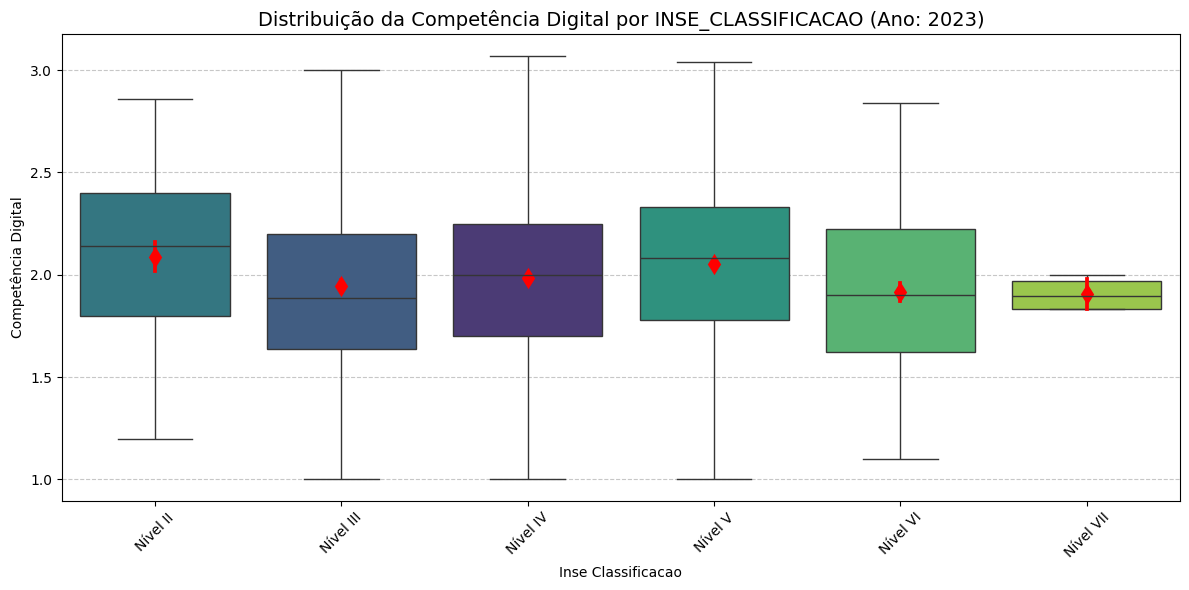

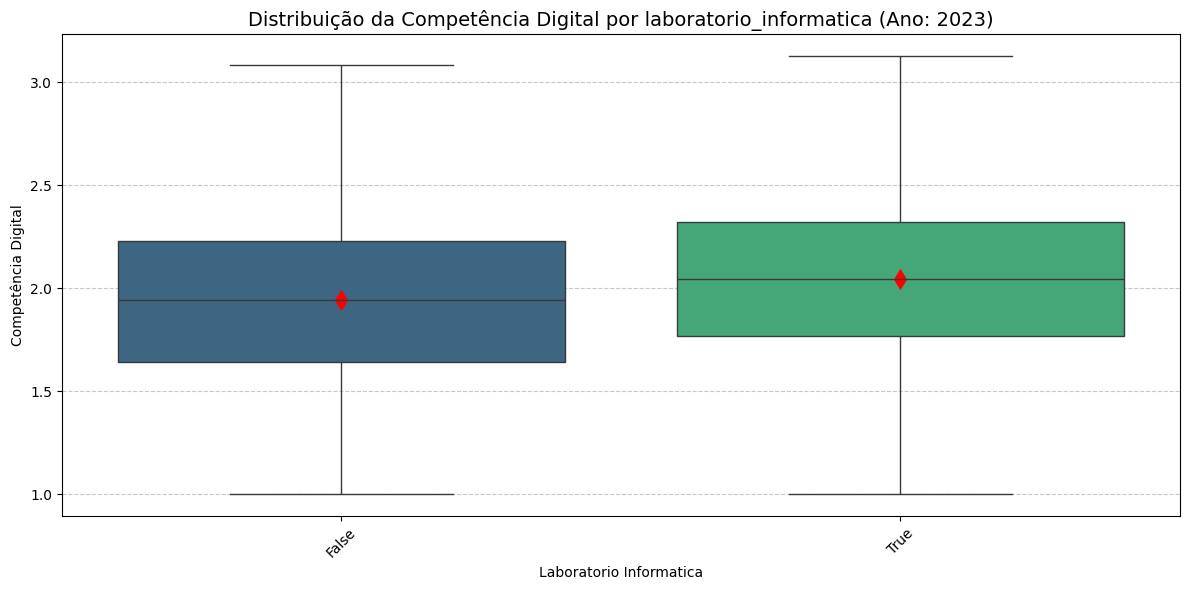

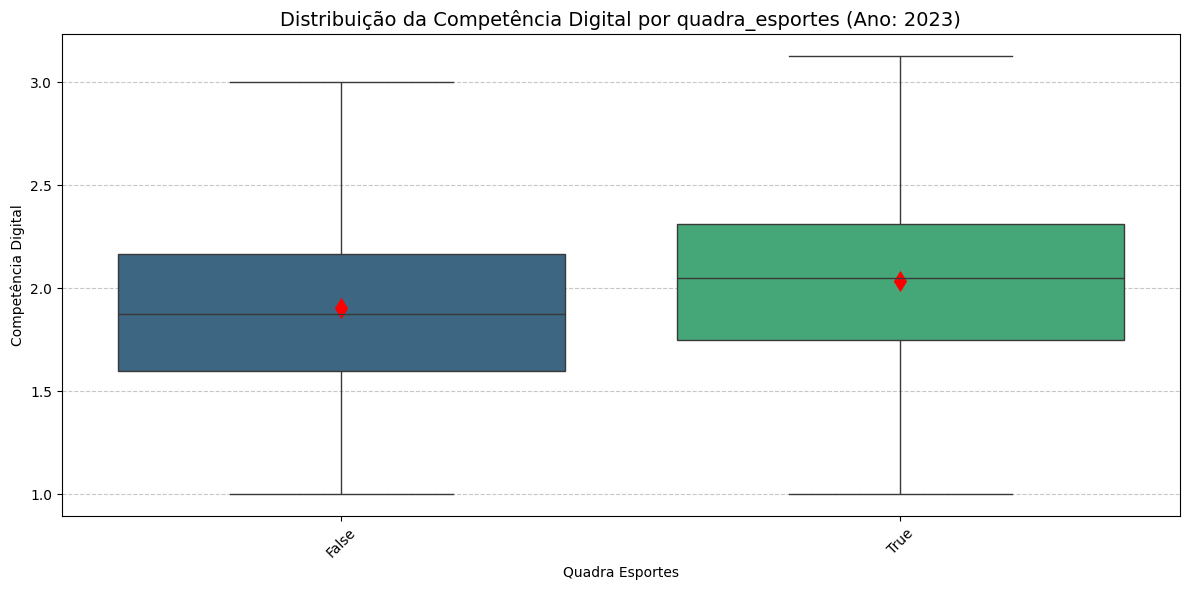

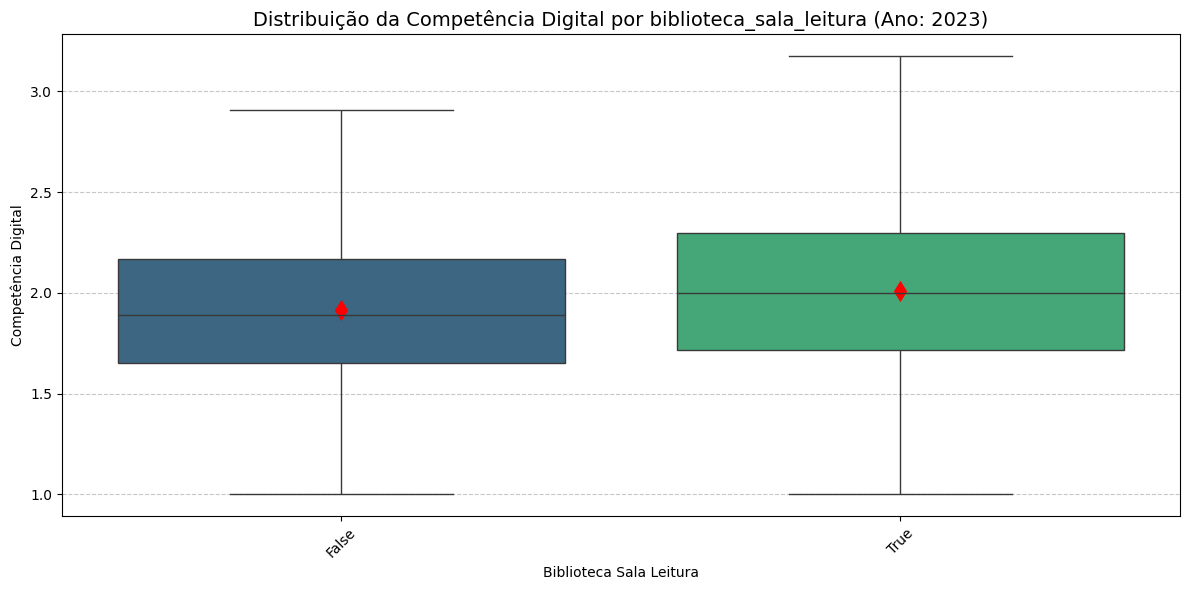

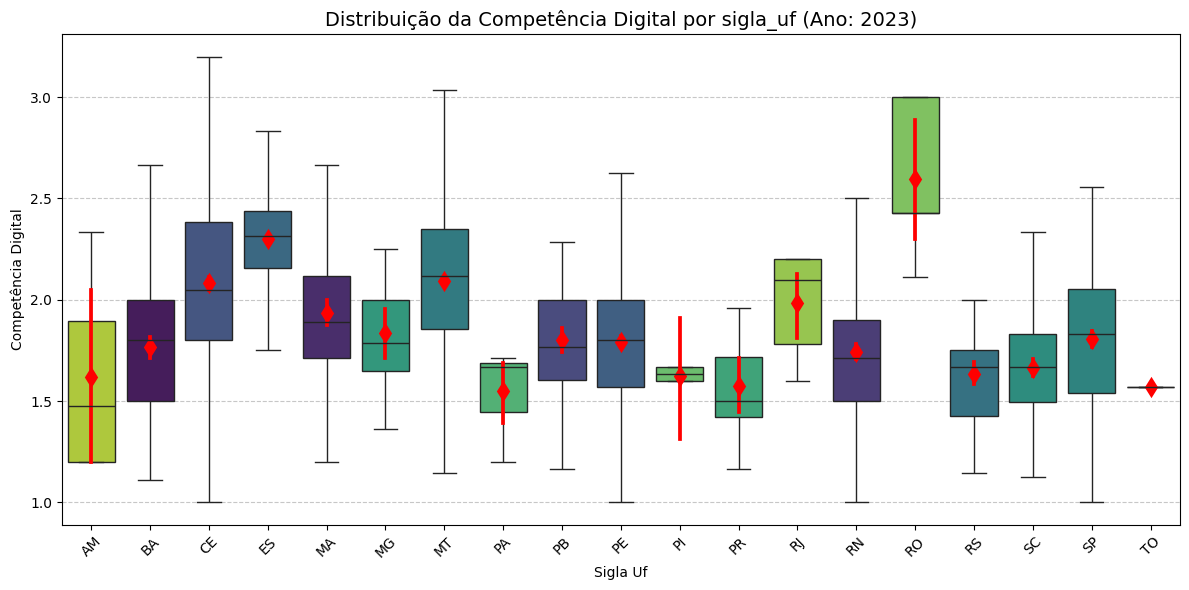

In [118]:
import matplotlib.pyplot as plt
import seaborn as sns

# Definir as variáveis qualitativas de interesse
vars_qualitativas = ['rede', 'INSE_CLASSIFICACAO', 'laboratorio_informatica', 'quadra_esportes', 'biblioteca_sala_leitura', 'sigla_uf']

# Definir os anos de interesse
anos = [2019, 2021, 2023]

# Ordem desejada para o INSE
ordem_inse = ['Nível I', 'Nível II', 'Nível III', 'Nível IV', 'Nível V', 'Nível VI', 'Nível VII', 'Nível VIII']

# Loop para cada ano
for ano in anos:
    # Filtrar a base para o ano específico e garantir que a média ponderada não seja nula
    df_ano = base_final[(base_final['ano'] == ano) & (base_final['comp_dig_geral'].notnull())].copy()

    if df_ano.empty:
        print(f'Sem dados para o ano {ano}.')
        continue

    # Loop para cada variável qualitativa
    for var in vars_qualitativas:
        plt.figure(figsize=(12, 6))

        # Definir ordem específica se for a variável INSE
        current_order = ordem_inse if var == 'INSE_CLASSIFICACAO' else sorted(df_ano[var].dropna().unique())
        plot_order = [o for o in current_order if o in df_ano[var].unique()]

        # Criando o boxplot com parâmetros modernos
        sns.boxplot(
            data=df_ano,
            x=var,
            y='comp_dig_geral',
            order=plot_order,
            palette='viridis',
            hue=var,
            legend=False,
            showfliers=False
        )

        # Adicionando as médias com parâmetros atualizados (sem 'scale' ou 'join')
        sns.pointplot(
            data=df_ano,
            x=var,
            y='comp_dig_geral',
            order=plot_order,
            estimator='mean',
            color='red',
            markers='d',
            linestyles='none', # Substitui join=False
            markersize=8       # Substitui scale
        )

        plt.title(f'Distribuição da Competência Digital por {var} (Ano: {ano})', fontsize=14)
        plt.ylabel('Competência Digital')
        plt.xlabel(var.replace("_", " ").title())
        plt.xticks(rotation=45)
        plt.grid(axis='y', linestyle='--', alpha=0.7)
        plt.tight_layout()
        plt.show()

Não há dados válidos para o ano 2019 após a limpeza. Pulando box plot.
Não há dados válidos para o ano 2021 após a limpeza. Pulando box plot.


/tmp/ipykernel_666/1644116219.py:27: UserWarning: 

The `scale` parameter is deprecated and will be removed in v0.15.0. You can now control the size of each plot element using matplotlib `Line2D` parameters (e.g., `linewidth`, `markersize`, etc.).

  sns.pointplot(
/tmp/ipykernel_666/1644116219.py:27: UserWarning: 

The `join` parameter is deprecated and will be removed in v0.15.0. You can remove the line between points with `linestyle='none'`.

  sns.pointplot(


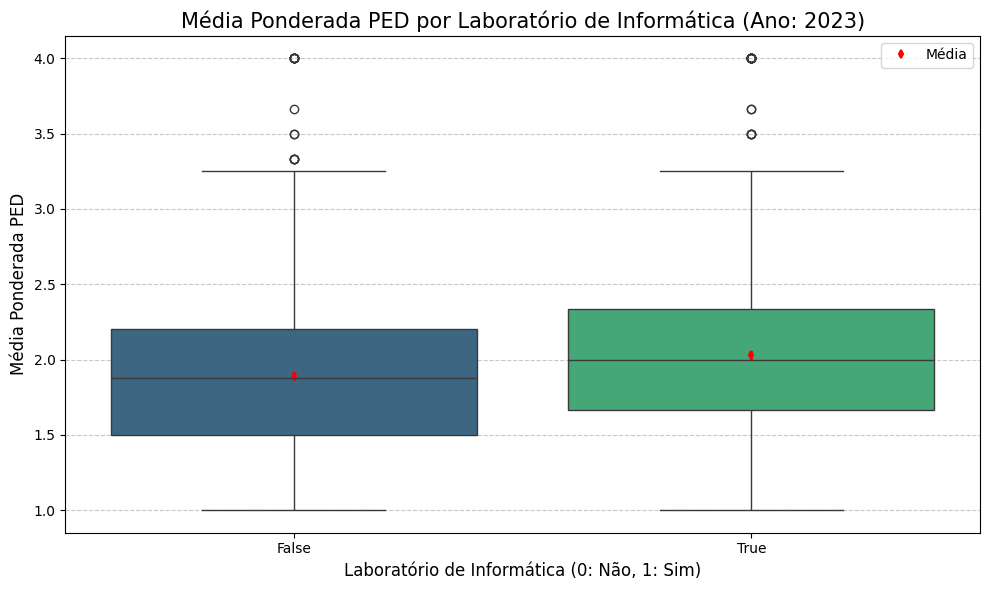

In [119]:
# Definir os anos de interesse
years_to_plot = [2019, 2021, 2023]

# Loop sobre cada ano
for year in years_to_plot:
    # Filtrar o DataFrame para o ano atual e remover nulos nas colunas relevantes
    df_year_clean = base_final[
        base_final['ano'] == year
    ].dropna(subset=['comp_dig_EFI', 'laboratorio_informatica']).copy()

    # Verificar se há dados suficientes após a limpeza
    if df_year_clean.empty:
        print(f"Não há dados válidos para o ano {year} após a limpeza. Pulando box plot.")
        continue

    plt.figure(figsize=(10, 6))
    sns.boxplot(
        data=df_year_clean,
        x='laboratorio_informatica',
        y='comp_dig_EFI',
        palette='viridis',
        hue='laboratorio_informatica', # Usar a variável para o hue para manter a coloração
        legend=False # Ocultar a legenda, pois o x-axis já informa a categoria
    )

    # Opcional: Adicionar a média como um ponto para comparação com a mediana
    sns.pointplot(
        data=df_year_clean,
        x='laboratorio_informatica',
        y='comp_dig_EFI',
        estimator='mean',
        color='red',
        markers='d',
        scale=0.75,
        join=False,
        label='Média'
    )

    plt.title(f'Média Ponderada PED por Laboratório de Informática (Ano: {year})', fontsize=15)
    plt.xlabel('Laboratório de Informática (0: Não, 1: Sim)', fontsize=12)
    plt.ylabel('Média Ponderada PED', fontsize=12)
    plt.xticks(rotation=0)
    plt.grid(axis='y', linestyle='--', alpha=0.7)
    plt.tight_layout()
    plt.show()

Teste de diferença de médias com variáveis quantitativas

In [120]:
# Definir as variáveis categóricas de interesse
vars_categoricas = [
    'rede',
    'INSE_CLASSIFICACAO',
    'laboratorio_informatica',
    'quadra_esportes',
    'biblioteca_sala_leitura',
    'sigla_uf'
]

# Filtrar o DataFrame para o ano de 2023
df_filtered = base_final.copy()

print("--- Testes de Diferença de Média para comp_dig_geral (Ano 2023) ---")

for var in vars_categoricas:
    print(f"\nVariável Categórica: {var}")
    # Remover nulos da variável categórica e da variável dependente
    df_temp = df_filtered.dropna(subset=['comp_dig_geral', var]).copy()

    if df_temp.empty:
        print(f"  Sem dados suficientes após a remoção de nulos para {var}.")
        continue

    # Obter categorias únicas
    categorias_unicas = df_temp[var].unique()
    n_categorias = len(categorias_unicas)

    # Se houver apenas uma categoria, não é possível fazer o teste de diferença
    if n_categorias <= 1:
        print(f"  Apenas uma categoria encontrada para {var}. Não é possível realizar o teste de diferença.")
        continue

    # Teste para variáveis binárias (t-test)
    if n_categorias == 2:
        cat1 = categorias_unicas[0]
        cat2 = categorias_unicas[1]
        grupo1 = df_temp[df_temp[var] == cat1]['comp_dig_geral']
        grupo2 = df_temp[df_temp[var] == cat2]['comp_dig_geral']

        # Verifica se ambos os grupos têm dados
        if len(grupo1) > 1 and len(grupo2) > 1:
            t_stat, p_val = ttest_ind(grupo1, grupo2, equal_var=False) # Welch's t-test, não assume igualdade de variâncias
            print(f"  Média {cat1}: {grupo1.mean():.2f} (n={len(grupo1)})\n  Média {cat2}: {grupo2.mean():.2f} (n={len(grupo2)})")
            print(f"  Teste t de Student (Welch): t={t_stat:.3f}, p-valor={p_val:.3f}")
            if p_val < 0.05:
                print("  Há uma diferença de média estatisticamente significante (p < 0.05).")
            else:
                print("  Não há diferença de média estatisticamente significante (p >= 0.05).")
        else:
            print(f"  Dados insuficientes em um ou ambos os grupos para {var} para realizar o teste t.")

    # Teste para variáveis com mais de duas categorias (ANOVA)
    else:
        # Criar uma lista de arrays para cada grupo/categoria
        grupos = [df_temp[df_temp[var] == cat]['comp_dig_geral'].values for cat in categorias_unicas]

        # Remover grupos vazios que podem surgir se alguma categoria não tiver dados após o dropna
        grupos_validos = [g for g in grupos if len(g) > 1] # ANOVA exige pelo menos 2 observações por grupo

        if len(grupos_validos) < n_categorias: # Se removemos grupos, o número de grupos válidos é menor
            print(f"  Aviso: Algumas categorias de {var} tinham dados insuficientes e foram excluídas do teste ANOVA.")

        if len(grupos_validos) >= 2: # ANOVA precisa de pelo menos dois grupos válidos
            f_stat, p_val = f_oneway(*grupos_validos)
            print("  Médias por Categoria:")
            for cat in categorias_unicas:
                mean_val = df_temp[df_temp[var] == cat]['comp_dig_geral'].mean()
                count_val = len(df_temp[df_temp[var] == cat]['comp_dig_geral'])
                print(f"    {cat}: {mean_val:.2f} (n={count_val})")
            print(f"  ANOVA One-Way: F={f_stat:.3f}, p-valor={p_val:.3f}")
            if p_val < 0.05:
                print("  Há uma diferença de média estatisticamente significante (p < 0.05).")
            else:
                print("  Não há diferença de média estatisticamente significante (p >= 0.05).")
        else:
            print(f"  Dados insuficientes para realizar o teste ANOVA para {var} (menos de 2 grupos válidos).")


--- Testes de Diferença de Média para comp_dig_geral (Ano 2023) ---

Variável Categórica: rede
  Média estadual: 2.17 (n=2166)
  Média municipal: 1.80 (n=1914)
  Teste t de Student (Welch): t=34.406, p-valor=0.000
  Há uma diferença de média estatisticamente significante (p < 0.05).

Variável Categórica: INSE_CLASSIFICACAO
  Médias por Categoria:
    Nível IV: 1.98 (n=1578)
    Nível III: 1.94 (n=846)
    Nível II: 2.09 (n=121)
    Nível V: 2.05 (n=1273)
    Nível VI: 1.92 (n=255)
    Nível VII: 1.91 (n=4)
  ANOVA One-Way: F=12.098, p-valor=0.000
  Há uma diferença de média estatisticamente significante (p < 0.05).

Variável Categórica: laboratorio_informatica
  Média False: 1.94 (n=1934)
  Média True: 2.04 (n=2146)
  Teste t de Student (Welch): t=-8.425, p-valor=0.000
  Há uma diferença de média estatisticamente significante (p < 0.05).

Variável Categórica: quadra_esportes
  Média True: 2.03 (n=2897)
  Média False: 1.90 (n=1183)
  Teste t de Student (Welch): t=9.917, p-valor=0.000
  

In [121]:
base_final = base_final.dropna(subset=['comp_dig_geral'])
print("Observações com 'comp_dig_geral' nula removidas com sucesso!")
print(f"Novo número de linhas em base_final: {base_final.shape[0]}")

Observações com 'comp_dig_geral' nula removidas com sucesso!
Novo número de linhas em base_final: 4080


In [122]:
base_final = base_final[base_final['rede'] != 'federal'].copy()
print("Observações com 'rede' == 'federal' removidas com sucesso!")
print(f"Novo número de linhas em base_final: {base_final.shape[0]}")
print("Novas contagens para a variável 'rede':")
print(base_final['rede'].value_counts())

Observações com 'rede' == 'federal' removidas com sucesso!
Novo número de linhas em base_final: 4080
Novas contagens para a variável 'rede':
rede
estadual     2166
municipal    1914
Name: count, dtype: int64


# Padronização das variáveis

In [123]:
from sklearn.preprocessing import StandardScaler

# Identificar colunas numéricas relevantes para padronização
# Incluo as que foram usadas em OLS e HLM, além de outras quantitativas
quantitative_cols_for_standardization = [
    'ideb', 'nota_saeb_lingua_portuguesa', 'nota_saeb_matematica',
    'comp_dig_geral', 'comp_dig_EFI', 'comp_dig_EFII', 'comp_dig_EM',
    'MEDIA_INSE', 'taxa_matricula_branca_educacao_basica',
    'quantidade_docente_educacao_basica', 'quantidade_docente_fundamental_anos_iniciais',
    'quantidade_docente_fundamental_anos_finais', 'quantidade_docente_medio',
    'quantidade_matricula_educacao_basica', 'quantidade_matricula_branca',
    'quantidade_matricula_parda', 'quantidade_matricula_preta'
]

# Criar uma cópia da base_final para aplicar a padronização
base_final_padronizada = base_final.copy()

# Fix: Ensure 'MEDIA_INSE' is float with '.' as decimal separator before processing
# Convertendo explicitamente para string antes de usar .str.replace() para evitar erros
base_final_padronizada['MEDIA_INSE'] = base_final_padronizada['MEDIA_INSE'].astype(str).str.replace(',', '.', regex=False).astype(float)


# Antes de padronizar, certificar-se de que as colunas são numéricas e não possuem NaNs
# A padronização não lida com NaNs, então removeremos as linhas com NaNs nestas colunas
# para evitar erros e garantir a validade da padronização.
# Para não perder muitas observações, faremos um dropna apenas nas colunas que serão padronizadas.
base_final_padronizada = base_final_padronizada.dropna(subset=quantitative_cols_for_standardization)

# Inicializar o StandardScaler
scaler = StandardScaler()

# Aplicar a padronização às colunas selecionadas
base_final_padronizada[quantitative_cols_for_standardization] = scaler.fit_transform(
    base_final_padronizada[quantitative_cols_for_standardization]
)

print("DataFrame `base_final_padronizada` criado com variáveis quantitativas padronizadas.")
print("Primeiras linhas do DataFrame padronizado:")
display(base_final_padronizada.head())
print("Estatísticas descritivas para algumas variáveis padronizadas:")
display(base_final_padronizada[['comp_dig_geral', 'nota_saeb_matematica', 'MEDIA_INSE']].describe())

DataFrame `base_final_padronizada` criado com variáveis quantitativas padronizadas.
Primeiras linhas do DataFrame padronizado:


,ano,anos_escolares,ensino,id_escola,id_municipio,ideb,nota_saeb_lingua_portuguesa,nota_saeb_matematica,rede,sigla_uf,...,quantidade_matricula_branca,quantidade_matricula_parda,quantidade_matricula_preta,quadra_esportes,biblioteca_sala_leitura,MEDIA_INSE,INSE_CLASSIFICACAO,taxa_matricula_branca_educacao_basica,lab_bool,PED_cat
607,2023,EM,medio,29190908,2927408,-2.11402,-0.081248,-0.109108,estadual,BA,...,-0.769777,0.299293,4.289646,True,False,-0.648544,Nível IV,-1.009305,0,Q2
628,2023,EFI,fundamental,29296218,2905602,-2.11402,-2.522243,-2.249084,municipal,BA,...,-0.713436,-0.394304,-0.062478,True,False,-0.922881,Nível III,-0.611352,0,Q1
645,2023,EM,medio,29397758,2922250,-2.11402,-0.303583,-0.362657,estadual,BA,...,-0.797947,-0.473439,-0.166929,True,True,-1.700171,Nível III,-0.958446,0,Q2
1077,2023,EM,medio,21076839,2108108,-1.63324,0.347603,0.178332,estadual,MA,...,-0.044384,1.733036,0.947215,True,True,-1.631587,Nível III,-0.412847,0,Q3
1089,2023,EM,medio,21095523,2105302,-1.63324,0.286088,-0.012229,estadual,MA,...,-0.297919,-0.049833,-0.480281,False,True,-0.328483,Nível IV,0.134044,0,Q2


Estatísticas descritivas para algumas variáveis padronizadas:


,comp_dig_geral,nota_saeb_matematica,MEDIA_INSE
count,4.077000e+03,4.077000e+03,4.077000e+03
mean,-1.080541e-16,-1.185109e-16,-4.653297e-16
std,1.000123e+00,1.000123e+00,1.000123e+00
min,-2.543667e+00,-2.910932e+00,-3.094721e+00
25%,-7.183632e-01,-7.220369e-01,-7.171279e-01
50%,1.175832e-02,3.764973e-02,6.016206e-02
75%,7.215986e-01,6.461025e-01,6.774218e-01
max,3.844896e+00,4.496972e+00,2.986430e+00


In [124]:
base_final_padronizada.head(10)

,ano,anos_escolares,ensino,id_escola,id_municipio,ideb,nota_saeb_lingua_portuguesa,nota_saeb_matematica,rede,sigla_uf,...,quantidade_matricula_branca,quantidade_matricula_parda,quantidade_matricula_preta,quadra_esportes,biblioteca_sala_leitura,MEDIA_INSE,INSE_CLASSIFICACAO,taxa_matricula_branca_educacao_basica,lab_bool,PED_cat
607,2023,EM,medio,29190908,2927408,-2.11402,-0.081248,-0.109108,estadual,BA,...,-0.769777,0.299293,4.289646,True,False,-0.648544,Nível IV,-1.009305,0,Q2
628,2023,EFI,fundamental,29296218,2905602,-2.11402,-2.522243,-2.249084,municipal,BA,...,-0.713436,-0.394304,-0.062478,True,False,-0.922881,Nível III,-0.611352,0,Q1
645,2023,EM,medio,29397758,2922250,-2.11402,-0.303583,-0.362657,estadual,BA,...,-0.797947,-0.473439,-0.166929,True,True,-1.700171,Nível III,-0.958446,0,Q2
1077,2023,EM,medio,21076839,2108108,-1.63324,0.347603,0.178332,estadual,MA,...,-0.044384,1.733036,0.947215,True,True,-1.631587,Nível III,-0.412847,0,Q3
1089,2023,EM,medio,21095523,2105302,-1.63324,0.286088,-0.012229,estadual,MA,...,-0.297919,-0.049833,-0.480281,False,True,-0.328483,Nível IV,0.134044,0,Q2
1097,2023,EM,medio,21111561,2111409,-1.63324,0.061995,0.033493,estadual,MA,...,0.019000,1.346671,0.773130,False,True,-1.585864,Nível III,-0.317068,1,Q2
1155,2023,EM,medio,21199365,2109007,-1.63324,0.455109,0.303668,estadual,MA,...,0.166895,1.719071,-0.062478,True,True,-0.808574,Nível III,-0.323767,0,Q1
1179,2023,EM,medio,21259968,2100055,-1.63324,-0.112006,0.231088,estadual,MA,...,-0.727521,-0.398959,-0.584732,False,False,-0.900020,Nível III,-0.684366,0,Q1
1316,2023,EFII,fundamental,24053830,2408201,-1.63324,-0.144521,-0.015426,estadual,RN,...,-0.241578,-0.589814,-0.027661,False,False,-0.214176,Nível IV,0.413178,0,Q2
1354,2023,EFII,fundamental,25074091,2504009,-1.63324,0.175946,-0.484155,municipal,PB,...,0.089426,2.273018,0.355326,True,True,-0.465652,Nível IV,-0.352039,0,Q2


Calculando a média e desvio padrão

In [125]:
print(base_final_padronizada['comp_dig_geral'].mean()) # Deve ser algo muito próximo de 0
print(base_final_padronizada['comp_dig_geral'].std())  # Deve ser exatamente 1

-1.0805408294610304e-16
1.0001226617606531


Dummização das variáveis categóricas

In [126]:
import pandas as pd

# Identificar as colunas categóricas para dummificação
# Baseado nos dtypes do base_final e transformações anteriores
# 'anos_escolares', 'ensino', 'rede', 'sigla_uf', 'INSE_CLASSIFICACAO', 'num_educadores_faixa', 'PED_cat'
categorical_cols = [
    'anos_escolares',
    'ensino',
    'rede',
    'sigla_uf',
    'INSE_CLASSIFICACAO',
    'num_educadores_faixa',
    'PED_cat'
]

# Criar cópia para evitar SettingWithCopyWarning
base_final_padronizada_dummies = base_final_padronizada.copy()

# Dummificar as variáveis categóricas, usando drop_first=True para evitar multicolinearidade
base_final_padronizada_dummies = pd.get_dummies(
    base_final_padronizada_dummies,
    columns=categorical_cols,
    drop_first=True
)

# Converter colunas booleanas criadas pelo get_dummies para int (0 ou 1)
for col in base_final_padronizada_dummies.columns:
    if base_final_padronizada_dummies[col].dtype == 'bool':
        base_final_padronizada_dummies[col] = base_final_padronizada_dummies[col].astype(int)

# Opcional: Renomear colunas para remover caracteres especiais, se houver, para modelos como statsmodels
base_final_padronizada_dummies.columns = base_final_padronizada_dummies.columns.str.replace(' ', '_').str.replace('[^A-Za-z0-9_]+', '', regex=True)

print("DataFrame `base_final_padronizada_dummies` criado com variáveis categóricas dummificadas.")
print("Primeiras linhas do DataFrame com dummies:")
display(base_final_padronizada_dummies.head())
print("Novo shape do DataFrame:", base_final_padronizada_dummies.shape)
print("Novas colunas:", base_final_padronizada_dummies.columns.tolist())


DataFrame `base_final_padronizada_dummies` criado com variáveis categóricas dummificadas.
Primeiras linhas do DataFrame com dummies:


,ano,id_escola,id_municipio,ideb,nota_saeb_lingua_portuguesa,nota_saeb_matematica,comp_dig_geral,comp_dig_EFI,comp_dig_EFII,comp_dig_EM,...,INSE_CLASSIFICACAO_Nvel_V,INSE_CLASSIFICACAO_Nvel_VI,INSE_CLASSIFICACAO_Nvel_VII,num_educadores_faixa_510,num_educadores_faixa_1015,num_educadores_faixa_1520,num_educadores_faixa_20,PED_cat_Q2,PED_cat_Q3,PED_cat_Q4
607,2023,29190908,2927408,-2.11402,-0.081248,-0.109108,-0.414146,-0.262330,1.313700,-0.424709,...,0,0,0,1,0,0,0,1,0,0
628,2023,29296218,2905602,-2.11402,-2.522243,-2.249084,-1.521497,-0.927556,-1.078829,-1.340178,...,0,0,0,0,1,0,0,0,0,0
645,2023,29397758,2922250,-2.11402,-0.303583,-0.362657,0.011758,0.070284,-0.053460,-0.072605,...,0,0,0,1,0,0,0,1,0,0
1077,2023,21076839,2108108,-1.63324,0.347603,0.178332,0.244070,0.251709,0.132971,0.119451,...,0,0,0,0,1,0,0,0,1,0
1089,2023,21095523,2105302,-1.63324,0.286088,-0.012229,0.011758,0.070284,-0.053460,-0.072605,...,0,0,0,1,0,0,0,1,0,0


Novo shape do DataFrame: (4077, 60)
Novas colunas: ['ano', 'id_escola', 'id_municipio', 'ideb', 'nota_saeb_lingua_portuguesa', 'nota_saeb_matematica', 'comp_dig_geral', 'comp_dig_EFI', 'comp_dig_EFII', 'comp_dig_EM', 'num_educadores_unicos', 'num_educadores', 'laboratorio_informatica', 'quantidade_docente_educacao_basica', 'quantidade_docente_fundamental_anos_iniciais', 'quantidade_docente_fundamental_anos_finais', 'quantidade_docente_medio', 'quantidade_matricula_educacao_basica', 'quantidade_matricula_branca', 'quantidade_matricula_parda', 'quantidade_matricula_preta', 'quadra_esportes', 'biblioteca_sala_leitura', 'MEDIA_INSE', 'taxa_matricula_branca_educacao_basica', 'lab_bool', 'anos_escolares_EFII', 'anos_escolares_EM', 'ensino_medio', 'rede_municipal', 'sigla_uf_BA', 'sigla_uf_CE', 'sigla_uf_ES', 'sigla_uf_MA', 'sigla_uf_MG', 'sigla_uf_MT', 'sigla_uf_PA', 'sigla_uf_PB', 'sigla_uf_PE', 'sigla_uf_PI', 'sigla_uf_PR', 'sigla_uf_RJ', 'sigla_uf_RN', 'sigla_uf_RO', 'sigla_uf_RS', 'sigla

# Modelagem com SAEB

Modelo linear

In [127]:
import statsmodels.formula.api as smf

# Filtrar nulos nas colunas de interesse para o modelo OLS
df1_ols_saeb = base_final_padronizada[['nota_saeb_matematica', 'comp_dig_geral']].dropna()

# Definir a fórmula do modelo
formula1 = 'nota_saeb_matematica ~ comp_dig_geral'

# Rodar o modelo OLS
modelo_ols1 = smf.ols(formula=formula1, data=df1_ols_saeb).fit()

# Exibir o sumário do modelo
print(modelo_ols1.summary())

                             OLS Regression Results                             
Dep. Variable:     nota_saeb_matematica   R-squared:                       0.099
Model:                              OLS   Adj. R-squared:                  0.098
Method:                   Least Squares   F-statistic:                     445.6
Date:                  Tue, 02 Jun 2026   Prob (F-statistic):           6.01e-94
Time:                          00:36:43   Log-Likelihood:                -5573.5
No. Observations:                  4077   AIC:                         1.115e+04
Df Residuals:                      4075   BIC:                         1.116e+04
Df Model:                             1                                         
Covariance Type:              nonrobust                                         
                     coef    std err          t      P>|t|      [0.025      0.975]
----------------------------------------------------------------------------------
Intercept      -1.158e-1

Modelo 2

In [128]:
import statsmodels.formula.api as smf

# Filtrar nulos nas colunas de interesse para o modelo OLS
df2_ols_saeb = base_final_padronizada[['nota_saeb_matematica', 'comp_dig_geral', 'MEDIA_INSE']].dropna()

# Definir a fórmula do modelo
formula2 = 'nota_saeb_matematica ~ comp_dig_geral + MEDIA_INSE'

# Rodar o modelo OLS
modelo_ols2 = smf.ols(formula=formula2, data=df2_ols_saeb).fit()

# Exibir o sumário do modelo
print(modelo_ols2.summary())

                             OLS Regression Results                             
Dep. Variable:     nota_saeb_matematica   R-squared:                       0.114
Model:                              OLS   Adj. R-squared:                  0.113
Method:                   Least Squares   F-statistic:                     261.9
Date:                  Tue, 02 Jun 2026   Prob (F-statistic):          1.04e-107
Time:                          00:36:43   Log-Likelihood:                -5538.5
No. Observations:                  4077   AIC:                         1.108e+04
Df Residuals:                      4074   BIC:                         1.110e+04
Df Model:                             2                                         
Covariance Type:              nonrobust                                         
                     coef    std err          t      P>|t|      [0.025      0.975]
----------------------------------------------------------------------------------
Intercept      -1.158e-1

Modelo 3

In [129]:
import statsmodels.formula.api as smf

# Filtrar nulos nas colunas de interesse para o modelo OLS
df3_ols_saeb = base_final_padronizada_dummies[['nota_saeb_matematica', 'comp_dig_geral', 'MEDIA_INSE']].dropna()

# Get all dummy columns related to 'sigla_uf'
sigla_uf_cols = [col for col in base_final_padronizada_dummies.columns if col.startswith('sigla_uf_')]

# Definir a fórmula do modelo com a nova variável
formula3 = 'nota_saeb_matematica ~ comp_dig_geral + MEDIA_INSE + ' + ' + '.join(sigla_uf_cols)

# Rodar o modelo OLS
modelo_ols3 = smf.ols(formula=formula3, data=base_final_padronizada_dummies).fit()

# Exibir o sumário do modelo
print(modelo_ols3.summary())

                             OLS Regression Results                             
Dep. Variable:     nota_saeb_matematica   R-squared:                       0.309
Model:                              OLS   Adj. R-squared:                  0.305
Method:                   Least Squares   F-statistic:                     90.51
Date:                  Tue, 02 Jun 2026   Prob (F-statistic):          4.04e-306
Time:                          00:36:43   Log-Likelihood:                -5032.8
No. Observations:                  4077   AIC:                         1.011e+04
Df Residuals:                      4056   BIC:                         1.024e+04
Df Model:                            20                                         
Covariance Type:              nonrobust                                         
                     coef    std err          t      P>|t|      [0.025      0.975]
----------------------------------------------------------------------------------
Intercept         -0.272

In [130]:
# Supondo que 'sigla_uf' era a sua coluna original de estados antes da dummização
categorias_originais = sorted(base_final_padronizada['sigla_uf'].unique())

# Get all dummy columns related to 'sigla_uf' used in the model
sigla_uf_cols = [col for col in base_final_padronizada_dummies.columns if col.startswith('sigla_uf_')]

# Definir as colunas que entraram no modelo OLS
# X deve conter todas as variáveis independentes usadas no modelo em pnsRi36ClYHF
X = base_final_padronizada_dummies[['comp_dig_geral', 'MEDIA_INSE'] + sigla_uf_cols]

# Lista de colunas que entraram no seu modelo (X)
colunas_modelo = X.columns.tolist()

# Identificando a que sumiu (a categoria de referência)
# Precisamos extrair o nome da UF de cada coluna dummy e comparar com as originais
dummies_presentes = [col.replace('sigla_uf_', '') for col in colunas_modelo if col.startswith('sigla_uf_')]
referencia = [estado for estado in categorias_originais if estado not in dummies_presentes]

print(f"A categoria de referência omitida foi: {referencia}")

A categoria de referência omitida foi: ['AM']


Modelo 4

In [131]:
import statsmodels.formula.api as smf

# Get all dummy columns related to 'sigla_uf'
sigla_uf_cols = [col for col in base_final_padronizada_dummies.columns if col.startswith('sigla_uf_')]

# Definir a fórmula do modelo com a nova variável 'taxa_matricula_branca_educacao_basica'
formula4 = 'nota_saeb_matematica ~ comp_dig_geral + MEDIA_INSE + taxa_matricula_branca_educacao_basica + ' + ' + '.join(sigla_uf_cols)

# Rodar o modelo OLS com a nova variável
modelo_ols4 = smf.ols(formula=formula4, data=base_final_padronizada_dummies).fit()

# Exibir o sumário do modelo
print(modelo_ols4.summary())

                             OLS Regression Results                             
Dep. Variable:     nota_saeb_matematica   R-squared:                       0.318
Model:                              OLS   Adj. R-squared:                  0.314
Method:                   Least Squares   F-statistic:                     89.98
Date:                  Tue, 02 Jun 2026   Prob (F-statistic):          6.44e-317
Time:                          00:36:44   Log-Likelihood:                -5005.2
No. Observations:                  4077   AIC:                         1.005e+04
Df Residuals:                      4055   BIC:                         1.019e+04
Df Model:                            21                                         
Covariance Type:              nonrobust                                         
                                            coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------------

In [132]:
base_final_padronizada_dummies.columns

Index(['ano', 'id_escola', 'id_municipio', 'ideb',
       'nota_saeb_lingua_portuguesa', 'nota_saeb_matematica', 'comp_dig_geral',
       'comp_dig_EFI', 'comp_dig_EFII', 'comp_dig_EM', 'num_educadores_unicos',
       'num_educadores', 'laboratorio_informatica',
       'quantidade_docente_educacao_basica',
       'quantidade_docente_fundamental_anos_iniciais',
       'quantidade_docente_fundamental_anos_finais',
       'quantidade_docente_medio', 'quantidade_matricula_educacao_basica',
       'quantidade_matricula_branca', 'quantidade_matricula_parda',
       'quantidade_matricula_preta', 'quadra_esportes',
       'biblioteca_sala_leitura', 'MEDIA_INSE',
       'taxa_matricula_branca_educacao_basica', 'lab_bool',
       'anos_escolares_EFII', 'anos_escolares_EM', 'ensino_medio',
       'rede_municipal', 'sigla_uf_BA', 'sigla_uf_CE', 'sigla_uf_ES',
       'sigla_uf_MA', 'sigla_uf_MG', 'sigla_uf_MT', 'sigla_uf_PA',
       'sigla_uf_PB', 'sigla_uf_PE', 'sigla_uf_PI', 'sigla_uf_PR',
      

Modelo 5: Acrescentando variáveis de etapa de ensino e rede

In [133]:
import statsmodels.formula.api as smf

# Get all dummy columns related to 'sigla_uf', 'rede', 'anos_escolares', and 'ensino'
sigla_uf_cols = [col for col in base_final_padronizada_dummies.columns if col.startswith('sigla_uf_')]
rede_cols = [col for col in base_final_padronizada_dummies.columns if col.startswith('rede_')]
anos_escolares_cols = [col for col in base_final_padronizada_dummies.columns if col.startswith('anos_escolares_')]


# Combine all categorical dummy variables
all_categorical_dummies = sigla_uf_cols + rede_cols + anos_escolares_cols

# Definir a fórmula do modelo com todas as novas variáveis
formula5 = 'nota_saeb_matematica ~ comp_dig_geral + MEDIA_INSE + taxa_matricula_branca_educacao_basica + ' + ' + '.join(all_categorical_dummies)

# Rodar o modelo OLS com as novas variáveis
modelo_ols5 = smf.ols(formula=formula5, data=base_final_padronizada_dummies).fit()

# Exibir o sumário do modelo
print(modelo_ols5.summary())

                             OLS Regression Results                             
Dep. Variable:     nota_saeb_matematica   R-squared:                       0.667
Model:                              OLS   Adj. R-squared:                  0.665
Method:                   Least Squares   F-statistic:                     338.7
Date:                  Tue, 02 Jun 2026   Prob (F-statistic):               0.00
Time:                          00:36:44   Log-Likelihood:                -3541.2
No. Observations:                  4077   AIC:                             7132.
Df Residuals:                      4052   BIC:                             7290.
Df Model:                            24                                         
Covariance Type:              nonrobust                                         
                                            coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------------

Modelo 6: Acrescentando dados de infra escolar



In [134]:
import statsmodels.formula.api as smf

# Get all dummy columns related to 'sigla_uf', 'rede', 'anos_escolares', and 'ensino'
sigla_uf_cols = [col for col in base_final_padronizada_dummies.columns if col.startswith('sigla_uf_')]
rede_cols = [col for col in base_final_padronizada_dummies.columns if col.startswith('rede_')]
anos_escolares_cols = [col for col in base_final_padronizada_dummies.columns if col.startswith('anos_escolares_')]


# Get the infrastructure variables (already boolean/int in base_final_padronizada_dummies)
infras_cols = ['laboratorio_informatica', 'quadra_esportes', 'biblioteca_sala_leitura']

# Combine all categorical dummy variables and infrastructure variables
all_categorical_dummies = sigla_uf_cols + rede_cols + anos_escolares_cols + infras_cols

# Definir a fórmula do modelo com todas as novas variáveis
formula6 = 'nota_saeb_matematica ~ comp_dig_geral + MEDIA_INSE + taxa_matricula_branca_educacao_basica + ' + ' + '.join(all_categorical_dummies)

# Rodar o modelo OLS com as novas variáveis
modelo_ols6 = smf.ols(formula=formula6, data=base_final_padronizada_dummies).fit()

# Exibir o sumário do modelo
print(modelo_ols6.summary())

                             OLS Regression Results                             
Dep. Variable:     nota_saeb_matematica   R-squared:                       0.668
Model:                              OLS   Adj. R-squared:                  0.666
Method:                   Least Squares   F-statistic:                     301.4
Date:                  Tue, 02 Jun 2026   Prob (F-statistic):               0.00
Time:                          00:36:44   Log-Likelihood:                -3539.0
No. Observations:                  4077   AIC:                             7134.
Df Residuals:                      4049   BIC:                             7311.
Df Model:                            27                                         
Covariance Type:              nonrobust                                         
                                            coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------------

Validação do Modelo

In [135]:
import statsmodels.api as sm
from statsmodels.stats.outliers_influence import variance_inflation_factor
import pandas as pd

def calcular_vif(df, string_formula, nome_modelo, fonte_dados):
    print(f"\n--- VIF para {nome_modelo} ---")
    # Extrair a variável dependente da fórmula
    variavel_dependente = string_formula.split('~')[0].strip()
    variaveis_independentes_str = string_formula.split('~')[1].strip()

    # Lidar com termos de interação e variáveis únicas
    # Assumimos que estamos trabalhando com adição simples de variáveis ou dummies
    todas_vars_no_modelo = [v.strip() for v in variaveis_independentes_str.split('+')]

    # Para simplificar, tentaremos reconstruir X da fonte_dados usando a fórmula diretamente
    try:
        # Garantir que todas as colunas em todas_vars_no_modelo existam na fonte_dados
        # Isso lida com o caso em que 'True' nos nomes das colunas booleanas pode ser um problema
        colunas_processadas = []
        for col in todas_vars_no_modelo:
            if '[' in col and ']' in col:
                # Isso é provavelmente uma dummy categórica gerada pelo statsmodels
                # ou se uma coluna booleana é usada diretamente
                nome_coluna_original = col.split('[')[0].strip()
                if nome_coluna_original in fonte_dados.columns:
                    # Para colunas booleanas, statsmodels usa True/False como níveis. Já convertemos para int.
                    colunas_processadas.append(nome_coluna_original)
                elif col in fonte_dados.columns: # para colunas dummificadas, ex: rede_municipal
                    colunas_processadas.append(col)
            elif col in fonte_dados.columns:
                colunas_processadas.append(col)
            else:
                print(f"Aviso: Coluna '{col}' não encontrada na fonte de dados para cálculo de VIF. Pulando.")

        # Obter colunas processadas únicas para evitar duplicatas
        X_entrada_vif = fonte_dados[list(set(colunas_processadas))].dropna()
        X_entrada_vif = sm.add_constant(X_entrada_vif)

        # Calcular VIF para cada variável independente
        dados_vif = pd.DataFrame()
        dados_vif["Variável"] = X_entrada_vif.columns
        dados_vif["VIF"] = [variance_inflation_factor(X_entrada_vif.values, i) for i in range(X_entrada_vif.shape[1])]
        print(dados_vif)

    except Exception as e:
        print(f"Erro ao calcular VIF para {nome_modelo}: {e}")
        print("Considere inspecionar manualmente as variáveis e a fórmula.")

# --- Modelo OLS 1 ---
# Assumindo que modelo_ols1 está definido em hpXJ2rCEVU6k
# Reavaliando a definição de df1_ols_saeb se não estiver disponível globalmente.
if 'modelo_ols1' in locals():
    calcular_vif(df1_ols_saeb, formula1, 'modelo_ols1', df1_ols_saeb)
else:
    print("modelo_ols1 não encontrado. Certifique-se de que a célula que define modelo_ols1 foi executada.")
    # Re-executar a célula para definir modelo_ols1 e seus dados, se necessário
    df1_ols_saeb = base_final_padronizada[['nota_saeb_matematica', 'comp_dig_geral']].dropna()
    formula1 = 'nota_saeb_matematica ~ comp_dig_geral'
    modelo_ols1 = smf.ols(formula=formula1, data=df1_ols_saeb).fit()
    calcular_vif(df1_ols_saeb, formula1, 'modelo_ols1', df1_ols_saeb)


# --- Modelo OLS 2 ---
# Assumindo que modelo_ols2 está definido em VwYrxg7jtkSM
if 'modelo_ols2' in locals():
    calcular_vif(df2_ols_saeb, formula2, 'modelo_ols2', df2_ols_saeb)
else:
    print("modelo_ols2 não encontrado. Certifique-se de que a célula que define modelo_ols2 foi executada.")
    df2_ols_saeb = base_final_padronizada[['nota_saeb_matematica', 'comp_dig_geral', 'MEDIA_INSE']].dropna()
    formula2 = 'nota_saeb_matematica ~ comp_dig_geral + MEDIA_INSE'
    modelo_ols2 = smf.ols(formula=formula2, data=df2_ols_saeb).fit()
    calcular_vif(df2_ols_saeb, formula2, 'modelo_ols2', df2_ols_saeb)

# --- Modelo OLS 3 ---
# Assumindo que modelo_ols3 está definido em pnsRi36ClYHF
if 'modelo_ols3' in locals():
    calcular_vif(base_final_padronizada_dummies, formula3, 'modelo_ols3', base_final_padronizada_dummies)
else:
    print("modelo_ols3 não encontrado. Certifique-se de que a célula que define modelo_ols3 foi executada.")
    sigla_uf_cols = [col for col in base_final_padronizada_dummies.columns if col.startswith('sigla_uf_')]
    formula3 = 'nota_saeb_matematica ~ comp_dig_geral + MEDIA_INSE + ' + ' + '.join(sigla_uf_cols)
    modelo_ols3 = smf.ols(formula=formula3, data=base_final_padronizada_dummies).fit()
    calcular_vif(base_final_padronizada_dummies, formula3, 'modelo_ols3', base_final_padronizada_dummies)

# --- Modelo OLS 4 ---
# Assumindo que modelo_ols4 está definido em JDKplFasuts_
if 'modelo_ols4' in locals():
    calcular_vif(base_final_padronizada_dummies, formula4, 'modelo_ols4', base_final_padronizada_dummies)
else:
    print("modelo_ols4 não encontrado. Certifique-se de que a célula que define modelo_ols4 foi executada.")
    sigla_uf_cols = [col for col in base_final_padronizada_dummies.columns if col.startswith('sigla_uf_')]
    formula4 = 'nota_saeb_matematica ~ comp_dig_geral + MEDIA_INSE + taxa_matricula_branca_educacao_basica + ' + ' + '.join(sigla_uf_cols)
    modelo_ols4 = smf.ols(formula=formula4, data=base_final_padronizada_dummies).fit()
    calcular_vif(base_final_padronizada_dummies, formula4, 'modelo_ols4', base_final_padronizada_dummies)

# --- Modelo OLS 5 ---
# Assumindo que modelo_ols5 está definido em IidB357cztHh
if 'modelo_ols5' in locals():
    calcular_vif(base_final_padronizada_dummies, formula5, 'modelo_ols5', base_final_padronizada_dummies)
else:
    print("modelo_ols5 não encontrado. Certifique-se de que a célula que define modelo_ols5 foi executada.")
    # Redefinir elementos necessários para formula5
    sigla_uf_cols = [col for col in base_final_padronizada_dummies.columns if col.startswith('sigla_uf_')]
    rede_cols = [col for col in base_final_padronizada_dummies.columns if col.startswith('rede_')]
    anos_escolares_cols = [col for col in base_final_padronizada_dummies.columns if col.startswith('anos_escolares_')]
    ensino_cols = [col for col in base_final_padronizada_dummies.columns if col.startswith('ensino_')]
    infras_cols = ['laboratorio_informatica', 'quadra_esportes', 'biblioteca_sala_leitura']
    todas_dummies_categoricas = sigla_uf_cols + rede_cols + anos_escolares_cols + ensino_cols + infras_cols
    formula5 = 'nota_saeb_matematica ~ comp_dig_geral + MEDIA_INSE + taxa_matricula_branca_educacao_basica + ' + ' + '.join(todas_dummies_categoricas)
    modelo_ols5 = smf.ols(formula=formula5, data=base_final_padronizada_dummies).fit()
    calcular_vif(base_final_padronizada_dummies, formula5, 'modelo_ols5', base_final_padronizada_dummies)


--- VIF para modelo_ols1 ---
         Variável  VIF
0           const  1.0
1  comp_dig_geral  1.0

--- VIF para modelo_ols2 ---
         Variável     VIF
0           const  1.0000
1  comp_dig_geral  1.0013
2      MEDIA_INSE  1.0013

--- VIF para modelo_ols3 ---
          Variável          VIF
0            const  1020.491789
1       MEDIA_INSE     2.994822
2      sigla_uf_PR     5.241694
3      sigla_uf_SC    34.994990
4   comp_dig_geral     1.362306
5      sigla_uf_MT   213.338365
6      sigla_uf_TO     1.250209
7      sigla_uf_PI     2.502286
8      sigla_uf_SP    65.000406
9      sigla_uf_RS    21.619467
10     sigla_uf_BA    42.473853
11     sigla_uf_RO     2.258486
12     sigla_uf_PE   104.351306
13     sigla_uf_ES   131.957611
14     sigla_uf_CE   133.511317
15     sigla_uf_PB    20.846997
16     sigla_uf_RN    55.933356
17     sigla_uf_MG     6.967765
18     sigla_uf_MA    28.511876
19     sigla_uf_RJ     2.998870
20     sigla_uf_PA     2.745895

--- VIF para modelo_ols4 ---
   

Calculando VIF do modelo completo

In [136]:
import statsmodels.api as sm
from statsmodels.stats.outliers_influence import variance_inflation_factor
import pandas as pd

print("--- VIF Calculation for modelo_ols6 ---")

# Independent variables lists (as defined for modelo_ols6)
sigla_uf_cols = [col for col in base_final_padronizada_dummies.columns if col.startswith('sigla_uf_')]
rede_cols = [col for col in base_final_padronizada_dummies.columns if col.startswith('rede_')]
anos_escolares_cols = [col for col in base_final_padronizada_dummies.columns if col.startswith('anos_escolares_')]
infras_cols = ['laboratorio_informatica', 'quadra_esportes', 'biblioteca_sala_leitura']

independent_vars_ols5 = [
    'comp_dig_geral',
    'MEDIA_INSE',
    'taxa_matricula_branca_educacao_basica'
] + sigla_uf_cols + rede_cols + anos_escolares_cols + infras_cols

# Ensure all variables are present and drop rows with NaNs only for these columns
# This step is crucial because VIF cannot handle NaNs.
# Using .copy() to prevent SettingWithCopyWarning if further modifications were intended
df_for_vif = base_final_padronizada_dummies[independent_vars_ols5].dropna().copy()

# Add a constant to the independent variables for VIF calculation
X_ols6 = sm.add_constant(df_for_vif)

# Calculate VIF for each independent variable
vif_data_ols6 = pd.DataFrame()
vif_data_ols6["Variável"] = X_ols6.columns
# Explicitly convert the underlying NumPy array to float to ensure compatibility with ufuncs
vif_data_ols6["VIF"] = [variance_inflation_factor(X_ols6.values.astype(float), i) for i in range(X_ols6.shape[1])]

print(vif_data_ols6)


--- VIF Calculation for modelo_ols6 ---
                                 Variável          VIF
0                                   const  1046.122807
1                          comp_dig_geral     1.561720
2                              MEDIA_INSE     3.230970
3   taxa_matricula_branca_educacao_basica     2.850049
4                             sigla_uf_BA    42.556881
5                             sigla_uf_CE   133.707138
6                             sigla_uf_ES   132.918261
7                             sigla_uf_MA    28.583813
8                             sigla_uf_MG     6.992801
9                             sigla_uf_MT   213.964100
10                            sigla_uf_PA     2.749006
11                            sigla_uf_PB    20.886954
12                            sigla_uf_PE   104.508396
13                            sigla_uf_PI     2.516738
14                            sigla_uf_PR     5.301291
15                            sigla_uf_RJ     3.008290
16                       

Teste de homocedasticidade

In [137]:
from statsmodels.stats.diagnostic import het_breuschpagan

# Realiza o teste de Breusch-Pagan
# O teste utiliza os resíduos e as variáveis exógenas (variáveis independentes) do modelo
# Retorna: Estatística LM, p-valor do teste LM, Estatística F, p-valor do teste F
stats_lm, p_valor_bp, stats_f, p_valor_f = het_breuschpagan(modelo_ols5.resid, modelo_ols5.model.exog)

print(f"--- Teste de Breusch-Pagan para Homocedasticidade (Modelo OLS 5) ---")
print(f"Estatística LM: {stats_lm:.4f}")
print(f"P-valor do Teste LM: {p_valor_bp:.4f}")
print(f"Estatística F: {stats_f:.4f}")
print(f"P-valor do Teste F: {p_valor_f:.4f}")

if p_valor_bp < 0.05:
    print("Conclusão: Há evidências de heterocedasticidade (p < 0.05).")
else:
    print("Conclusão: Não há evidências significativas de heterocedasticidade (p >= 0.05).")

--- Teste de Breusch-Pagan para Homocedasticidade (Modelo OLS 5) ---
Estatística LM: 325.6802
P-valor do Teste LM: 0.0000
Estatística F: 14.6577
P-valor do Teste F: 0.0000
Conclusão: Há evidências de heterocedasticidade (p < 0.05).


**Rodando novamento o modelo após atestado de herocedasticidade**

In [138]:
import statsmodels.formula.api as smf

# Get all dummy columns related to 'sigla_uf', 'rede', 'anos_escolares', and 'ensino'
sigla_uf_cols = [col for col in base_final_padronizada_dummies.columns if col.startswith('sigla_uf_')]
rede_cols = [col for col in base_final_padronizada_dummies.columns if col.startswith('rede_')]
anos_escolares_cols = [col for col in base_final_padronizada_dummies.columns if col.startswith('anos_escolares_')]


# Get the infrastructure variables (already boolean/int in base_final_padronizada_dummies)
infras_cols = ['laboratorio_informatica', 'quadra_esportes', 'biblioteca_sala_leitura']

# Combine all categorical dummy variables and infrastructure variables
all_categorical_dummies = sigla_uf_cols + rede_cols + anos_escolares_cols + infras_cols

# Definir a fórmula do modelo com todas as novas variáveis
formula6 = 'nota_saeb_matematica ~ comp_dig_geral + MEDIA_INSE + taxa_matricula_branca_educacao_basica + ' + ' + '.join(all_categorical_dummies)

# Rodar o modelo OLS com as novas variáveis
modelo_ols6_HC3 = smf.ols(formula=formula6, data=base_final_padronizada_dummies).fit(cov_type='HC3')

# Exibir o sumário do modelo
print(modelo_ols6_HC3.summary())

                             OLS Regression Results                             
Dep. Variable:     nota_saeb_matematica   R-squared:                       0.668
Model:                              OLS   Adj. R-squared:                  0.666
Method:                   Least Squares   F-statistic:                     334.7
Date:                  Tue, 02 Jun 2026   Prob (F-statistic):               0.00
Time:                          00:36:45   Log-Likelihood:                -3539.0
No. Observations:                  4077   AIC:                             7134.
Df Residuals:                      4049   BIC:                             7311.
Df Model:                            27                                         
Covariance Type:                    HC3                                         
                                            coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------------

Normalidade e independência dos Resíduos


--- Análise de Normalidade dos Resíduos ---


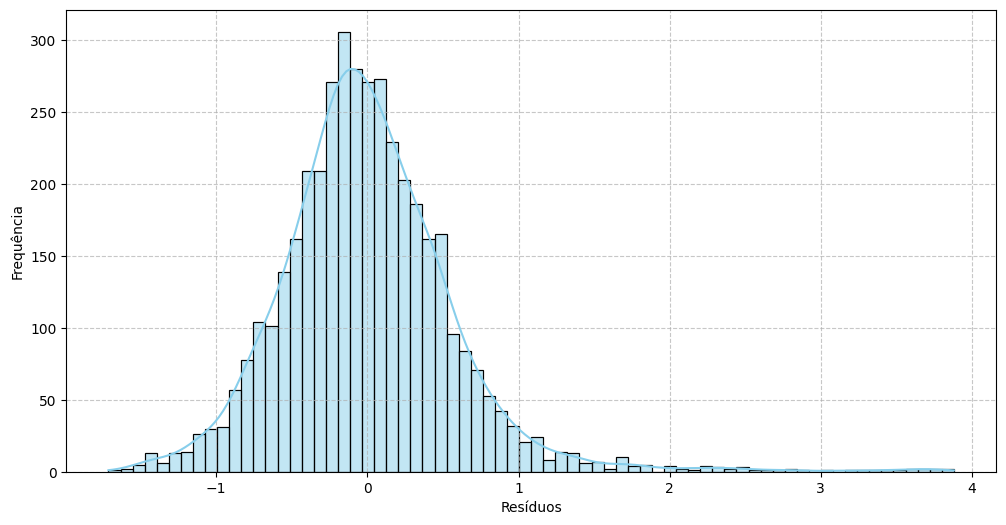

<Figure size 1200x600 with 0 Axes>

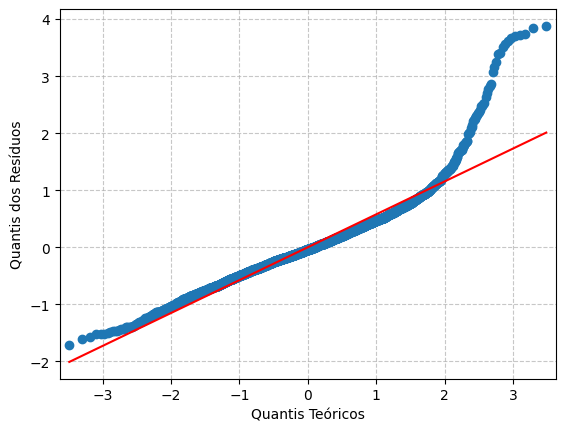


--- Análise de Independência dos Resíduos ---


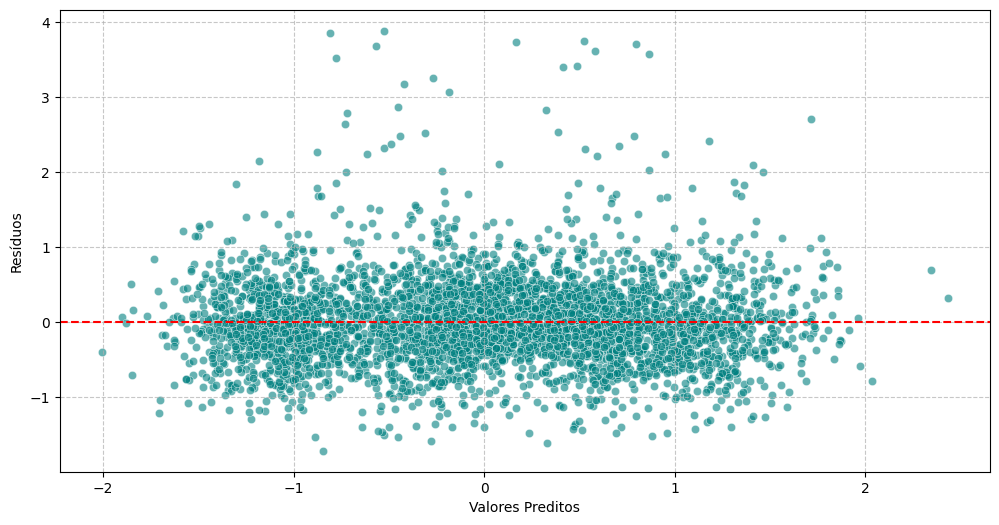


Observação: O valor da estatística Durbin-Watson para independência dos resíduos já está presente no summary do modelo OLS.
Durbin-Watson do modelo OLS 5 (calculado diretamente): 1.3560


In [139]:
import matplotlib.pyplot as plt
import seaborn as sns
import statsmodels.api as sm
import numpy as np
from statsmodels.stats.stattools import durbin_watson

# Resíduos do modelo
residuals = modelo_ols5.resid

# Valores preditos pelo modelo
fitted_values = modelo_ols5.fittedvalues

# --- Teste de Normalidade dos Resíduos ---
print("\n--- Análise de Normalidade dos Resíduos ---")

# Histograma dos resíduos com curva KDE
plt.figure(figsize=(12, 6))
sns.histplot(residuals, kde=True, color='skyblue')
plt.title('')
plt.xlabel('Resíduos')
plt.ylabel('Frequência')
plt.grid(True, linestyle='--', alpha=0.7)
plt.show()

# Q-Q Plot dos resíduos
plt.figure(figsize=(12, 6))
sm.qqplot(residuals, line='s') # line='s' adiciona uma linha de 45 graus para referência
plt.title('')
plt.xlabel('Quantis Teóricos')
plt.ylabel('Quantis dos Resíduos')
plt.grid(True, linestyle='--', alpha=0.7)
plt.show()

# --- Teste de Independência dos Resíduos (Visual) ---
print("\n--- Análise de Independência dos Resíduos ---")

# Gráfico de Resíduos vs. Valores Preditos
plt.figure(figsize=(12, 6))
sns.scatterplot(x=fitted_values, y=residuals, alpha=0.6, color='teal')
plt.axhline(y=0, color='red', linestyle='--') # Linha de referência no zero
plt.title('')
plt.xlabel('Valores Preditos')
plt.ylabel('Resíduos')
plt.grid(True, linestyle='--', alpha=0.7)
plt.show()

print("\nObservação: O valor da estatística Durbin-Watson para independência dos resíduos já está presente no summary do modelo OLS.")
print(f"Durbin-Watson do modelo OLS 5 (calculado diretamente): {durbin_watson(residuals):.4f}")

Evolução dos modelos de regressão

In [140]:
import pandas as pd
import statsmodels.formula.api as smf

def extract_model_summary(model_result, model_name):
    """Extracts key summary statistics from a statsmodels OLSResults object."""
    summary_dict = {
        'Modelo': model_name,
        'R-squared': model_result.rsquared,
        'Adj. R-squared': model_result.rsquared_adj,
        'F-statistic': model_result.fvalue,
        'Prob (F-statistic)': model_result.f_pvalue,
        'AIC': model_result.aic,
        'BIC': model_result.bic,
    }
    return summary_dict


# Re-instantiate models if they are not in global scope (for robustness)
# Model 1
df1_ols_saeb = base_final_padronizada[['nota_saeb_matematica', 'comp_dig_geral']].dropna()
formula1 = 'nota_saeb_matematica ~ comp_dig_geral'
modelo_ols1 = smf.ols(formula=formula1, data=df1_ols_saeb).fit()

# Model 2
df2_ols_saeb = base_final_padronizada[['nota_saeb_matematica', 'comp_dig_geral', 'MEDIA_INSE']].dropna()
formula2 = 'nota_saeb_matematica ~ comp_dig_geral + MEDIA_INSE'
modelo_ols2 = smf.ols(formula=formula2, data=df2_ols_saeb).fit()

# Model 3
sigla_uf_cols = [col for col in base_final_padronizada_dummies.columns if col.startswith('sigla_uf_')]
formula3 = 'nota_saeb_matematica ~ comp_dig_geral + MEDIA_INSE + ' + ' + '.join(sigla_uf_cols)
modelo_ols3 = smf.ols(formula=formula3, data=base_final_padronizada_dummies).fit()

# Model 4
formula4 = 'nota_saeb_matematica ~ comp_dig_geral + MEDIA_INSE + taxa_matricula_branca_educacao_basica + ' + ' + '.join(sigla_uf_cols)
modelo_ols4 = smf.ols(formula=formula4, data=base_final_padronizada_dummies).fit()

# Model 5 (Standard OLS) - Re-using the logic from cell 5NPlxPyYwuab
sigla_uf_cols_m5 = [col for col in base_final_padronizada_dummies.columns if col.startswith('sigla_uf_')]
rede_cols_m5 = [col for col in base_final_padronizada_dummies.columns if col.startswith('rede_')]
anos_escolares_cols_m5 = [col for col in base_final_padronizada_dummies.columns if col.startswith('anos_escolares_')]
all_categorical_dummies_m5 = sigla_uf_cols_m5 + rede_cols_m5 + anos_escolares_cols_m5
formula5_for_modelo_ols5 = 'nota_saeb_matematica ~ comp_dig_geral + MEDIA_INSE + taxa_matricula_branca_educacao_basica + ' + ' + '.join(all_categorical_dummies_m5)
modelo_ols5 = smf.ols(formula=formula5_for_modelo_ols5, data=base_final_padronizada_dummies).fit()

# Model 6 (Standard OLS) - Re-using the logic from cell IidB357cztHh
sigla_uf_cols_m6 = [col for col in base_final_padronizada_dummies.columns if col.startswith('sigla_uf_')]
rede_cols_m6 = [col for col in base_final_padronizada_dummies.columns if col.startswith('rede_')]
anos_escolares_cols_m6 = [col for col in base_final_padronizada_dummies.columns if col.startswith('anos_escolares_')]
infras_cols_m6 = ['laboratorio_informatica', 'quadra_esportes', 'biblioteca_sala_leitura']
all_categorical_dummies_m6 = sigla_uf_cols_m6 + rede_cols_m6 + anos_escolares_cols_m6 + infras_cols_m6
formula6_for_modelo_ols6 = 'nota_saeb_matematica ~ comp_dig_geral + MEDIA_INSE + taxa_matricula_branca_educacao_basica + ' + ' + '.join(all_categorical_dummies_m6)
modelo_ols6 = smf.ols(formula=formula6_for_modelo_ols6, data=base_final_padronizada_dummies).fit()

# Model 6 Adjusted with HC3 (This is the modelo_ols6_HC3 from T0VOOtklBBDf)
# The object 'modelo_ols6_HC3' should be available from previous cell execution


# Collect summaries
all_model_summaries = [
    extract_model_summary(modelo_ols1, 'Modelo 1'),
    extract_model_summary(modelo_ols2, 'Modelo 2'),
    extract_model_summary(modelo_ols3, 'Modelo 3'),
    extract_model_summary(modelo_ols4, 'Modelo 4'),
    extract_model_summary(modelo_ols5, 'Modelo 5'),
    extract_model_summary(modelo_ols6, 'Modelo 6'),
    extract_model_summary(modelo_ols6_HC3, 'Modelo 6 (OLS-HC3)') # Renamed for clarity
]

df_summary_table = pd.DataFrame(all_model_summaries)

print("\nTabela de Evolução dos Modelos de Regressão (OLS e OLS-HC3):")
display(df_summary_table.round(4))



Tabela de Evolução dos Modelos de Regressão (OLS e OLS-HC3):


,Modelo,R-squared,Adj. R-squared,F-statistic,Prob (F-statistic),AIC,BIC
0,Modelo 1,0.0986,0.0983,445.5653,0.0,11150.9695,11163.5958
1,Modelo 2,0.1139,0.1135,261.8548,0.0,11082.9812,11101.9206
2,Modelo 3,0.3086,0.3052,90.5137,0.0,10107.5208,10240.0963
3,Modelo 4,0.3179,0.3143,89.9832,0.0,10054.4067,10193.2953
4,Modelo 5,0.6674,0.6654,338.7246,0.0,7132.4759,7290.3038
5,Modelo 6,0.6677,0.6655,301.3644,0.0,7133.9674,7310.7346
6,Modelo 6 (OLS-HC3),0.6677,0.6655,334.6961,0.0,7133.9674,7310.7346


Evolução dos coeficientes

In [141]:
import pandas as pd

def extract_coefficients_and_pvalues(model_result, model_name):
    """Extracts coefficients and p-values from a statsmodels OLSResults object."""
    coef_df = model_result.summary2().tables[1] # Acessa a tabela de coeficientes e p-valores

    # Check for the correct p-value column name
    p_value_col = None
    if 'P>|z|' in coef_df.columns:
        p_value_col = 'P>|z|'
    elif 'P>|t|' in coef_df.columns:
        p_value_col = 'P>|t|'
    else:
        # If neither is found, raise an error or handle it appropriately
        raise KeyError(f"Neither 'P>|z|' nor 'P>|t|' found in model summary coefficients table for {model_name}.")

    coef_df = coef_df[['Coef.', p_value_col]] # Seleciona apenas as colunas de interesse
    coef_df.columns = [f'Coef_{model_name}', f'P_value_{model_name}']
    return coef_df

# Initialize a list to hold the coefficient dataframes
all_coefs = []

# Collect coefficients and p-values for each model
all_coefs.append(extract_coefficients_and_pvalues(modelo_ols1, 'Modelo 1'))
all_coefs.append(extract_coefficients_and_pvalues(modelo_ols2, 'Modelo 2'))
all_coefs.append(extract_coefficients_and_pvalues(modelo_ols3, 'Modelo 3'))
all_coefs.append(extract_coefficients_and_pvalues(modelo_ols4, 'Modelo 4'))
all_coefs.append(extract_coefficients_and_pvalues(modelo_ols5, 'Modelo 5'))
all_coefs.append(extract_coefficients_and_pvalues(modelo_ols6, 'Modelo 6'))
all_coefs.append(extract_coefficients_and_pvalues(modelo_ols6_HC3, 'Modelo 6 (OLS-HC3)'))

# Merge all dataframes on their index (variable names)
final_coef_table = pd.concat(all_coefs, axis=1, sort=True)

print("\nTabela de Coeficientes e P-valores dos Modelos:")
display(final_coef_table.round(4))


Tabela de Coeficientes e P-valores dos Modelos:


,Coef_Modelo 1,P_value_Modelo 1,Coef_Modelo 2,P_value_Modelo 2,Coef_Modelo 3,P_value_Modelo 3,Coef_Modelo 4,P_value_Modelo 4,Coef_Modelo 5,P_value_Modelo 5,Coef_Modelo 6,P_value_Modelo 6,Coef_Modelo 6 (OLS-HC3),P_value_Modelo 6 (OLS-HC3)
Intercept,-0.0000,1.0,-0.0000,1.0,-0.2723,0.5139,-0.1767,0.6700,-1.0302,0.0004,-1.0502,0.0003,-1.0502,0.0215
MEDIA_INSE,NaN,NaN,0.1239,0.0,0.3570,0.0000,0.3187,0.0000,0.3979,0.0000,0.3961,0.0000,0.3961,0.0000
anos_escolares_EFII,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,1.0528,0.0000,1.0492,0.0000,1.0492,0.0000
anos_escolares_EM,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,1.6756,0.0000,1.6682,0.0000,1.6682,0.0000
biblioteca_sala_leitura[T.True],NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,-0.0072,0.7967,-0.0072,0.7971
comp_dig_geral,0.3139,0.0,0.3095,0.0,0.2192,0.0000,0.2189,0.0000,0.0386,0.0006,0.0376,0.0009,0.0376,0.0057
laboratorio_informatica[T.True],NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.0172,0.3831,0.0172,0.3785
quadra_esportes[T.True],NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.0402,0.0741,0.0402,0.0930
rede_municipal,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.0329,0.3028,0.0381,0.2393,0.0381,0.2487
sigla_uf_BA,NaN,NaN,NaN,NaN,0.2612,0.5362,0.2368,0.5724,0.1968,0.5018,0.1863,0.5252,0.1863,0.6828


In [142]:
import pandas as pd

# Assuming all model objects (modelo_ols1, modelo_ols2, etc.) are available in the current kernel state.

log_likelihoods = {
    'Modelo 1': modelo_ols1.llf,
    'Modelo 2': modelo_ols2.llf,
    'Modelo 3': modelo_ols3.llf,
    'Modelo 4': modelo_ols4.llf,
    'Modelo 5': modelo_ols5.llf,
    'Modelo 6': modelo_ols6.llf,
    'Modelo 6 (OLS-HC3)': modelo_ols6_HC3.llf
}

df_log_likelihood = pd.DataFrame(log_likelihoods.items(), columns=['Modelo', 'Log-Likelihood'])

print("\nLog-Likelihood de cada Modelo:")
display(df_log_likelihood.round(4))


Log-Likelihood de cada Modelo:


,Modelo,Log-Likelihood
0,Modelo 1,-5573.4848
1,Modelo 2,-5538.4906
2,Modelo 3,-5032.7604
3,Modelo 4,-5005.2034
4,Modelo 5,-3541.2379
5,Modelo 6,-3538.9837
6,Modelo 6 (OLS-HC3),-3538.9837


# Calcular ICC
calcular ICC do modelo